# 중량과 품질 등급(4C)으로 다이아몬드 가격을 설명할 수 있는가

## #1. 분석 개요

**분석 주제**

> 공개 데이터인 Kaggle diamonds 데이터셋으로 **다이아몬드의 중량(`carat`)과 품질 등급(`cut`·`color`·`clarity`)이 가격을 얼마나 설명하는지** 확인한다.
> 선형회귀의 전 과정(품질 점검 → EDA → 모델링 → 진단 → 해석)을 수행하며, 결과는 인과가 아닌 **연관 관계**로 해석한다.

**분석 질문**

- **Q1.** 다이아몬드 가격을 가장 크게 좌우하는 요인은 무엇인가?
- **Q2.** 중량(`carat`)과 품질 등급(`cut`·`color`·`clarity`) 중 무엇이 가격을 더 잘 설명하는가? 등급 3종 중에서는 무엇의 영향이 가장 큰가?
- **Q3.** 기계적인 변수 선택(VIF·후진소거)과 도메인 지식에 근거한 변수 제거 중 어느 쪽이 더 나은 모형을 만드는가?

**종속변수:** `price` (연속형, 다이아몬드 가격 / 단위 USD) → 예측(회귀) 문제

**초기 가설**

| 가설 | 내용 |
|---|---|
| H1 | 중량(`carat`)이 클수록 가격이 높을 것이다. |
| H2 | 투명도(`clarity`) 등급이 높을수록 가격이 높을 것이다. |
| H3 | 색상(`color`)이 D(최상)에 가까울수록 가격이 높을 것이다. |
| H4 | 컷(`cut`) 등급이 높을수록 가격이 높을 것이다. |

**이번 노트북에서 수행하는 기법**

| 구분 | 내용 |
|---|---|
| 전처리 | 왜도에 근거한 **로그 변환**, IQR 경계값 **이상치 대체**, 서열형(`cut`·`color`·`clarity`) 더미 인코딩 |
| 변수 선택 | **VIF 기반 공선성 제거**, **후진소거법**, 도메인 지식에 근거한 직접 제거(`x`·`y`·`z`) |
| 모형 비교 | 전처리를 하나씩 누적한 **체크포인트 9종** 비교 (기계적 5종 + 도메인 4종), 원본 척도(USD) 기준 RMSE 1순위 |
| 진단 | 선형회귀 **4대 가정 검정**과 위반 시 조치(HC3 로버스트 표준오차) |
| 해석 | **표준화계수(β)** 를 통한 영향력 비교 |

#### 1-1. 분석 환경 설정

> 분석에 필요한 개별 함수 **import**


In [1]:
from jussam import load_data
from helpers import *
from IPython.display import display, Markdown

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: develop


---
## #2. 데이터 소개

#### 2-1. 데이터 로딩

In [2]:
origin = load_data('diamonds')
origin.head()

📚 다이아몬드를 커팅, 색상, 투명도, 가격 및 기타 속성 조사한 데이터 셋 (출처: https://www.kaggle.com/datasets/shivam2503/diamonds)

    field    description
--  -------  -------------------------------------------------------------------
 0  price    다이아몬드 가격 (USD, $326 ~ $18,823)
 1  carat    중량 (0.2~5.01)
 2  cut      컷 품질 (Fair, Good, Very Good, Premium, Ideal)
 3  color    색상 등급 - J (worst) to D (best)
 4  clarity  투명도 등급 (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
 5  x        길이 mm (0~10.74)
 6  y        너비 mm (0--58.9)
 7  z        두께 mm (0--31.8)
 8  depth    비율 정보 = z / mean(x, y) = 2 * z / (x + y) (43--79)
 9  table    다이아몬드의 가장 넓은 지점에 비해 상단(테이블)의 너비 (43--95)



,price,carat,cut,color,clarity,x,y,z,depth,table
0,326,0.230,Ideal,E,SI2,3.950,3.980,2.430,61.500,55.000
1,326,0.210,Premium,E,SI1,3.890,3.840,2.310,59.800,61.000
2,327,0.230,Good,E,VS1,4.050,4.070,2.310,56.900,65.000
3,334,0.290,Premium,I,VS2,4.200,4.230,2.630,62.400,58.000
4,335,0.310,Good,J,SI2,4.340,4.350,2.750,63.300,58.000


#### 2-2. 출처와 분석 단위

- **출처:** Kaggle diamonds 데이터셋 (약 54,000개 관측치)
- **시간적 범위:** 횡단면 데이터 (시계열 데이터가 아닌 특정 시점의 가격 구조 분석)
- **분석 단위:** 1행 = ( 다이아몬드 1개 / 거래 당시 관측 가능한 특성을 포함 )

#### 2-3. 변수 정의서

| 변수명 | 의미 | 역할 | 척도 | 단위 |
|---|---|---|---|---|
| `price` | 다이아몬드 가격 | 종속변수 | 연속형 | USD($) |
| `cut` | 컷 품질 | 독립변수 | 서열형 | 등급(Fair ~ Ideal) |
| `color` | 색상 등급 | 독립변수 | 서열형 | 등급(J(최하) ~ D(최상)) |
| `clarity` | 투명도 등급 | 독립변수 | 서열형 | 등급(I1(최하) ~ IF(최상)) |
| `carat` | 중량 | 독립변수 | 연속형 | - |
| `x` | 길이 | 독립변수 | 연속형 | mm |
| `y` | 너비 | 독립변수 | 연속형 | mm |
| `z` | 두께 | 독립변수 | 연속형 | mm |
| `depth` | 비율 정보 (= 2z/(x+y)) | 독립변수 | 연속형 | 비율 |
| `table` | 상단(테이블) 너비 비율 | 독립변수 | 연속형 | 비율 |

---
## #3. 품질 점검 및 기본 전처리

> 이 장에서는 **삭제만** 수행한다. 결측치·이상치의 **대체는 #5**의 전처리 파이프라인에서 한다.
> 전처리 기준이 분석 설계보다 앞서면 판단 근거가 사라지기 때문이다.

#### 3-1. 데이터 구조 점검

##### 1) 자료형 확인

In [37]:
origin.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   price    53940 non-null  int64  
 1   carat    53940 non-null  float64
 2   cut      53940 non-null  str    
 3   color    53940 non-null  str    
 4   clarity  53940 non-null  str    
 5   x        53940 non-null  float64
 6   y        53940 non-null  float64
 7   z        53940 non-null  float64
 8   depth    53940 non-null  float64
 9   table    53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.7 MB


#### 2) 자료형 변환

In [38]:
df1 = my_qtcheck.set_type(origin, as_category=['cut', 'color', 'clarity'])
df1.head()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   price    53940 non-null  int64   
 1   carat    53940 non-null  float64 
 2   cut      53940 non-null  category
 3   color    53940 non-null  category
 4   clarity  53940 non-null  category
 5   x        53940 non-null  float64 
 6   y        53940 non-null  float64 
 7   z        53940 non-null  float64 
 8   depth    53940 non-null  float64 
 9   table    53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


,price,carat,cut,color,clarity,x,y,z,depth,table
0,326,0.230,Ideal,E,SI2,3.950,3.980,2.430,61.500,55.000
1,326,0.210,Premium,E,SI1,3.890,3.840,2.310,59.800,61.000
2,327,0.230,Good,E,VS1,4.050,4.070,2.310,56.900,65.000
3,334,0.290,Premium,I,VS2,4.200,4.230,2.630,62.400,58.000
4,335,0.310,Good,J,SI2,4.340,4.350,2.750,63.300,58.000


#### 3) 중복 검사 및 중복 데이터 삭제

In [39]:
df2 = my_qtcheck.check_duplicates(df1)
df2.head()

중복된 행의 수: 146
중복된 행이 제거되었습니다.


,price,carat,cut,color,clarity,x,y,z,depth,table
0,326,0.230,Ideal,E,SI2,3.950,3.980,2.430,61.500,55.000
1,326,0.210,Premium,E,SI1,3.890,3.840,2.310,59.800,61.000
2,327,0.230,Good,E,VS1,4.050,4.070,2.310,56.900,65.000
3,334,0.290,Premium,I,VS2,4.200,4.230,2.630,62.400,58.000
4,335,0.310,Good,J,SI2,4.340,4.350,2.750,63.300,58.000


#### 3-2. 데이터 품질 점검

##### 1) 결측치 확인

In [40]:
my_qtcheck.check_missing_values(df2)

,Missing Count,Missing Ratio (%)
price,0,0.000
carat,0,0.000
cut,0,0.000
color,0,0.000
clarity,0,0.000
x,0,0.000
y,0,0.000
z,0,0.000
depth,0,0.000
table,0,0.000


> 결측치는 없다.

##### 2) 이상치 확인 (IQR 기준)

`numerical_summary()` 는 기술통계량과 함께 **IQR × 1.5 경계**를 벗어난 이상치의 개수·비율을 계산한다.

In [41]:
num_desc = my_qtcheck.numerical_summary(df2)
num_desc

,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
price,53794.000,3933.065,3988.114,326.000,951.000,2401.000,5326.750,18823.000,0.638,large_diff,4375.750,11890.375,-5612.625,3523,0.065,0,0.000,3523,0.065,1.618,right tail,2.178,leptokurtic,log
carat,53794.000,0.798,0.473,0.200,0.400,0.700,1.040,5.010,0.140,diff,0.640,2.000,-0.560,1873,0.035,0,0.000,1873,0.035,1.114,right tail,1.247,leptokurtic,log
x,53794.000,5.731,1.121,0.000,4.710,5.700,6.540,10.740,0.005,similar,1.830,9.285,1.965,24,0.000,7,0.000,31,0.001,0.380,symmetric,-0.629,platykurtic,none
y,53794.000,5.735,1.141,0.000,4.720,5.710,6.540,58.900,0.004,similar,1.820,9.270,1.990,22,0.000,6,0.000,28,0.001,2.446,right tail,91.752,leptokurtic,log1p
z,53794.000,3.539,0.705,0.000,2.910,3.530,4.030,31.800,0.002,similar,1.120,5.710,1.230,28,0.001,20,0.000,48,0.001,1.529,right tail,47.384,leptokurtic,log1p
depth,53794.000,61.748,1.430,43.000,61.000,61.800,62.500,79.000,0.001,similar,1.500,64.750,58.750,1027,0.019,1498,0.028,2525,0.047,-0.114,symmetric,5.413,leptokurtic,none
table,53794.000,57.458,2.234,43.000,56.000,57.000,59.000,95.000,0.008,similar,3.000,63.500,51.500,588,0.011,16,0.000,604,0.011,0.792,right tail,2.775,leptokurtic,log


#### 3-3. 기술통계량

##### 1) 연속형 변수의 기술 통계량을 전치 형태로 출력

In [42]:
num_desc.T

,price,carat,x,y,z,depth,table
count,53794.000,53794.000,53794.000,53794.000,53794.000,53794.000,53794.000
mean,3933.065,0.798,5.731,5.735,3.539,61.748,57.458
std,3988.114,0.473,1.121,1.141,0.705,1.430,2.234
min,326.000,0.200,0.000,0.000,0.000,43.000,43.000
25%,951.000,0.400,4.710,4.720,2.910,61.000,56.000
50%,2401.000,0.700,5.700,5.710,3.530,61.800,57.000
75%,5326.750,1.040,6.540,6.540,4.030,62.500,59.000
max,18823.000,5.010,10.740,58.900,31.800,79.000,95.000
rel_diff,0.638,0.140,0.005,0.004,0.002,0.001,0.008
rdiff_flag,large_diff,diff,similar,similar,similar,similar,similar


#### 💡 인사이트
- 관측치는 53,794건, 모든 변수의 count가 동일 → 결측치 없는 완결된 데이터
- 분석 대상은 가격(price) 1개 + 다이아몬드 속성 6개 → 회귀(가격 예측) 문제에 적합
- 변수별 단위 · 스케일이 매우 상이 (price 326~18823 vs carat 0.x vs depth 60대) → 스케일링 필요성 점검
- price · carat · y는 평균↑ ·중앙값↓ +왜도>1 + log 권장→ 로그 변환 후 모델링 필수
- x· depth는 평균≈중앙값 + 왜도≈0 → 정규분포에 가까워 안정적 변수
- y의 첨도 91.75는 극단 이상치 존재 신호 → 뒤에서 정밀 점검
- price의 표준편차(3,989)가 평균(3,933)보다 큼 → 변동성 극단적
- x · y · z의 max값(58.9, 31.8)이 비현실적으로 큼 → 이상치 의심, 이후 단계에서 정밀 점검

##### 2) 명목형 변수의 기술 통계량 확인

In [43]:
cat_desc = my_qtcheck.categorical_summary(df2)
cat_desc

컬럼 'cut'의 value_counts( ):


,count
cut,
Fair,1598
Good,4891
Ideal,21488
Premium,13748
Very Good,12069


컬럼 'color'의 value_counts( ):


,count
color,
D,6755
E,9776
F,9520
G,11262
H,8272
I,5407
J,2802


컬럼 'clarity'의 value_counts( ):


,count
clarity,
I1,740
IF,1784
SI1,13032
SI2,9150
VS1,8156
VS2,12229
VVS1,3647
VVS2,5056


,cut,color,clarity
count,53794,53794,53794
unique,5,7,8
top,Ideal,G,SI1
freq,21488,11262,13032


#### 💡 인사이트
#### 범주형 변수 분포 요약

| 구분 | 주요 내용 |
|---|---|
| **01 Cut** | • Ideal 21,488건(40%)·Premium 26%로 상위 등급에 집중 분포<br>• Fair 1,598건(3.0%)으로 최하 희소<br>• → 고품질 시장 편향 구조 |
| **02 Color** | • **G·F·E·H 중간 등급에 응집**<br>• 최상위 D부터 최하 J까지 7단계<br>• 하위 I·J 표본 비중 낮음<br>• → 무색 계열 중심 거래 |
| **03 Clarity** | • SI1·VS2가 전체의 약 47%<br>• I1 740건(1.4%)·IF 1,784건(3.3%)<br>• 8단계 중 양극단 모두 희소<br>• → 중간 투명도 대중 시장형 |
| **04 종합 시사점** | • 3개 변수 모두 count 53,794 → 결측치 없음, 전수 활용 가능<br>• 최빈값 Ideal·G·SI1 점유율 각 40%·21%·24% → 편중 확인 |

---
## #4. 탐색적 데이터 분석 (EDA)

#### 4-1. 분포 확인

##### 1) 타입 변환 (명목형 확정)

명목형 기술통계량 표의 컬럼명이 명목형 변수 목록이다.

In [44]:
df = my_qtcheck.set_type(df2, as_category=cat_desc.columns)

<class 'pandas.DataFrame'>
Index: 53794 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   price    53794 non-null  int64   
 1   carat    53794 non-null  float64 
 2   cut      53794 non-null  category
 3   color    53794 non-null  category
 4   clarity  53794 non-null  category
 5   x        53794 non-null  float64 
 6   y        53794 non-null  float64 
 7   z        53794 non-null  float64 
 8   depth    53794 non-null  float64 
 9   table    53794 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.4 MB


##### 2) 변수 유형 분류

In [45]:
# 종속변수
target = 'price'
# 종속변수 연속형 여부
target_is_continuous = True

# 명목형 변수
nominal_cols = my_qtcheck.get_categorical_column_names(df)
# 연속형 변수
continuous_cols = my_qtcheck.get_number_column_names(df)

if target_is_continuous:
    # 연속형 변수 이름에서 종속변수 항목 제거
    continuous_cols.remove(target)
else:
    # 명목형 변수 이름에서 종속변수 항목 제거
    nominal_cols.remove(target)

print("종속변수       :", target)
print("종속변수 유형   : " + ("연속형" if target_is_continuous else "명목형"))
print("명목형         :", nominal_cols)
print("연속형         :", continuous_cols)

종속변수       : price
종속변수 유형   : 연속형
명목형         : ['cut', 'color', 'clarity']
연속형         : ['carat', 'x', 'y', 'z', 'depth', 'table']


##### 3) 컬럼 의미를 정리한 딕셔너리

In [46]:
#데이터셋에 따라 직접 설정해야 하는 부분

column_means = {
"price": "다이아몬드 가격 (USD)",
"carat": "중량",
"cut": "컷팅 등급",       # Fair, Good, Very Good, Premium, Ideal
"color": "색상 등급",     # J (worst) to D (best)
"clarity": "투명도 등급", # (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1,IF(best))
"x": "길이(mm)",
"y": "너비(mm)",
"z": "두께(mm)",
"depth": "비율 정보",
"table": "테이블 너비"
}

#### 4) 서열척도 적용 (필요에 따라 수행)
- 명목형 범주에 대해서 서열척도를 적용할 변수에 대한 타입변환 -> 도메인 지식 필요
- 서열척도를 적용하지 않더라도 모델링에 영향을 주지는 않음 -> 시각화 출력 순서 유지 등을 위함

In [47]:
# 서열척도를 적용할 변수와 순서를 정의한다. (낮은 등급 → 높은 등급)
# -> 도메인 지식이 필요한 부분이므로 #01(준비작업)에서만 수정한다.
# -> 서열척도 대상이 없는 데이터셋이라면 제외하면 된다
ordinal_map = {
"cut":      ["Fair", "Good", "Very Good", "Premium", "Ideal"],
"color":    ["J", "I", "H", "G", "F", "E", "D"],
"clarity":  ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"],
}

# 정의된 내용에 따라 순서를 재지정한다.
# -> 데이터셋에 없는 컬럼은 건너뛰므로 다른 데이터셋에서도 오류가 나지 않는다.
for col, order in ordinal_map.items():
    if col in df.columns:
        df[col] = df[col].cat.reorder_categories(order, ordered=True)

df.info()

<class 'pandas.DataFrame'>
Index: 53794 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   price    53794 non-null  int64   
 1   carat    53794 non-null  float64 
 2   cut      53794 non-null  category
 3   color    53794 non-null  category
 4   clarity  53794 non-null  category
 5   x        53794 non-null  float64 
 6   y        53794 non-null  float64 
 7   z        53794 non-null  float64 
 8   depth    53794 non-null  float64 
 9   table    53794 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.4 MB


#### 5) EDA 범위 정리

| 종속유형      | 독립유형        | 분석 유형 | 대상 변수                       | 적용 여부 | 비고                   |
|--------------|-----------------|----------|--------------------------------|----------|------------------------|
| 연속형        | 연속형          | 상관분석  | 연속형 독립변수 6종 → price     | ✅ 적용  | 종속·설명 모두 연속형    |
| 연속형        | 명목형(2집단)   | T검정     | —                             | ❌ 미적용 | 2집단 명목형 없음       |
| 연속형        | 명목형(3집단+)  | ANOVA     | cut, color, clarity → price   | ✅ 적용  | 3집단 이상 명목형 3종    |
| 명목형(2집단) | 연속형          | T검정     | —                             | ❌ 미적용 | 종속변수 타입이 연속형   |
| 명목형(2집단) | 명목형(2집단)   | 교차분석   | —                             | ❌ 미적용 | 종속변수 타입이 연속형   |
| 명목형(2집단) | 명목형(3집단+)  | 교차분석   | —                             | ❌ 미적용 | 종속변수 타입이 연속형   |
| 명목형(3집단+)| 연속형          | ANOVA     | —                             | ❌ 미적용 | 종속변수 타입이 연속형   |
| 명목형(3집단+)| 명목형(2집단)   | 교차분석   | —                             | ❌ 미적용 | 종속변수 타입이 연속형   |
| 명목형(3집단+)| 명목형(3집단+)  | 교차분석   | —                             | ❌ 미적용 | 종속변수 타입이 연속형   |

- 종속변수 `price`가 **연속형**이므로 상위 3개 행만 후보가 되고, 그 중 해당 독립유형 변수가 실제로 존재하는 행만 적용된다.
- 연속형 독립변수 6종: `carat`, `x`, `y`, `z`, `depth`, `table`


##### 6) 연속형 종속변수에 대한 단변량 분석

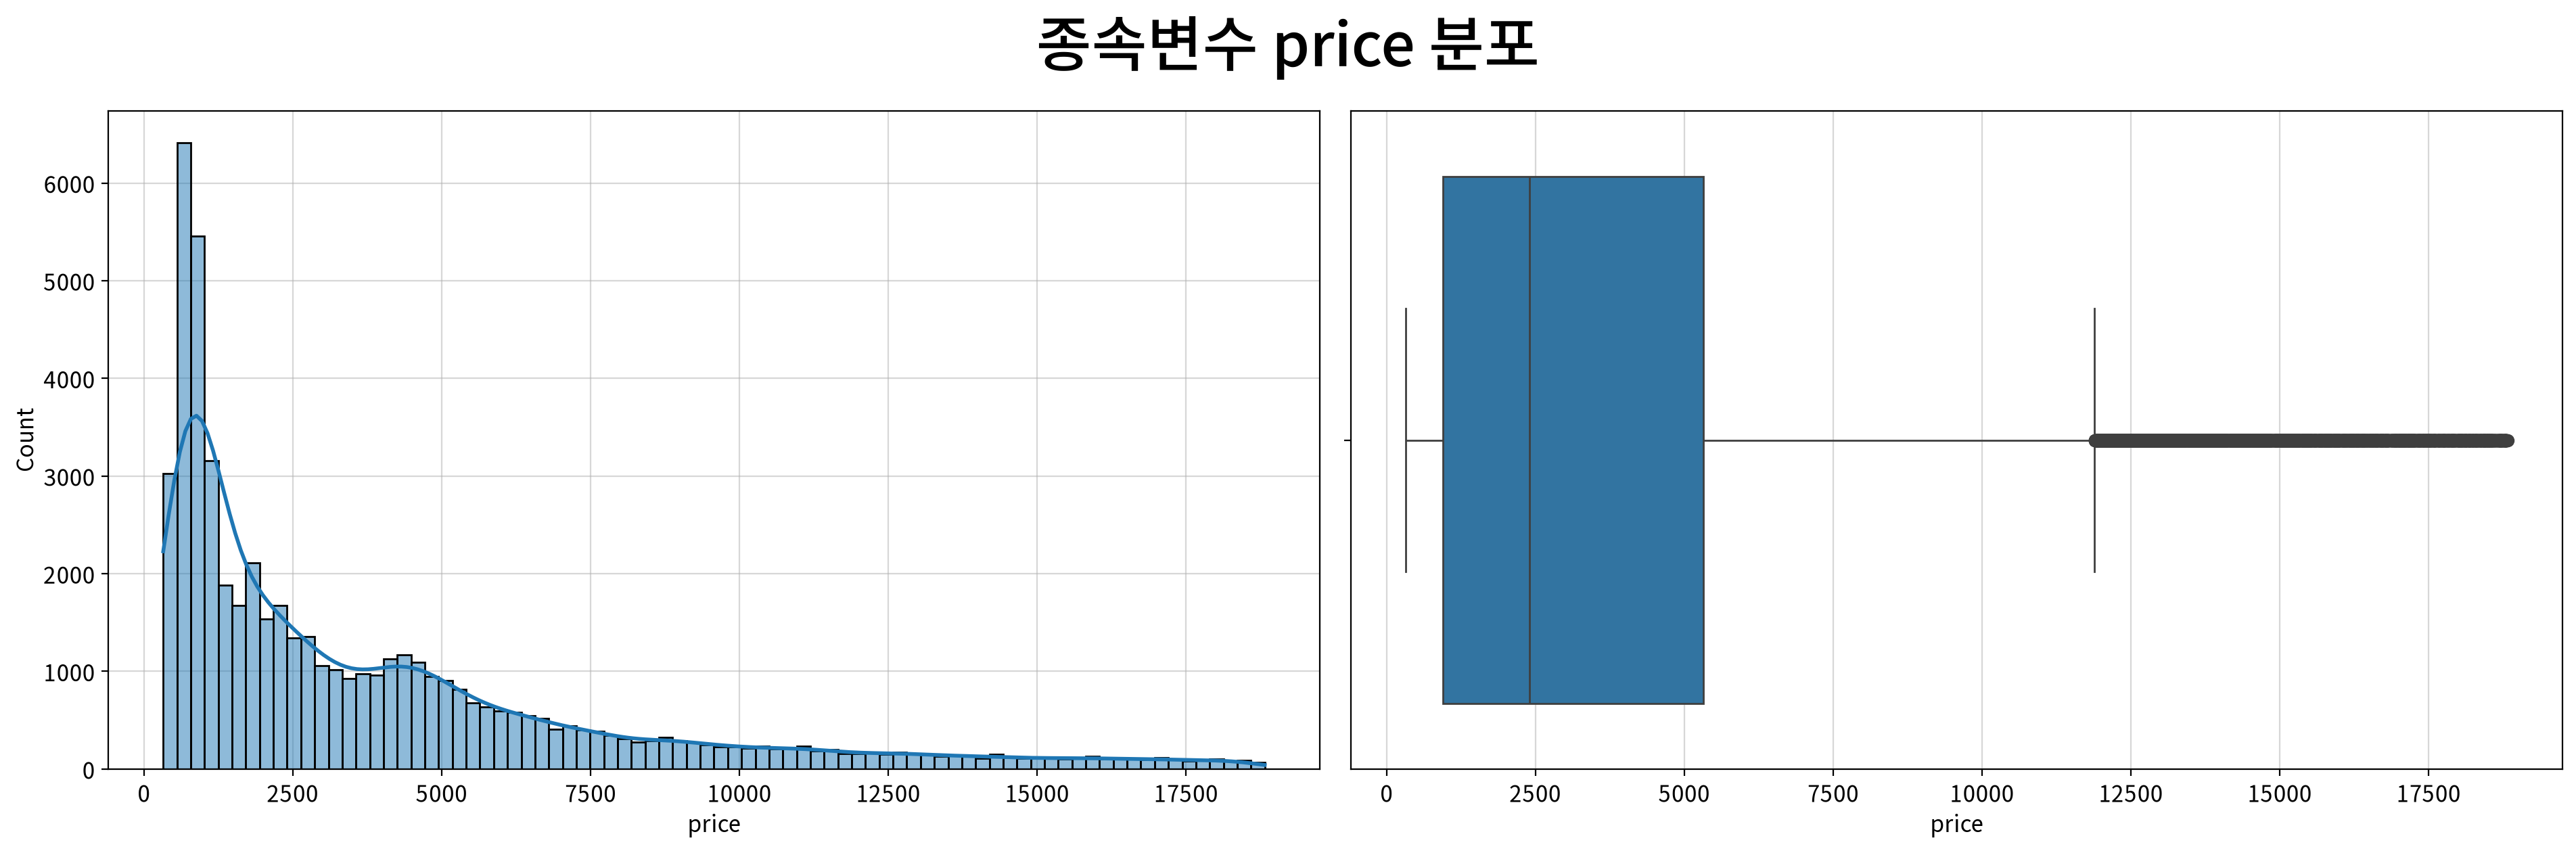

,price
count,53794.000
mean,3933.065
std,3988.114
min,326.000
25%,951.000
50%,2401.000
75%,5326.750
max,18823.000
rel_diff,0.638
rdiff_flag,large_diff


In [48]:
# 1행 2열 서브플롯 구성
# -> 그래프 크기는 서브플롯 중 하나의 크기 (전체 크기는 가로 960 x 2가 됨)
fig, ax = my_plot.init(rows=1, cols=2,
                       title=f"종속변수 {target} 분포", width=960, height=640)
my_plot.histplot(data=df, x=target, kde=True, ax=ax[0])
my_plot.boxplot(data=df, x=target, ax=ax[1])
my_plot.show()

# 연속형 변수 기술통계량에서 종속변수에 대한 부분만 추출
num_desc[num_desc.index == target].T

#### 💡 인사이트

| 점검 항목 | `price` 관찰값 |
|---|---|
| 분포 모양 | 왜도: **+1.618 (우편향)**, 첨도: 2.178 (뾰족함) |
| 봉우리 수 | 단봉 |
| 이상치 | 상단 3,523건(**6.5%**) / 하단 0건 |
| 이산점(군집) | 낮은 가격대 분포가 높음 (일부 고가 다이아몬드 관찰됨, 상단 절단 없음) |

- **로그 변환 후 모델 투입**

##### 7) 연속형 독립변수에 대한 단변량 분석

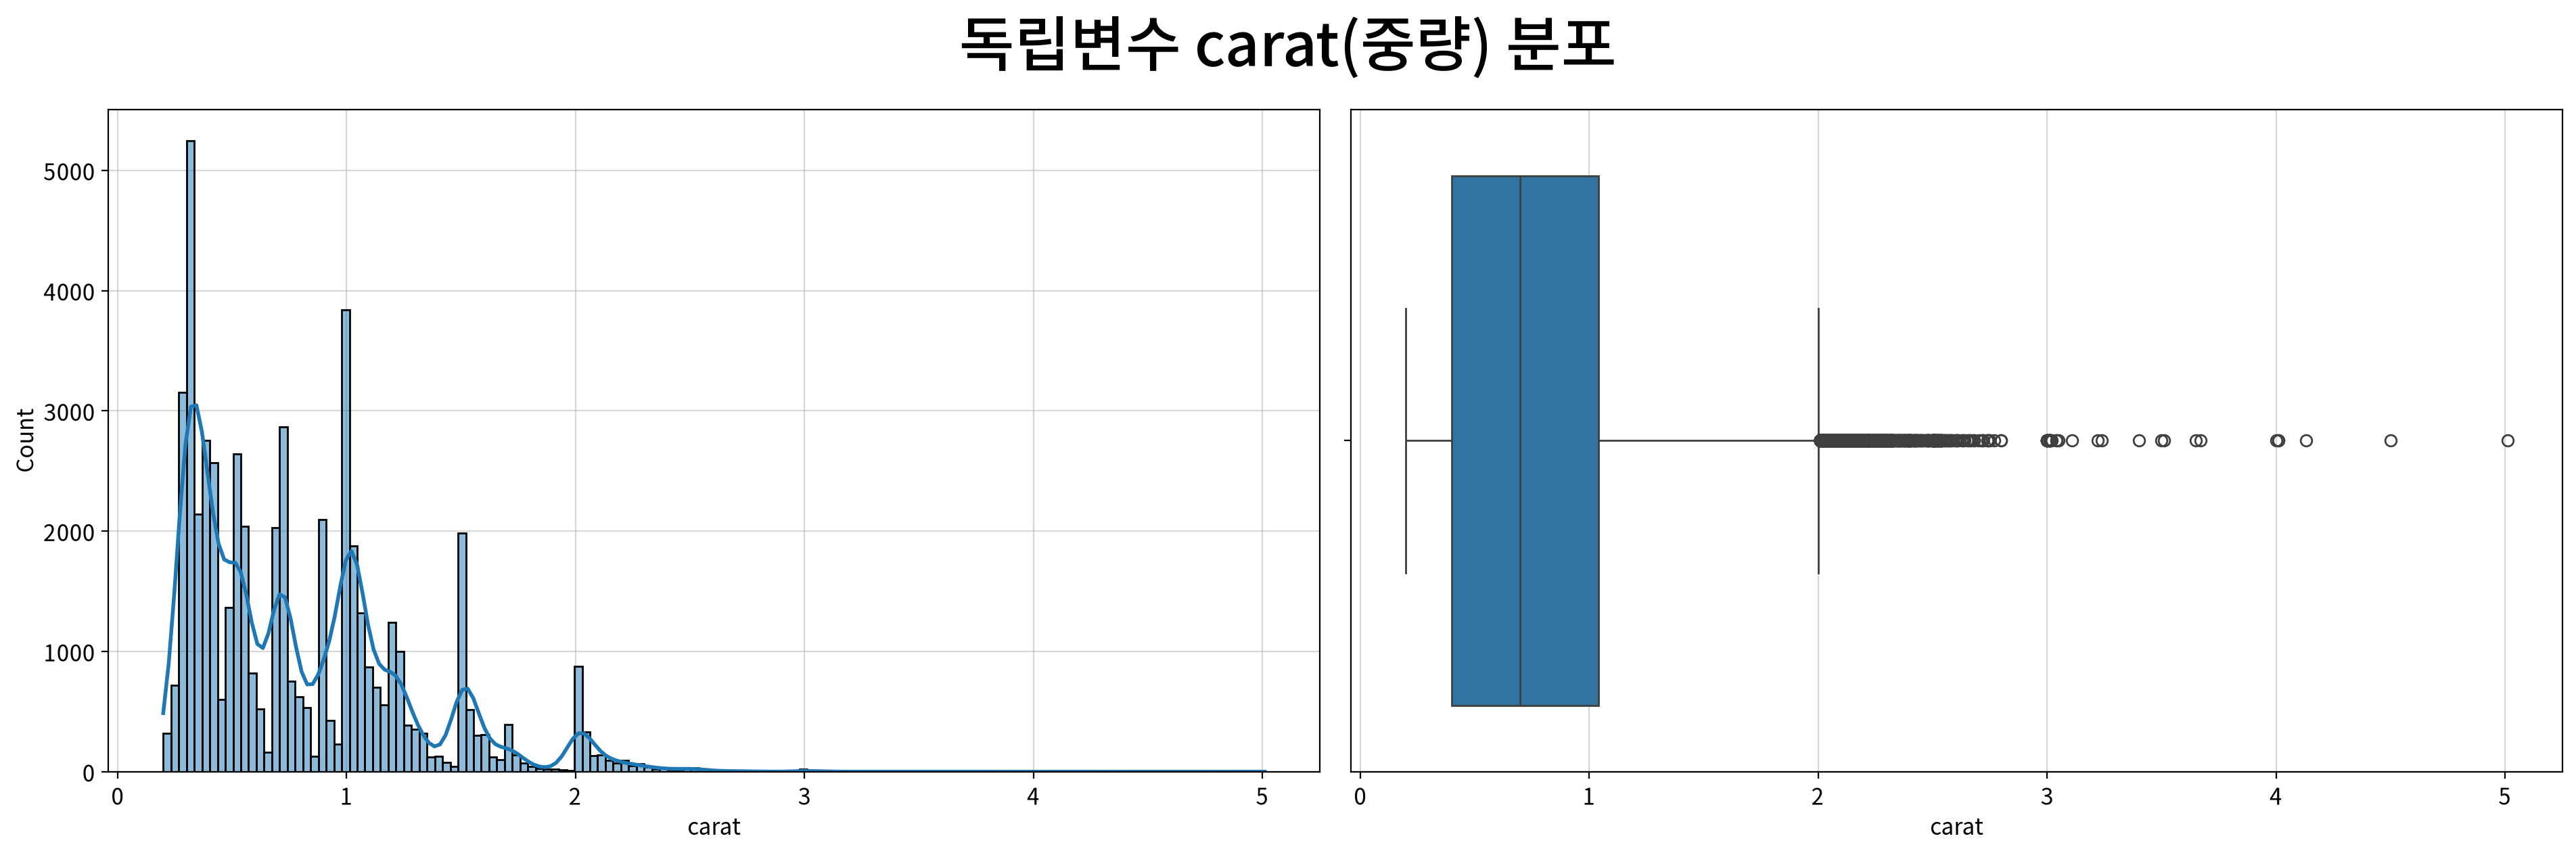

,carat
count,53794.000
mean,0.798
std,0.473
min,0.200
25%,0.400
50%,0.700
75%,1.040
max,5.010
rel_diff,0.140
rdiff_flag,diff


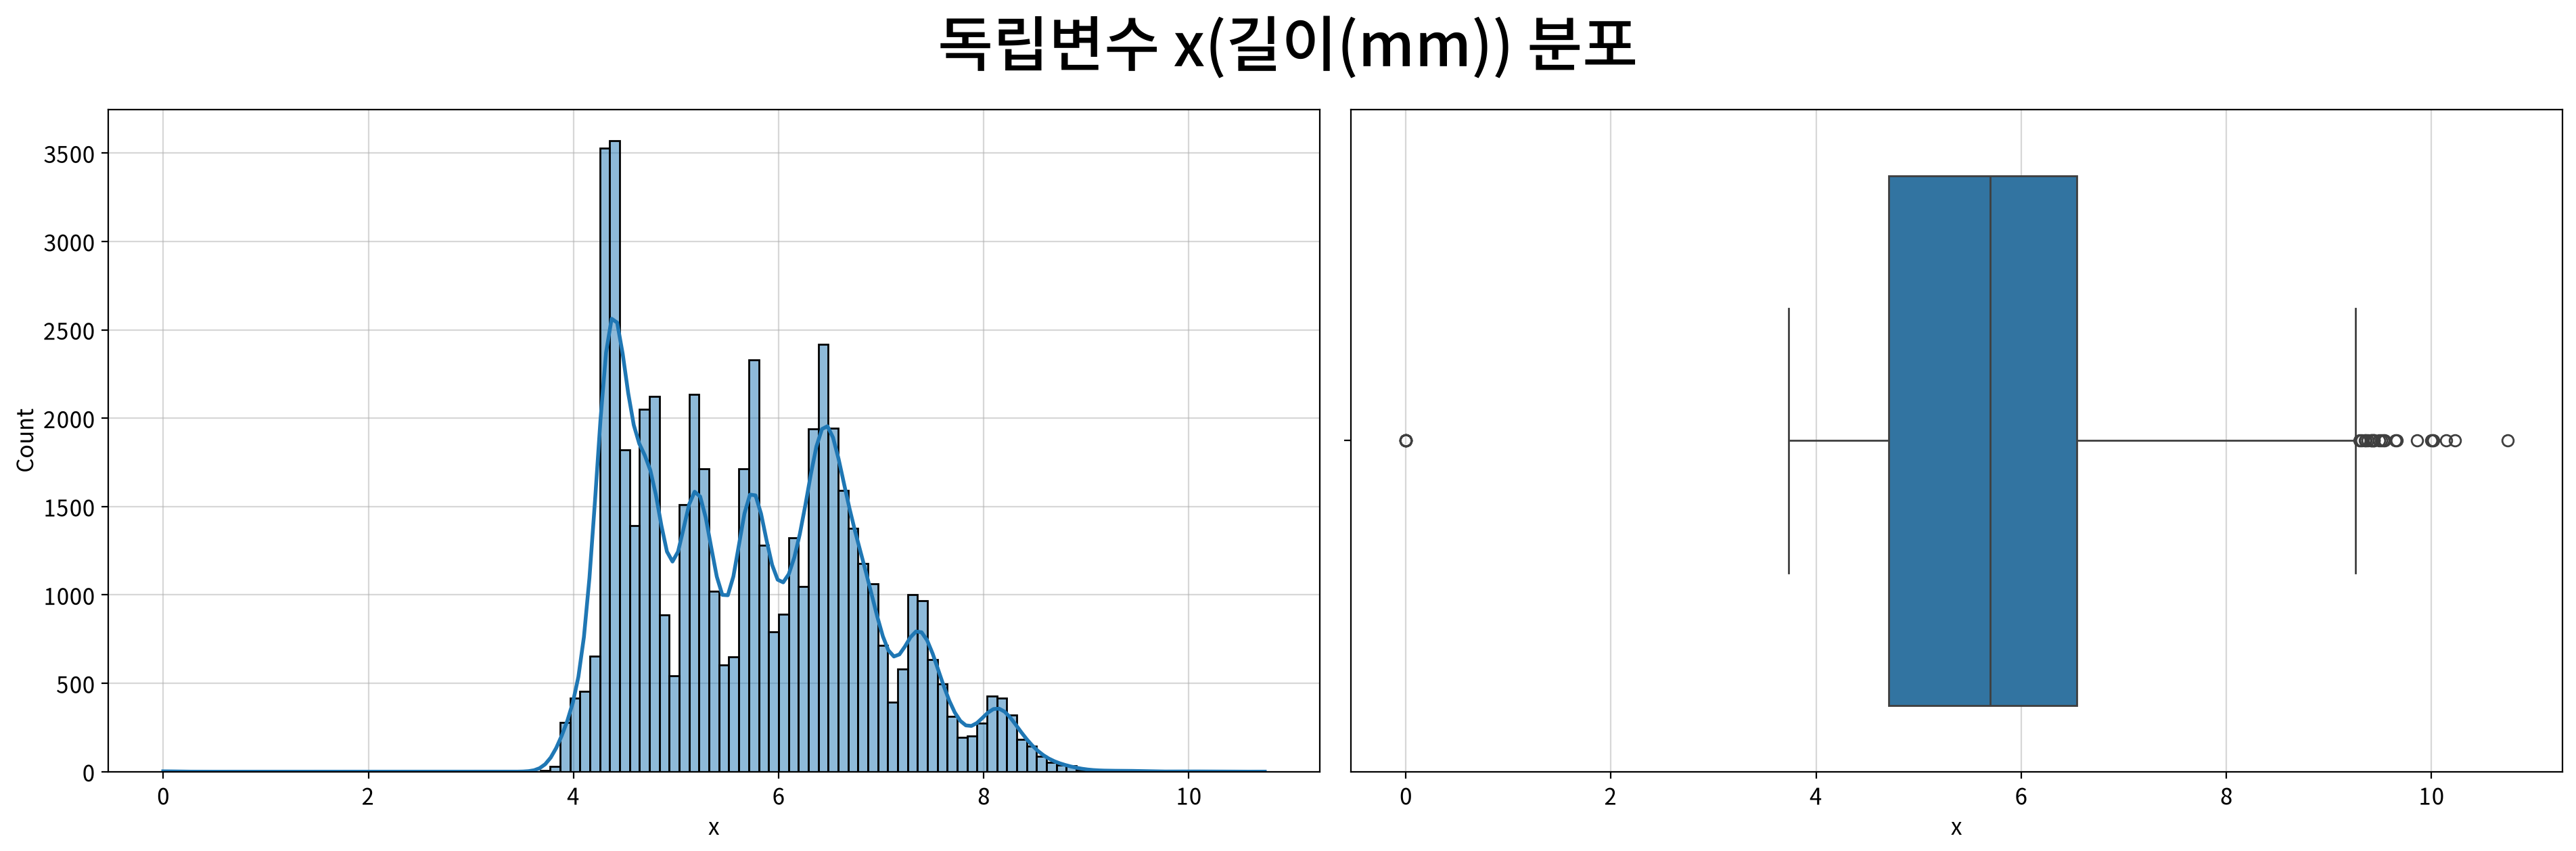

,x
count,53794.000
mean,5.731
std,1.121
min,0.000
25%,4.710
50%,5.700
75%,6.540
max,10.740
rel_diff,0.005
rdiff_flag,similar


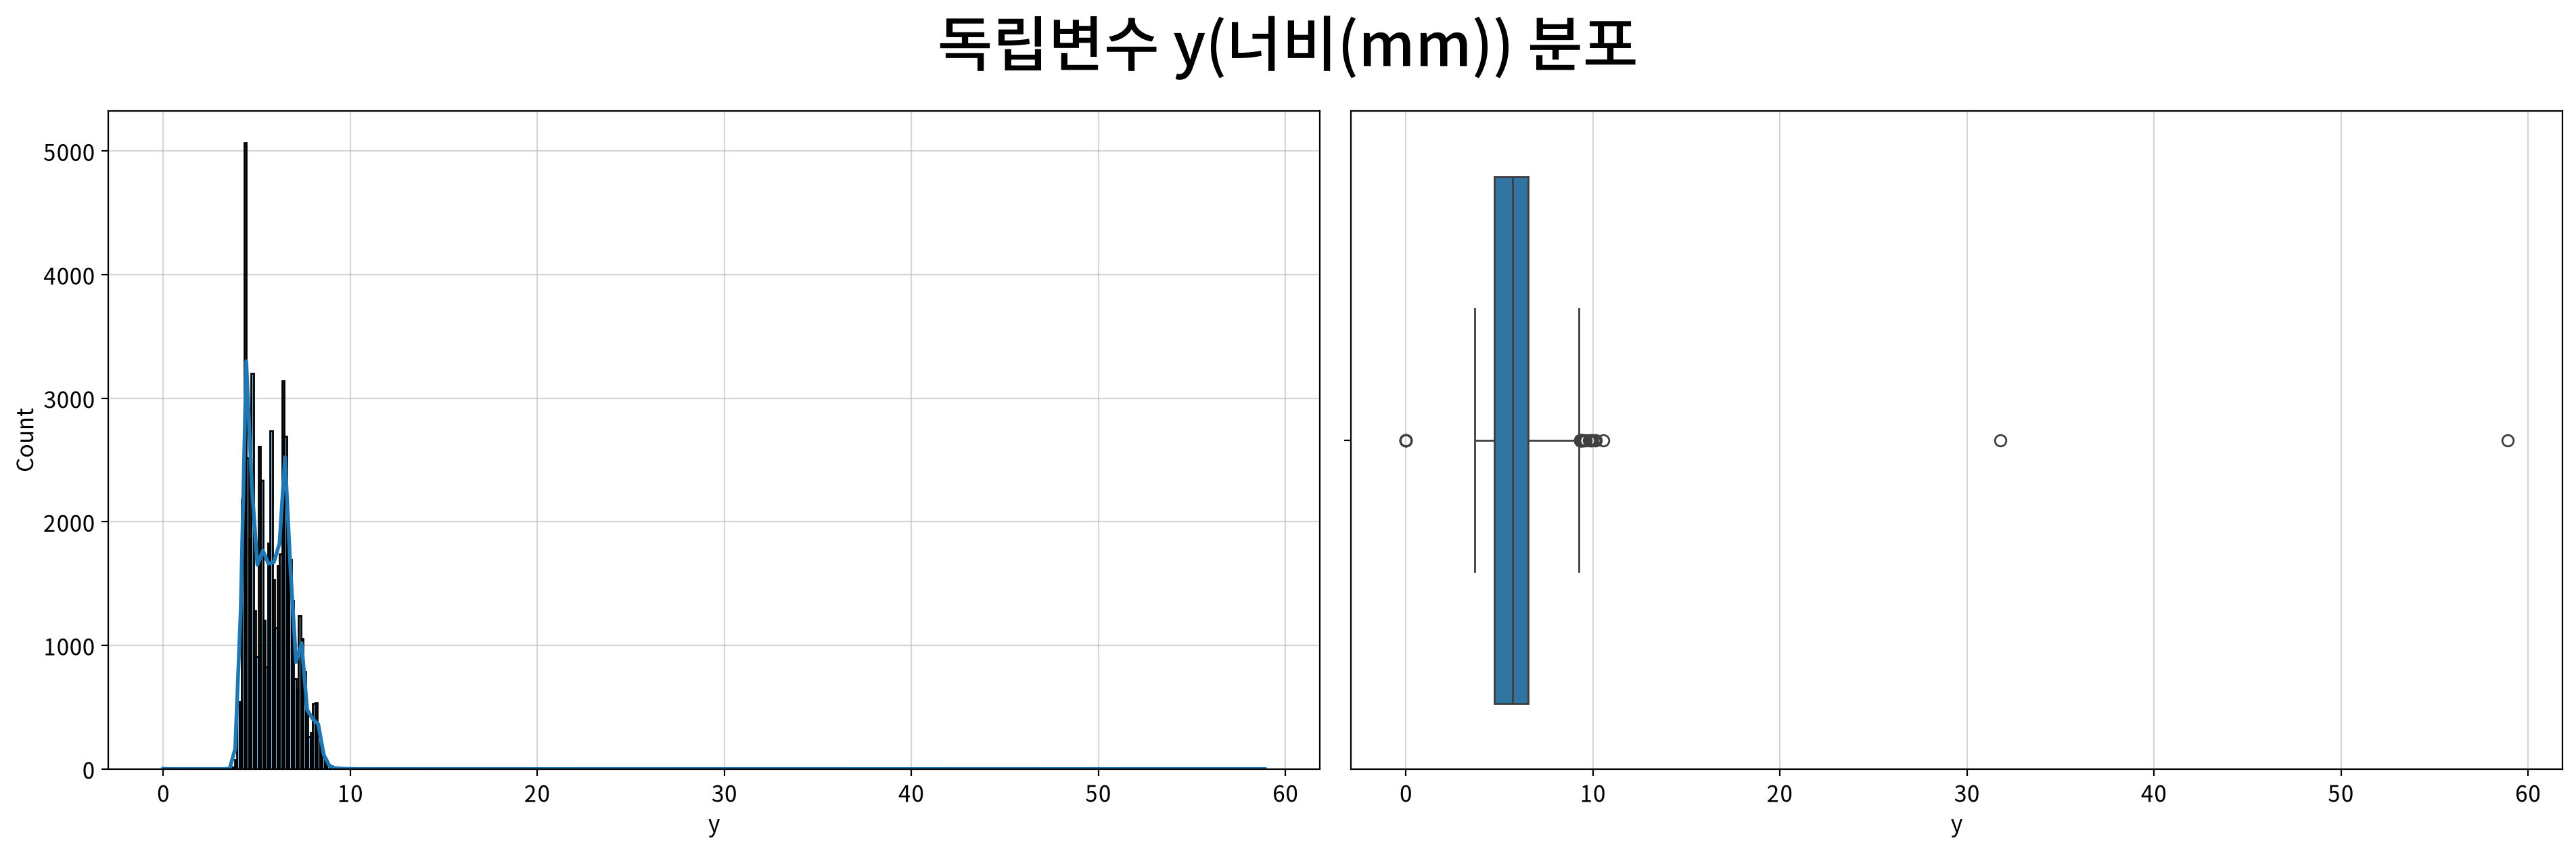

,y
count,53794.000
mean,5.735
std,1.141
min,0.000
25%,4.720
50%,5.710
75%,6.540
max,58.900
rel_diff,0.004
rdiff_flag,similar


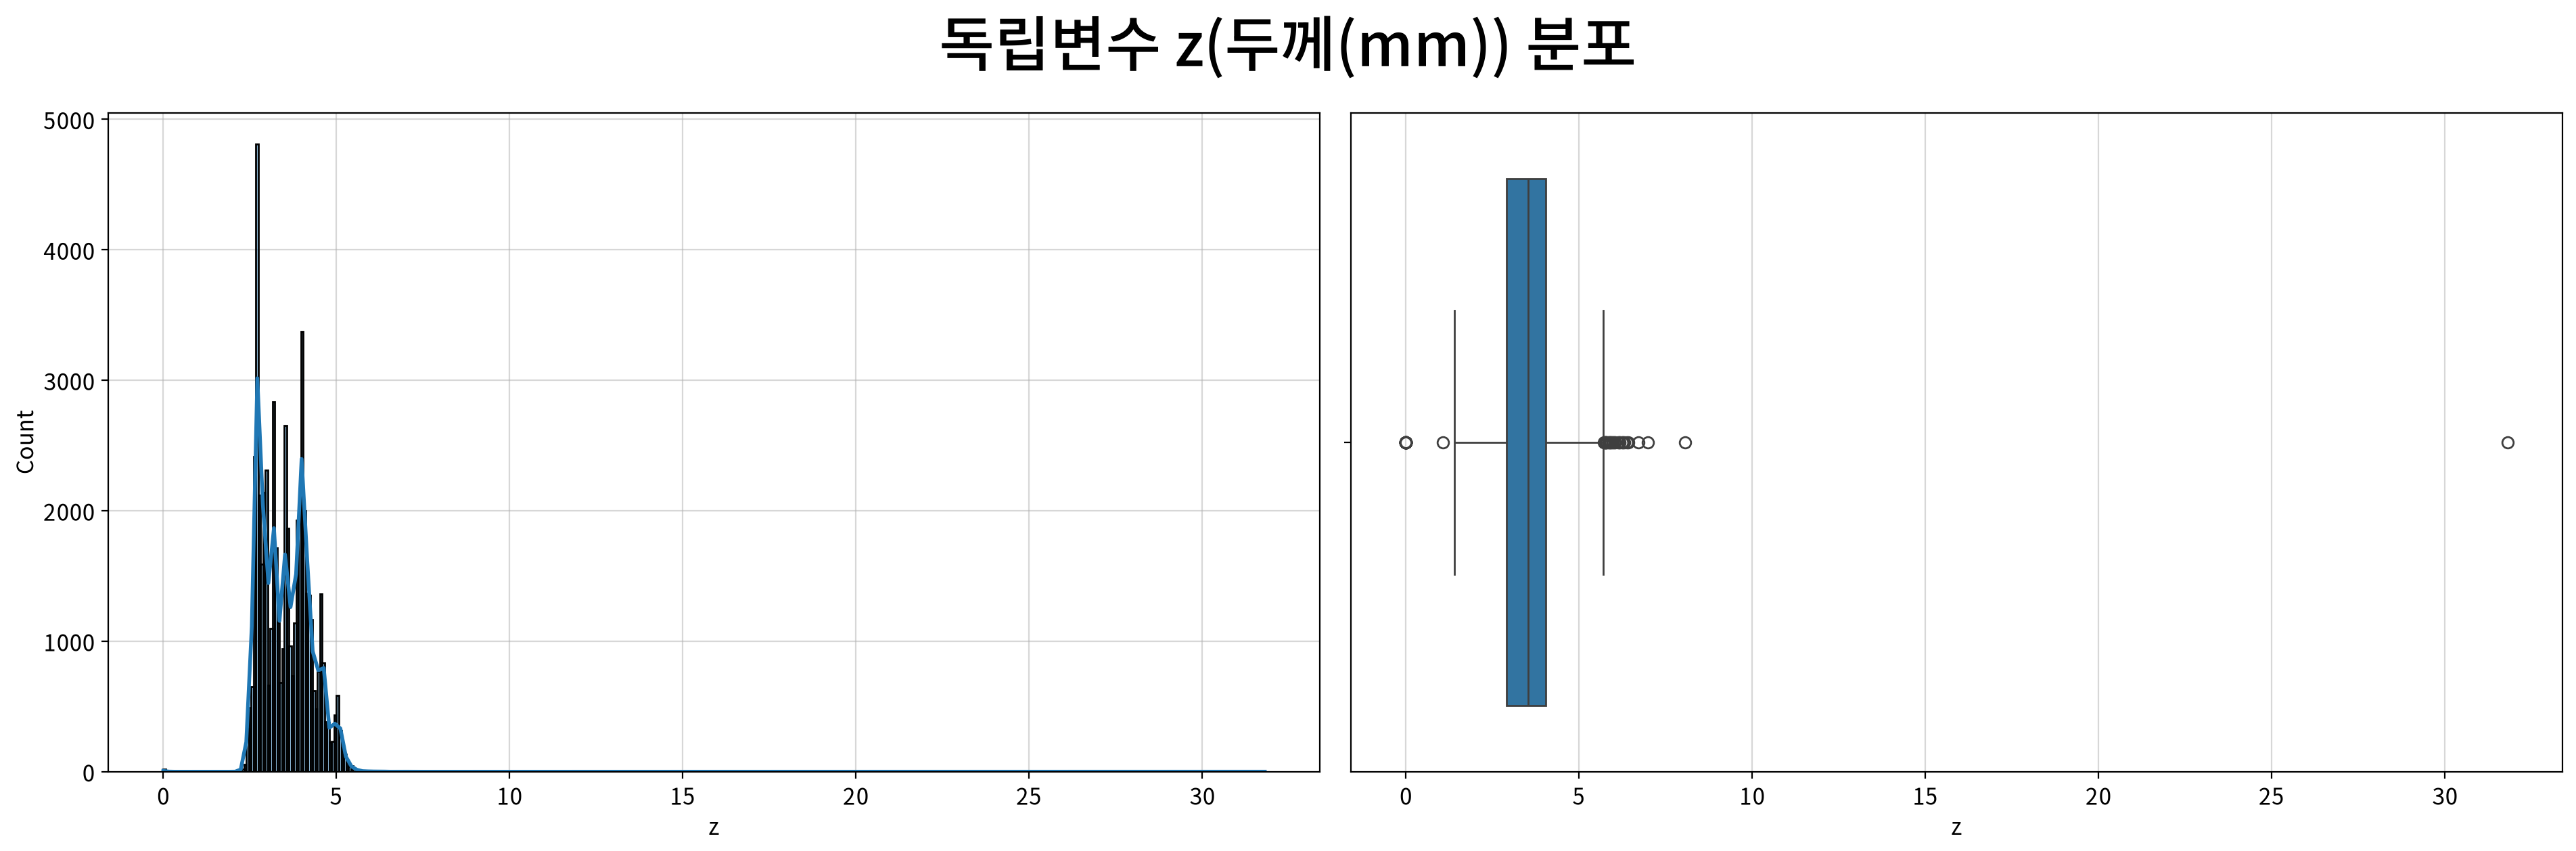

,z
count,53794.000
mean,3.539
std,0.705
min,0.000
25%,2.910
50%,3.530
75%,4.030
max,31.800
rel_diff,0.002
rdiff_flag,similar


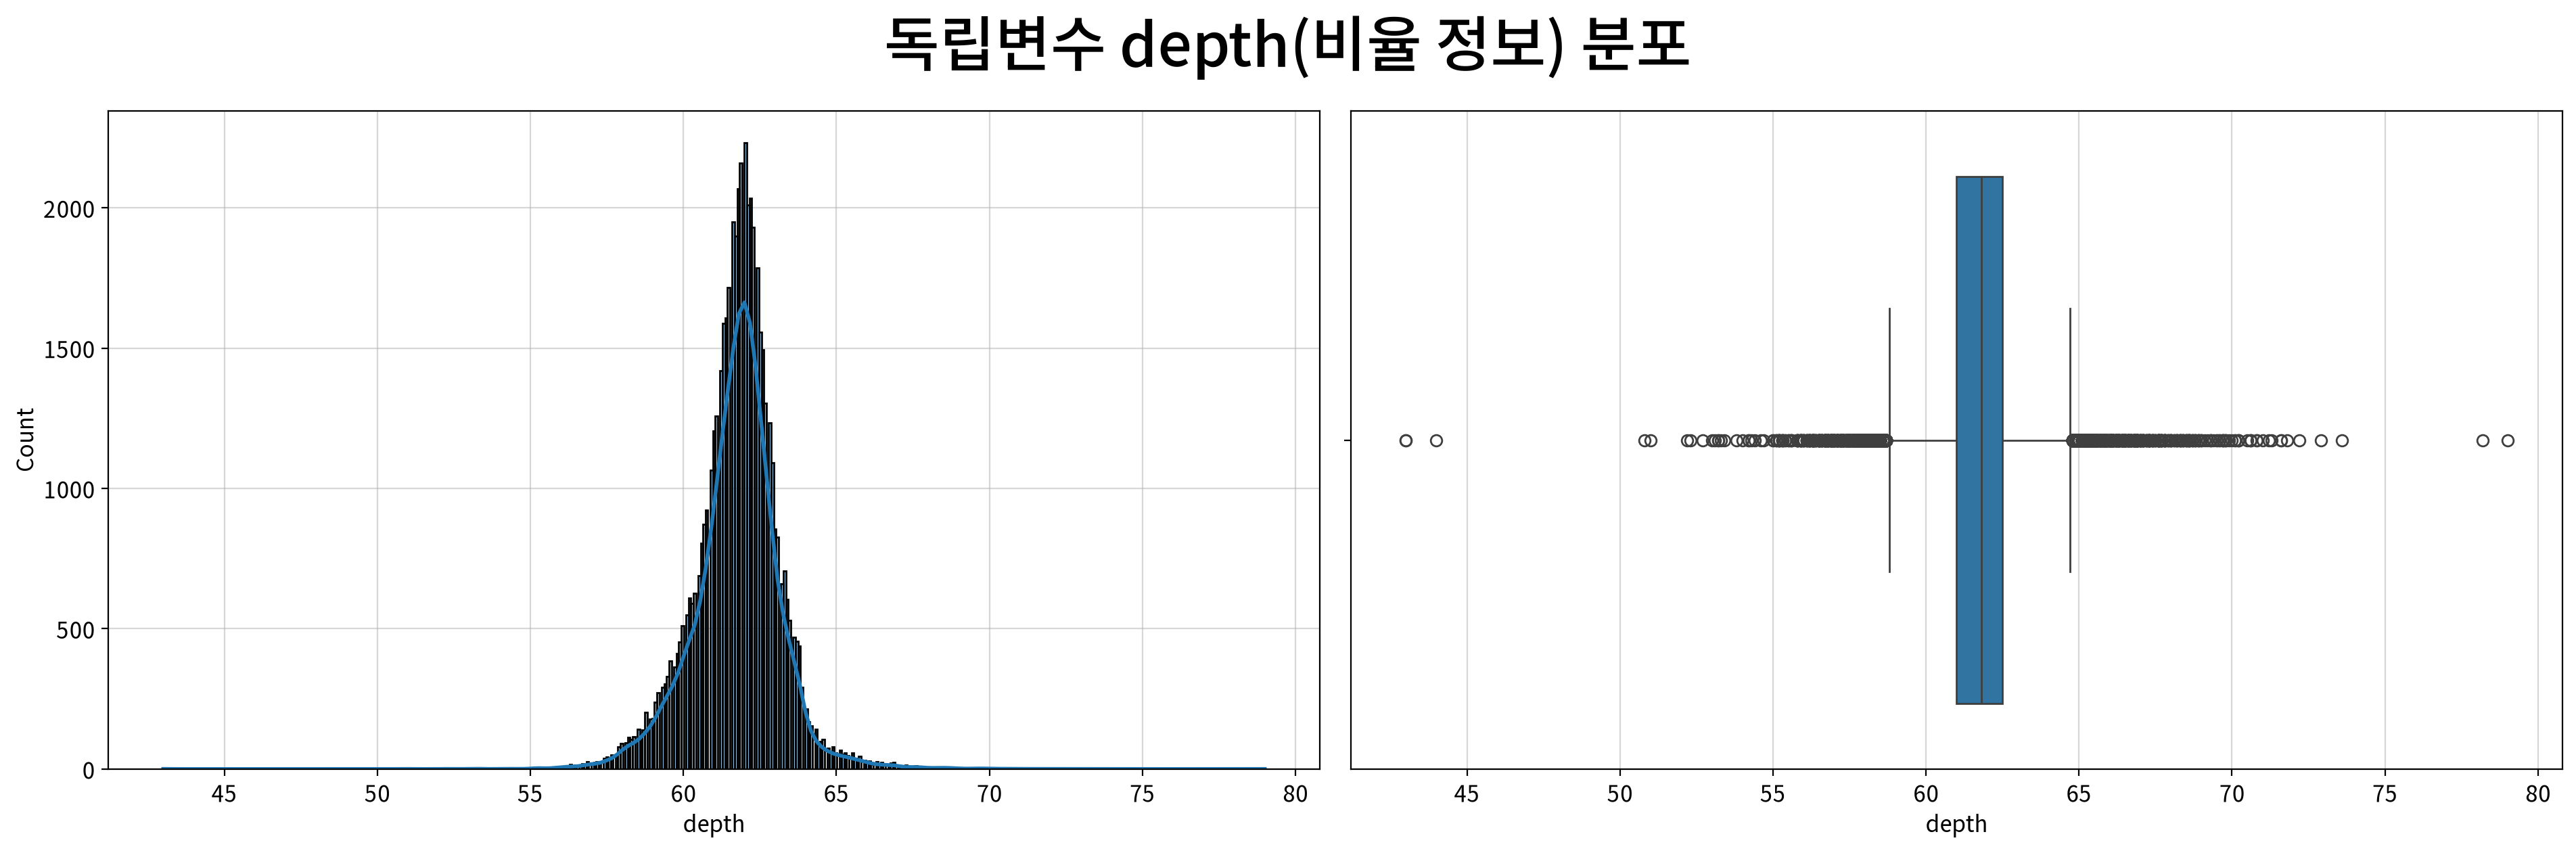

,depth
count,53794.000
mean,61.748
std,1.430
min,43.000
25%,61.000
50%,61.800
75%,62.500
max,79.000
rel_diff,0.001
rdiff_flag,similar


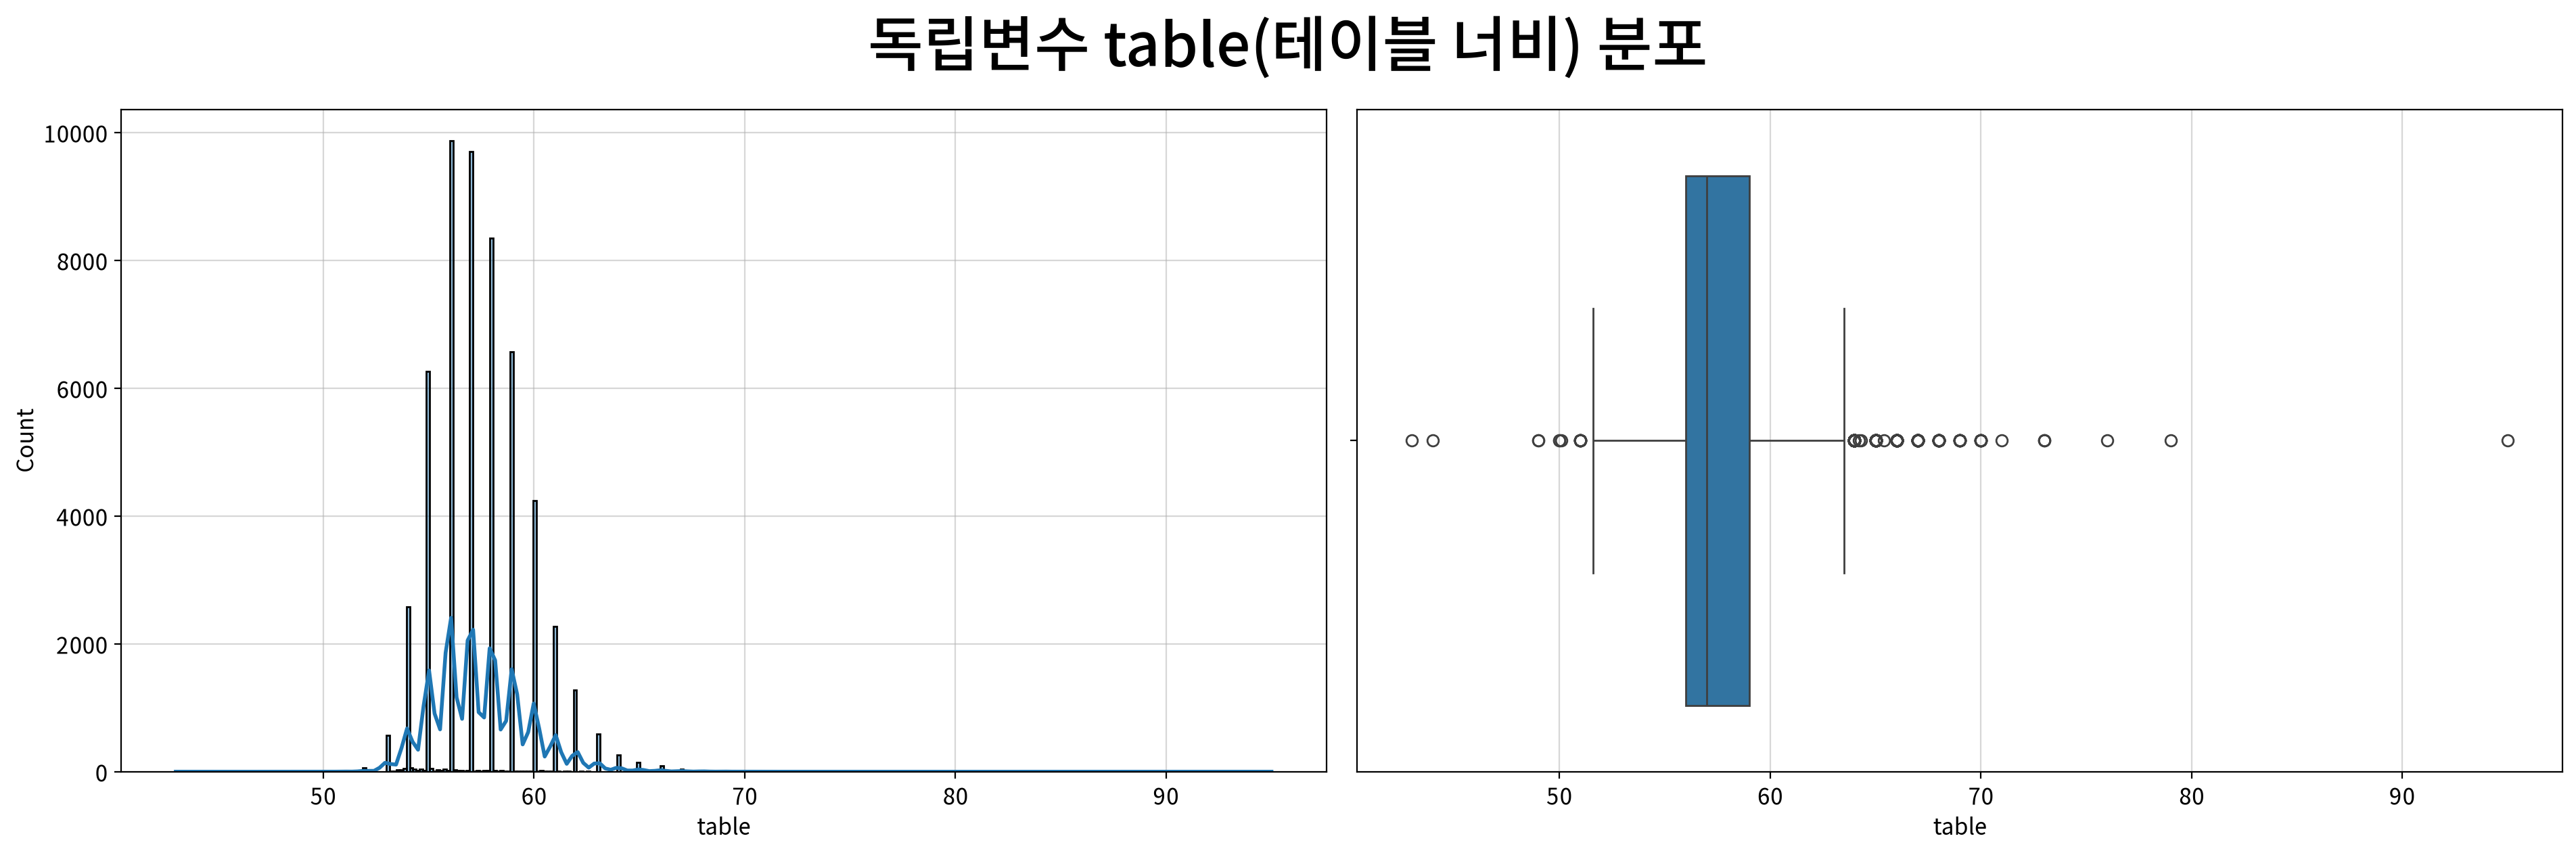

,table
count,53794.000
mean,57.458
std,2.234
min,43.000
25%,56.000
50%,57.000
75%,59.000
max,95.000
rel_diff,0.008
rdiff_flag,similar


In [49]:
for f in continuous_cols:
    fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640,
                title=f"독립변수 {f}({column_means[f]}) 분포")
    my_plot.histplot(data=df, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df, x=f, ax=ax[1])
    my_plot.show()

    display(num_desc[num_desc.index == f].T)

#### 💡 인사이트

| 변수 | 분포 모양(왜도) | 봉우리 수 | 이상치 | 이산점(군집) | 판단·조치 |
|---|---|---|---|---|---|
| `carat` | 강한 우편향 (+1.11) | **다봉** (0.3·0.7·1.0·1.5·2.0ct) | 다소 많음 (3.5%) | 라운드 무게에 집중 | **로그 변환**(log) |
| `x` | 거의 대칭 (+0.38) | 다봉 (`carat` 군집 전이) | 적음 (0.1%) | 0mm 값 7건 | 0값 결측 처리 후 사용 |
| `y` | **매우 강한 우편향** (+2.45) | 다봉 (`carat` 군집 전이) | 적음 (0.1%)* | 0mm 값 6건 | **로그 변환** + 58.9mm·0값 정제 |
| `z` | 강한 우편향 (+1.53) | 다봉 (`carat` 군집 전이) | 적음 (0.1%)* | 0mm 값 19건 | **로그 변환** + 31.8mm·0값 정제 |
| `depth` | 거의 대칭 (-0.11) | **단봉** (61.7 종형) | 많음 (4.7%) | 없음 (연속) | 변환 불필요, 이상치만 점검 |
| `table` | 중간 우편향 (+0.79) | 단봉 (57 중심) | 소수 (1.1%) | **정수값(mm)에 집중** (98%) | 그대로 사용, 이상치 점검 |

- `y`·`z`는 IQR 이상치 건수 자체는 적으나(0.1%) 물리적으로 불가능한 **58.9mm·31.8mm 극단 오류값**을 포함 → 오류값 정제가 핵심.
- **`carat`·`x`·`y`·`z` 다봉**: 0.3·0.5·1.0ct처럼 시장 수요가 몰리는 라운드 무게 스파이크가 물리 치수(`x`·`y`·`z`)로 그대로 전이된 결과.
- **`x`·`y`·`z` 0mm 값**(7·6·19건): 물리적으로 불가능 → **결측 처리 대상**.
- **`table` 이산성**: 98%가 정수(mm)로 기록된 격자형 분포 → 연속형이지만 사실상 이산.


##### 8) 명목형 독립변수에 대한 단변량 분석

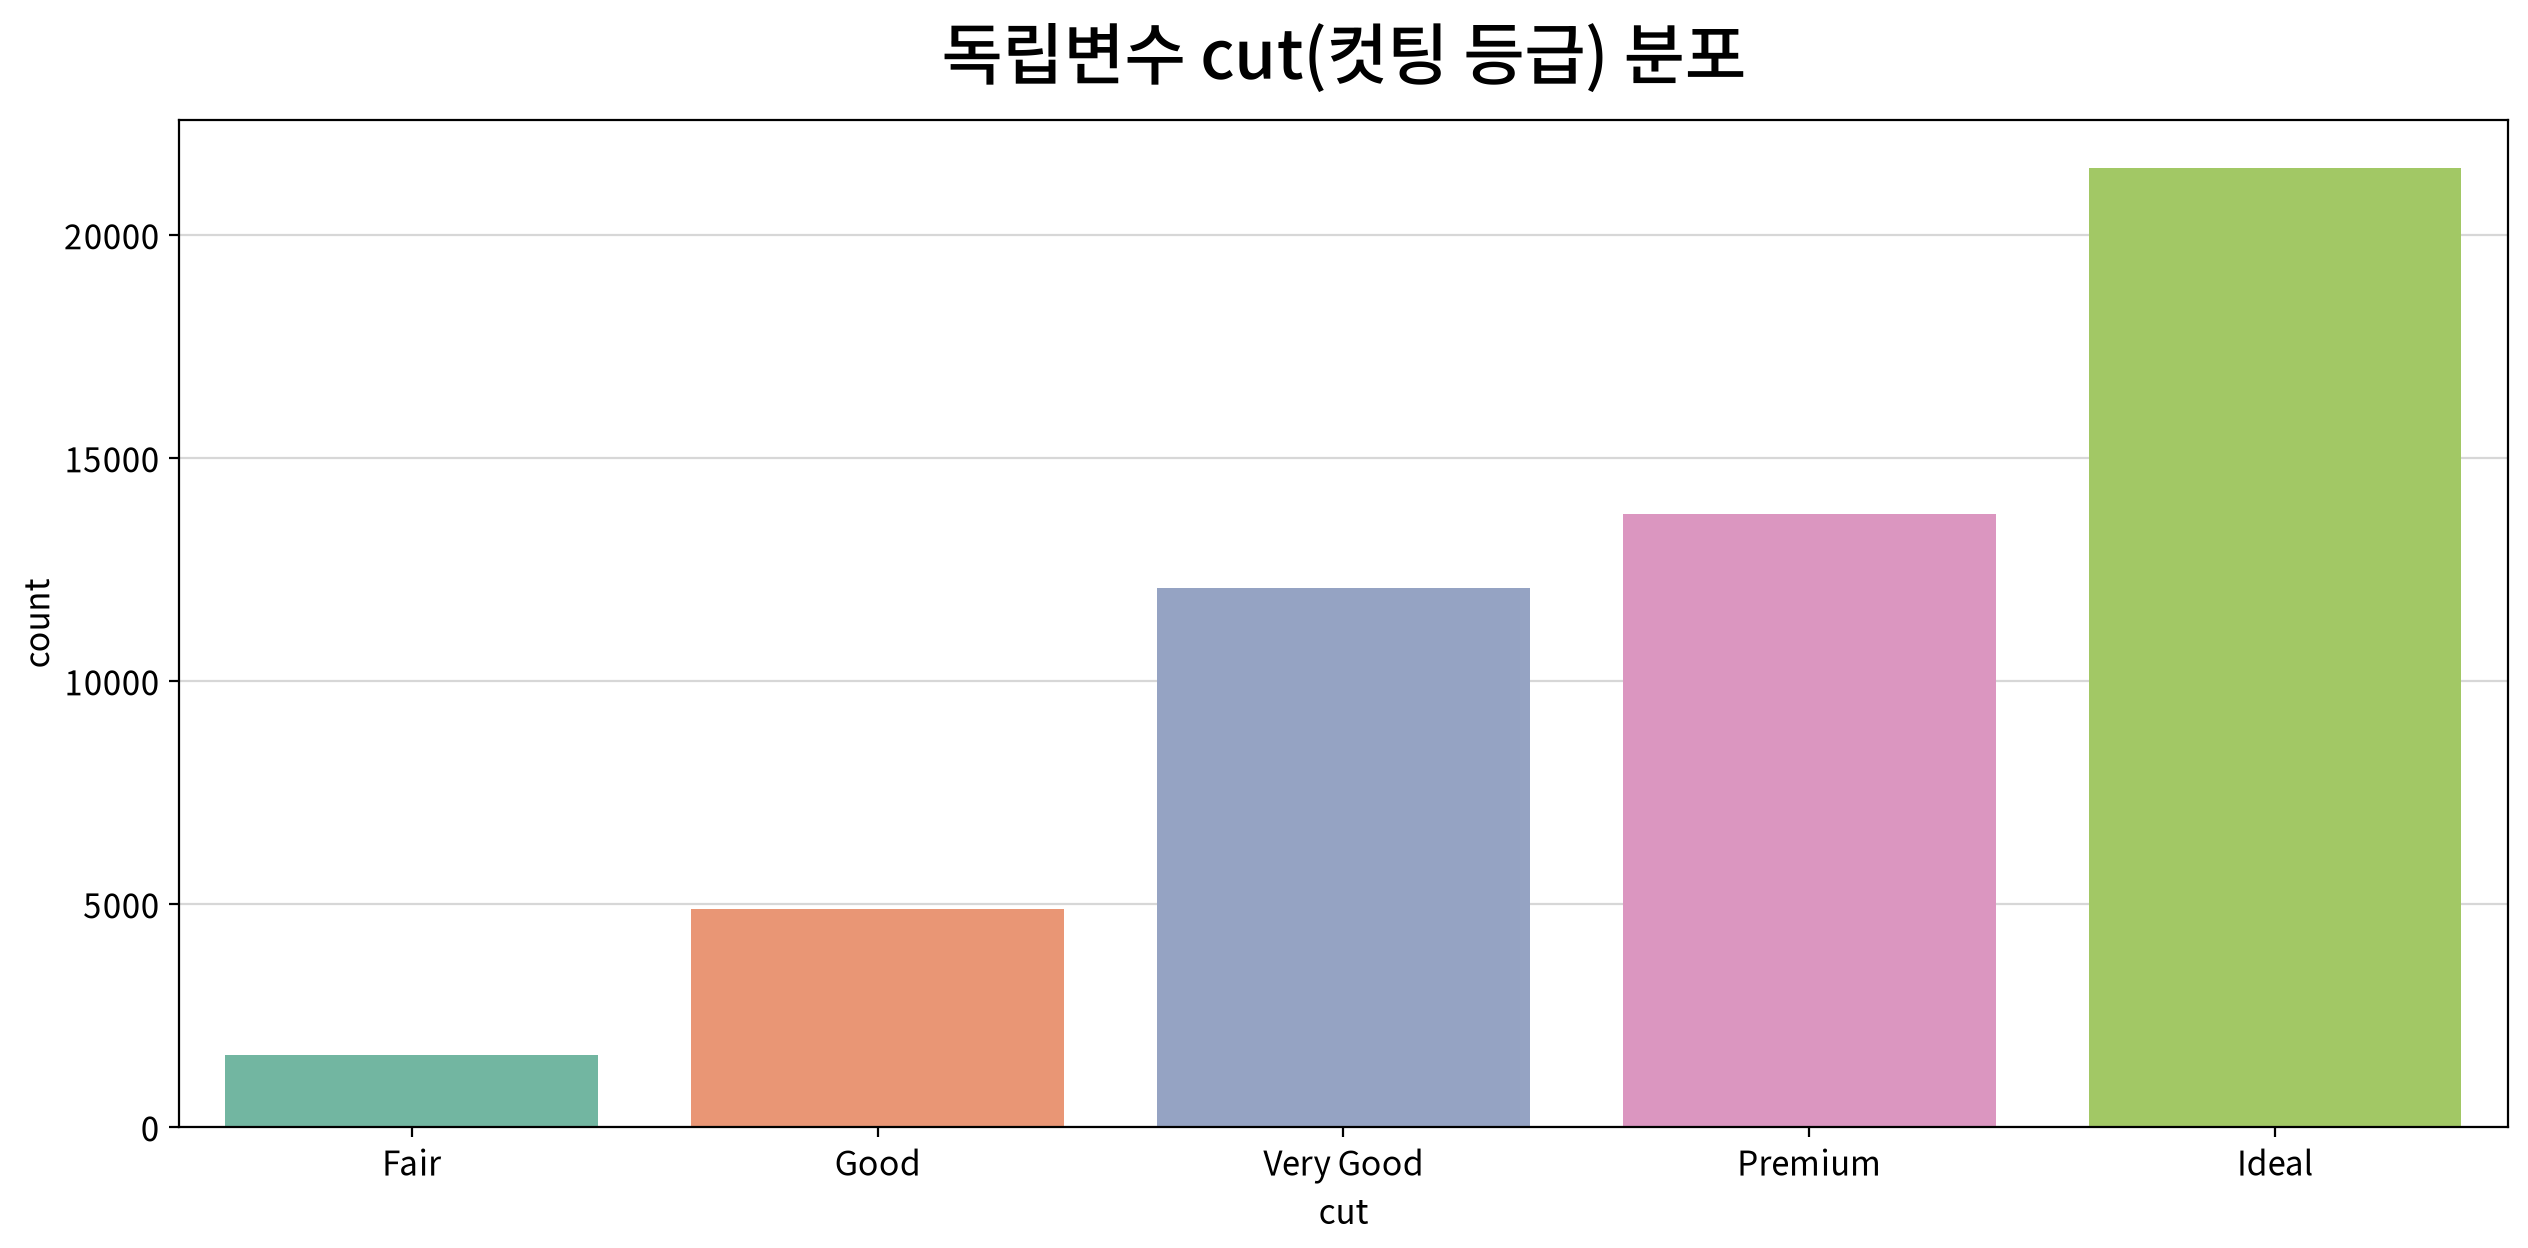

,count,unique,top,freq
cut,53794,5,Ideal,21488


,빈도,비율
cut,,
Ideal,21488,0.399
Premium,13748,0.256
Very Good,12069,0.224
Good,4891,0.091
Fair,1598,0.030


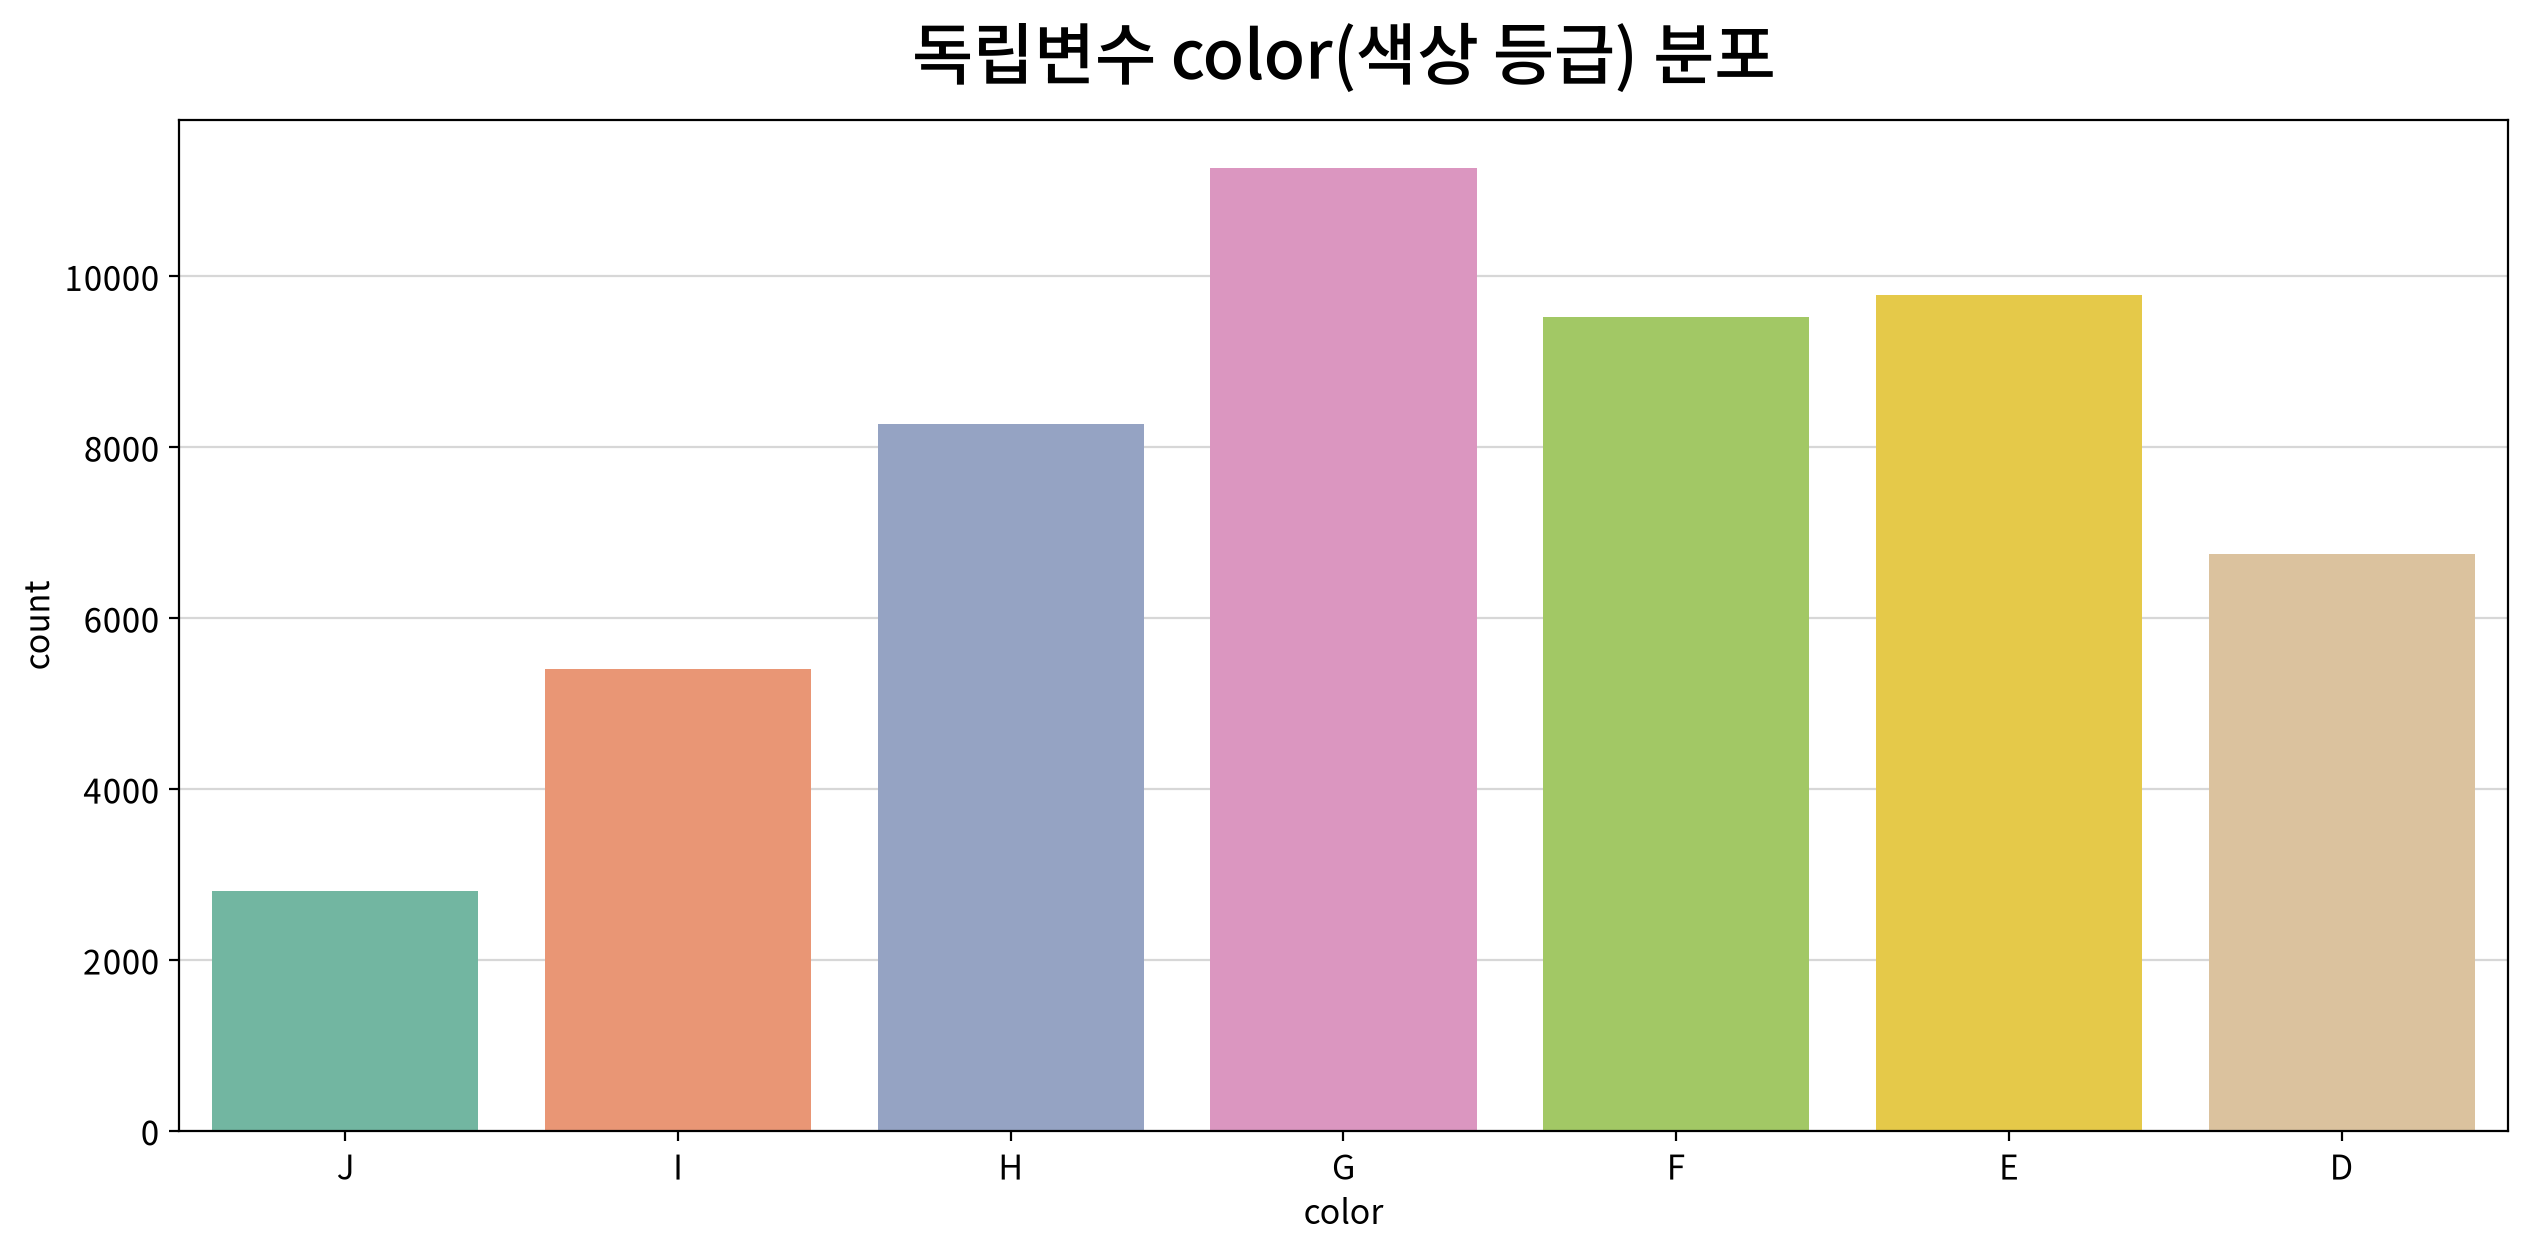

,count,unique,top,freq
color,53794,7,G,11262


,빈도,비율
color,,
G,11262,0.209
E,9776,0.182
F,9520,0.177
H,8272,0.154
D,6755,0.126
I,5407,0.101
J,2802,0.052


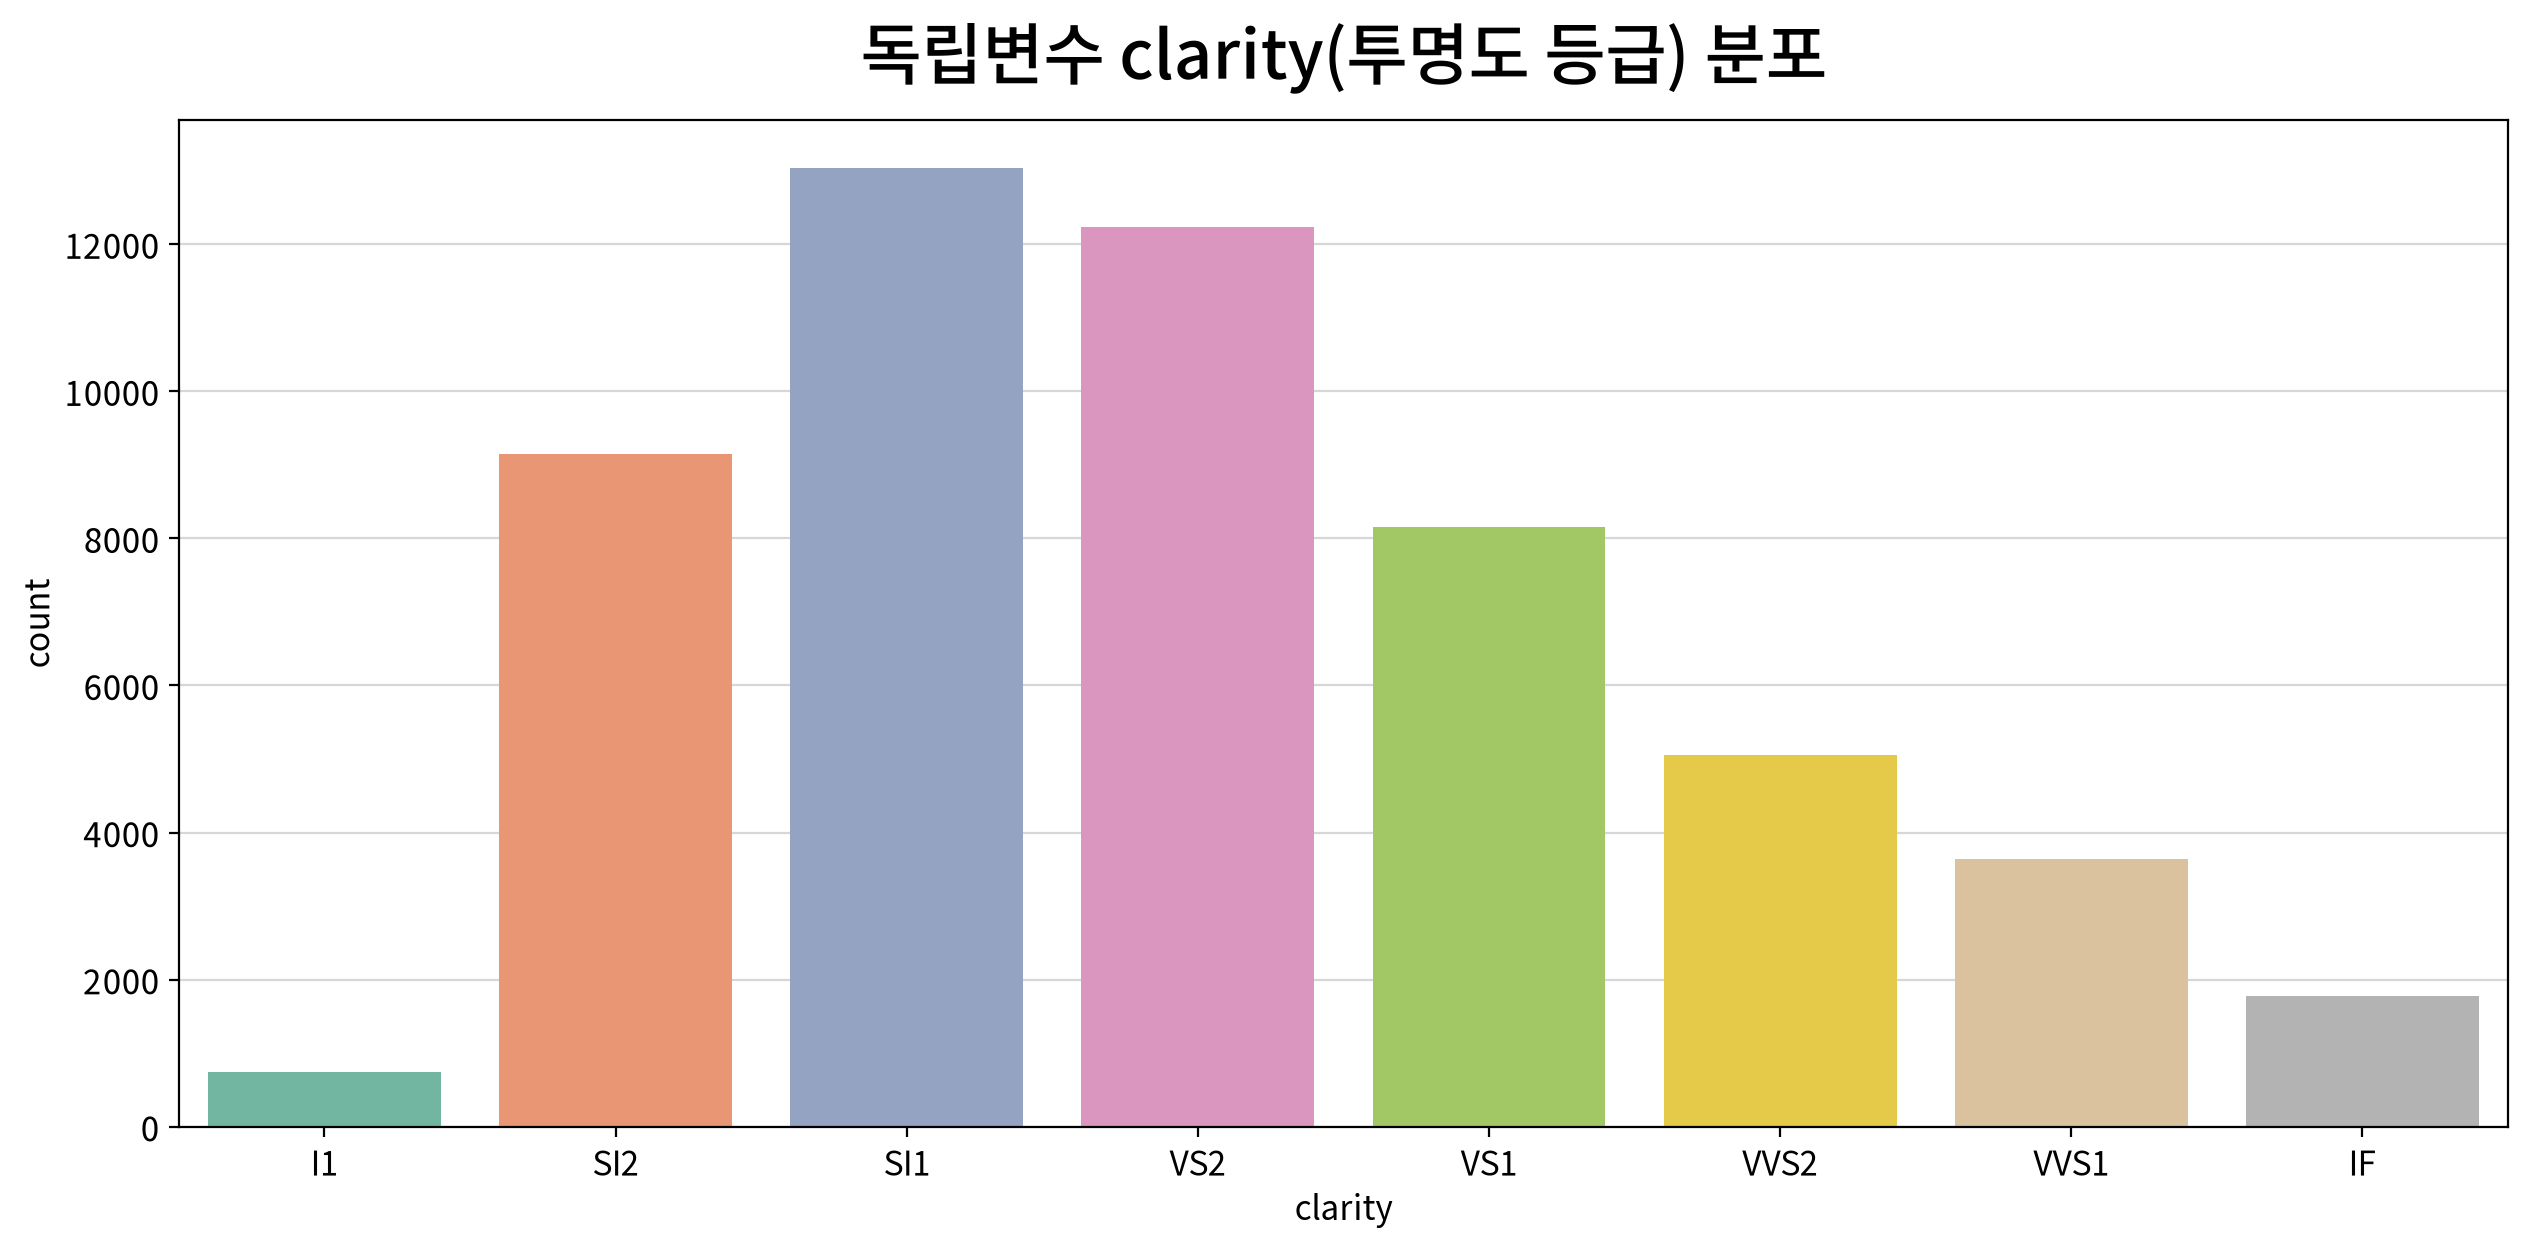

,count,unique,top,freq
clarity,53794,8,SI1,13032


,빈도,비율
clarity,,
SI1,13032,0.242
VS2,12229,0.227
SI2,9150,0.170
VS1,8156,0.152
VVS2,5056,0.094
VVS1,3647,0.068
IF,1784,0.033
I1,740,0.014


In [50]:
for n in nominal_cols:
    # 명목형 분포는 카운트 플롯으로 처리한다.
    my_plot.countplot(data=df, x=n, hue=n, palette="Set2",
    title=f"독립변수 {n}({column_means[n]}) 분포")

    # 명목형 기술통계량
    display(cat_desc[[n]].T)

    # 추가적으로 빈도표 생성
    freq=df[n].value_counts().rename("빈도").to_frame()
    # value_counts(normalize=True)
    # -- > 전체 고유값의 개수(빈도수) 대신 전체 데이터의 비율을 계산
    freq["비율"] = df[n].value_counts(normalize=True)
    display(freq)

#### 💡 인사이트

| 변수 | 범주 수 | 최빈 범주(비율) | 최소 범주(비율) | 균형 여부 | 판단·조치 |
|---|---|---|---|---|---|
| `cut` | 5 | Ideal 21,488 (39.9%) | Fair 1,598 (3.0%) | 다소 불균형 | 3집단 이상 → **ANOVA** 대상 |
| `color` | 7 | G 11,262 (20.9%) | J 2,802 (5.2%) | 비교적 균형 | 3집단 이상 → **ANOVA** 대상 |
| `clarity` | 8 | SI1 13,032 (24.2%) | I1 740 (1.4%) | 불균형(I1 소수) | 3집단 이상 → **ANOVA** 대상 |


#### 4-2. 변수 간 관계

##### 1) 상관분석 (x: 연속형 독립변수 → y: 연속형 종속변수)

#### ▶ carat(중량) → price

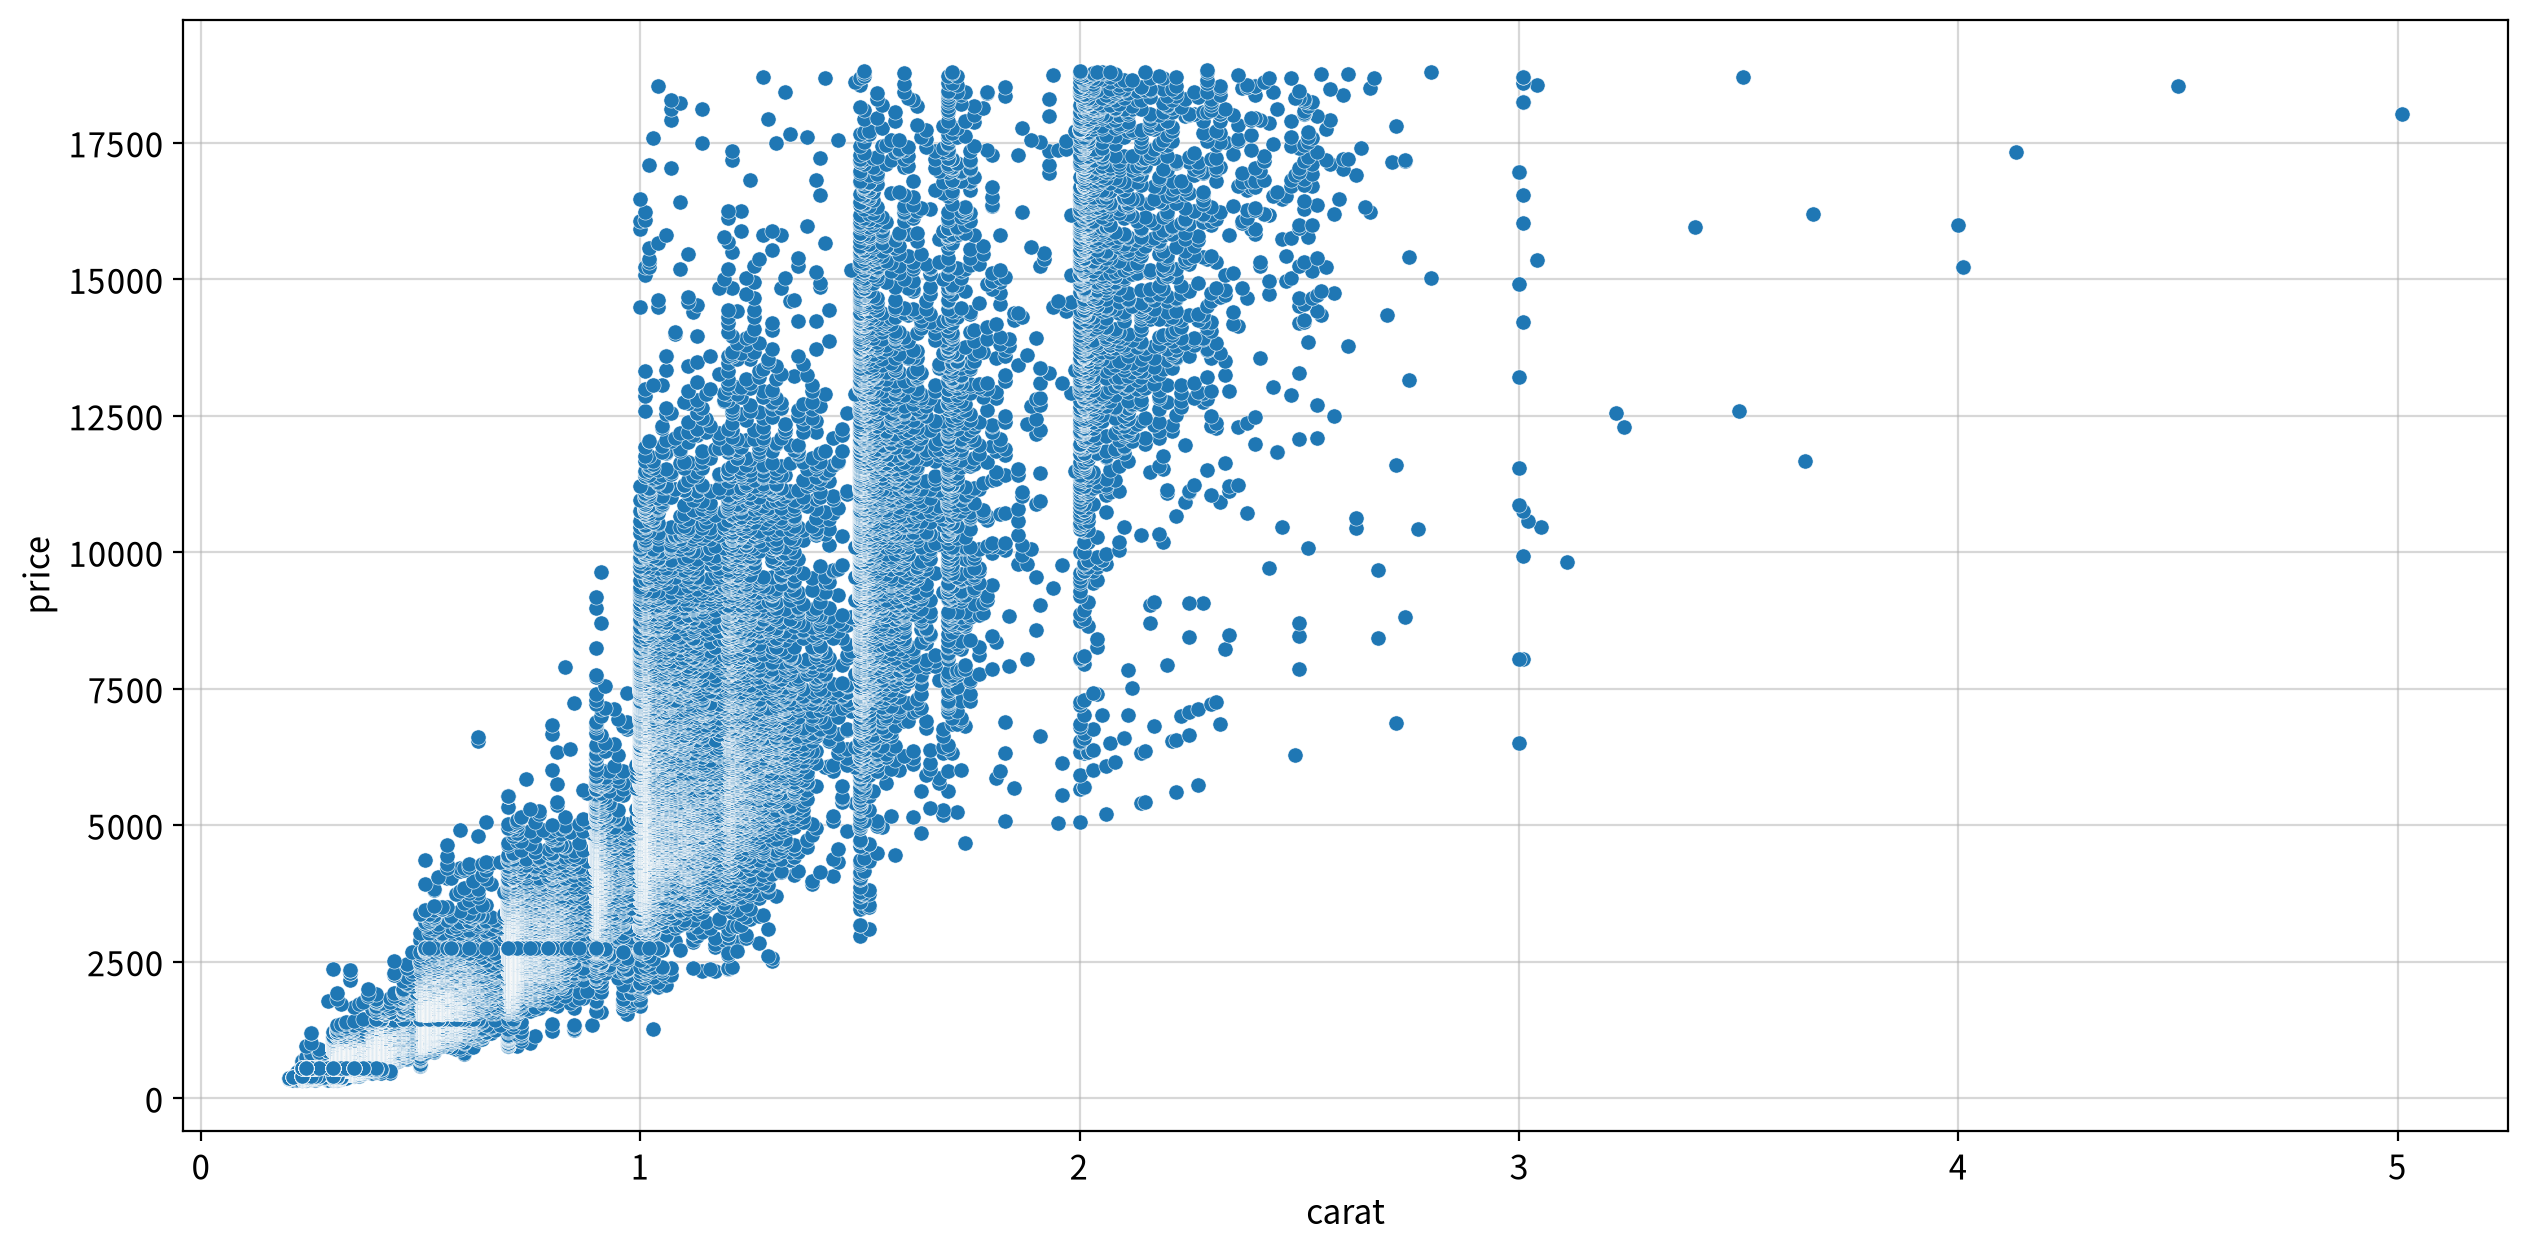

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
carat,price,Spearman,0.963,0.000,Strong,True,False,False,False,False,True


Pearson corelation coefficient: 0.9215, p-value: 0.0000
Spearman corelation coefficient: 0.9629, p-value: 0.0000



#### ▶ x(길이(mm)) → price

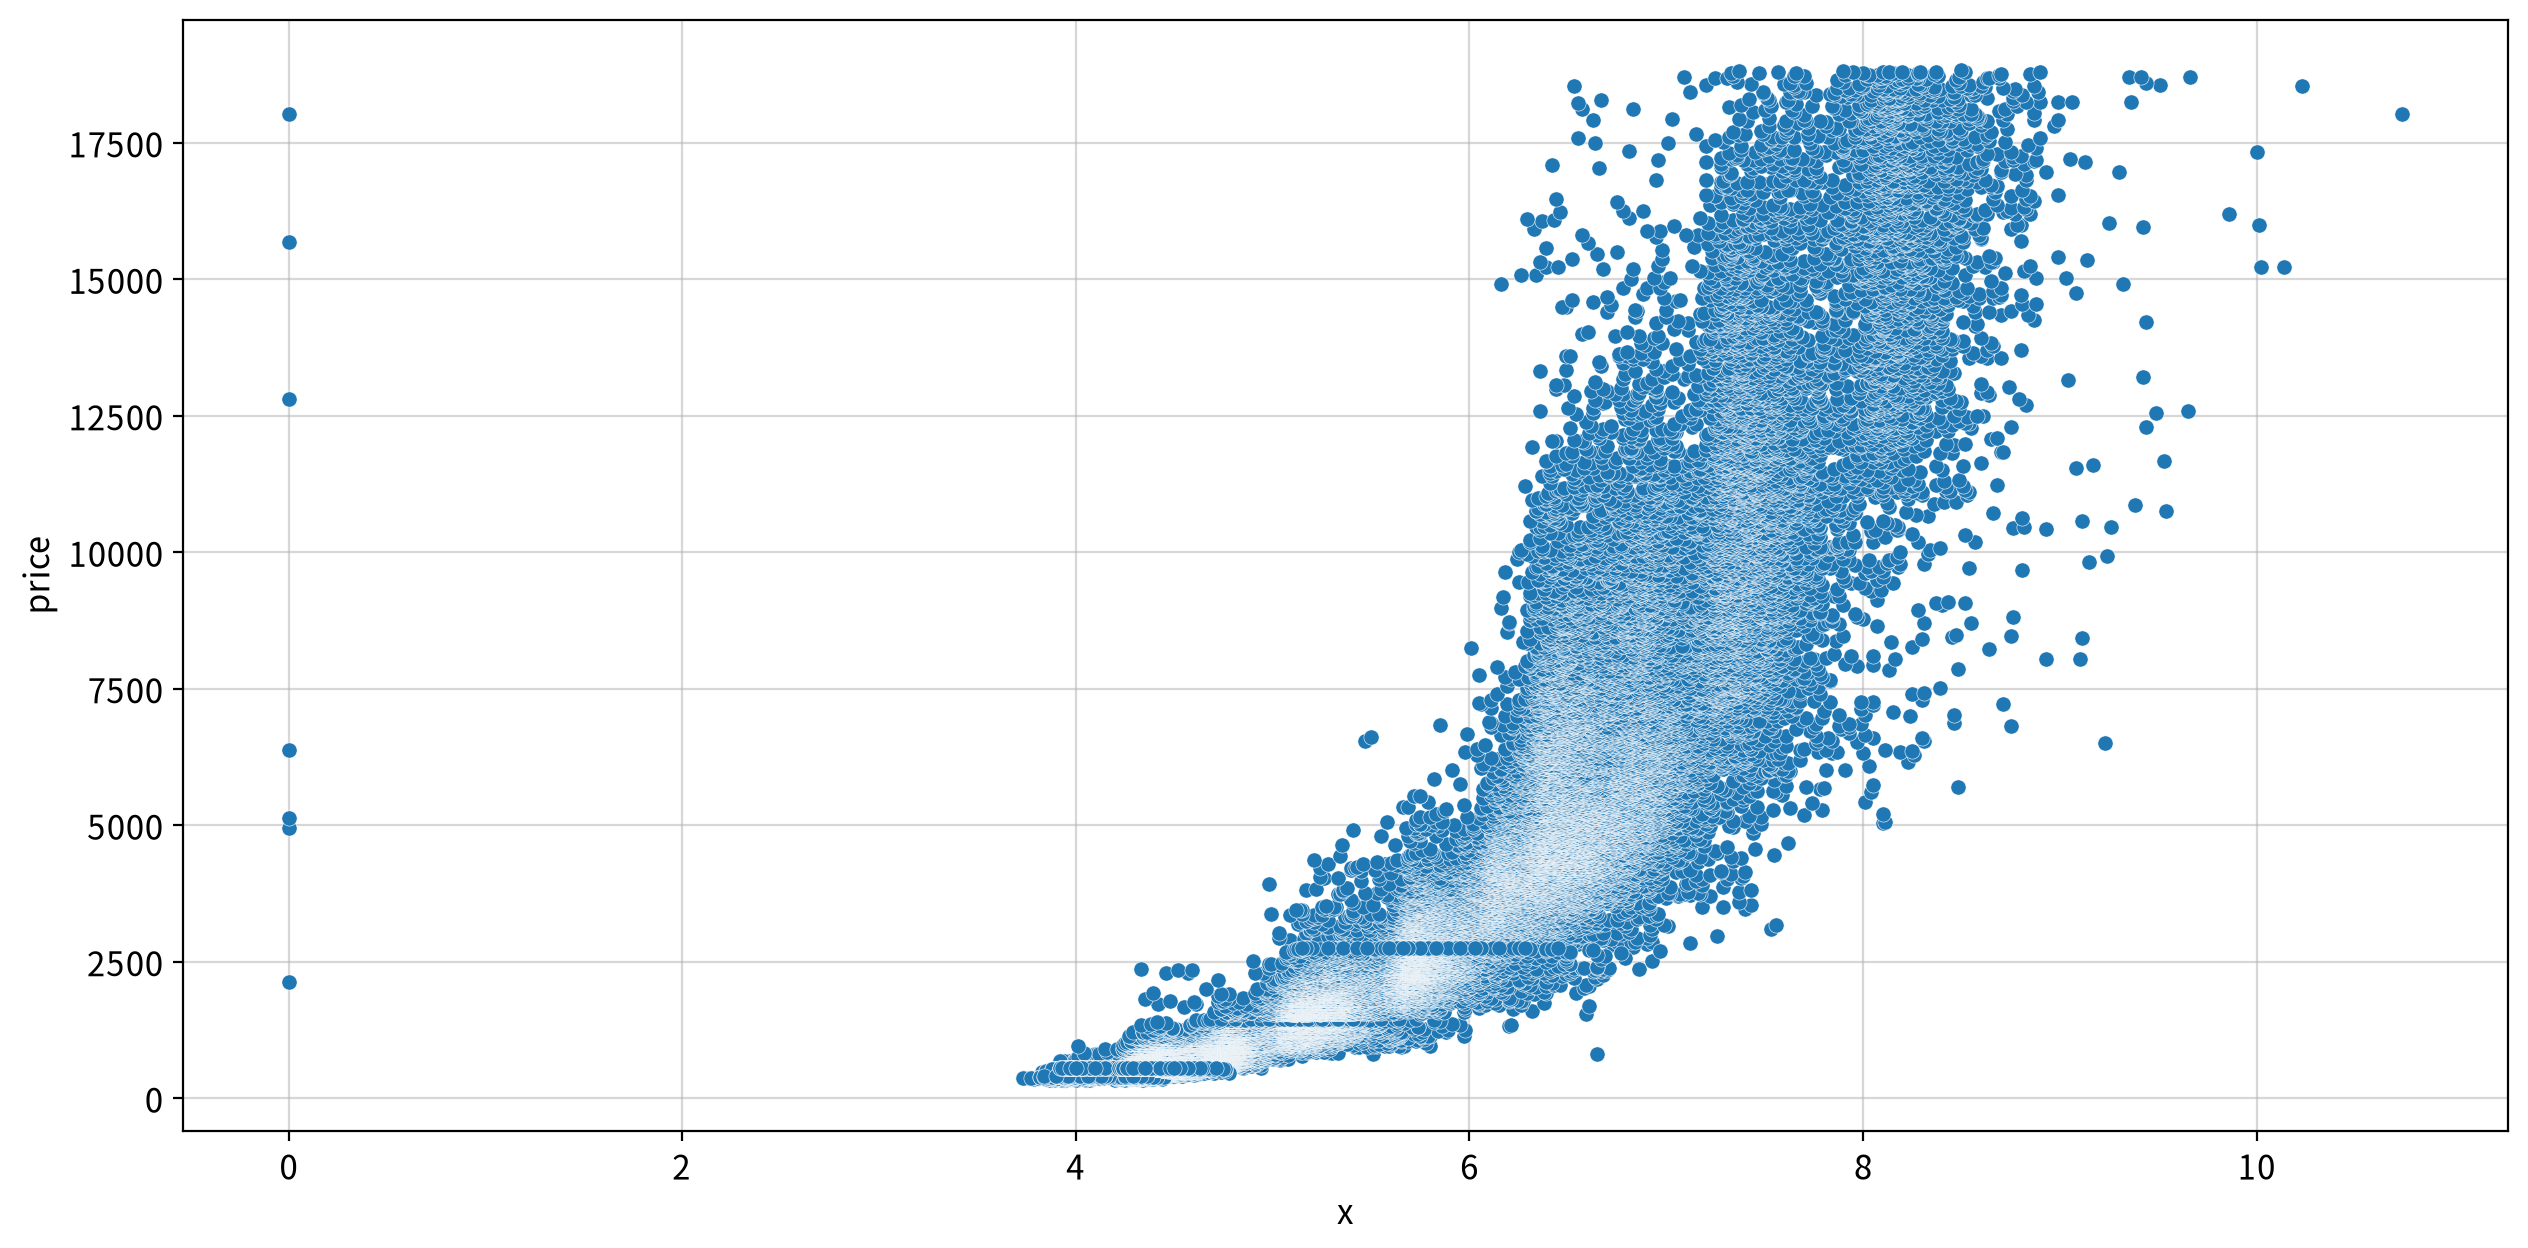

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
x,price,Spearman,0.963,0.000,Strong,True,False,False,False,False,True


Pearson corelation coefficient: 0.8845, p-value: 0.0000
Spearman corelation coefficient: 0.9633, p-value: 0.0000



#### ▶ y(너비(mm)) → price

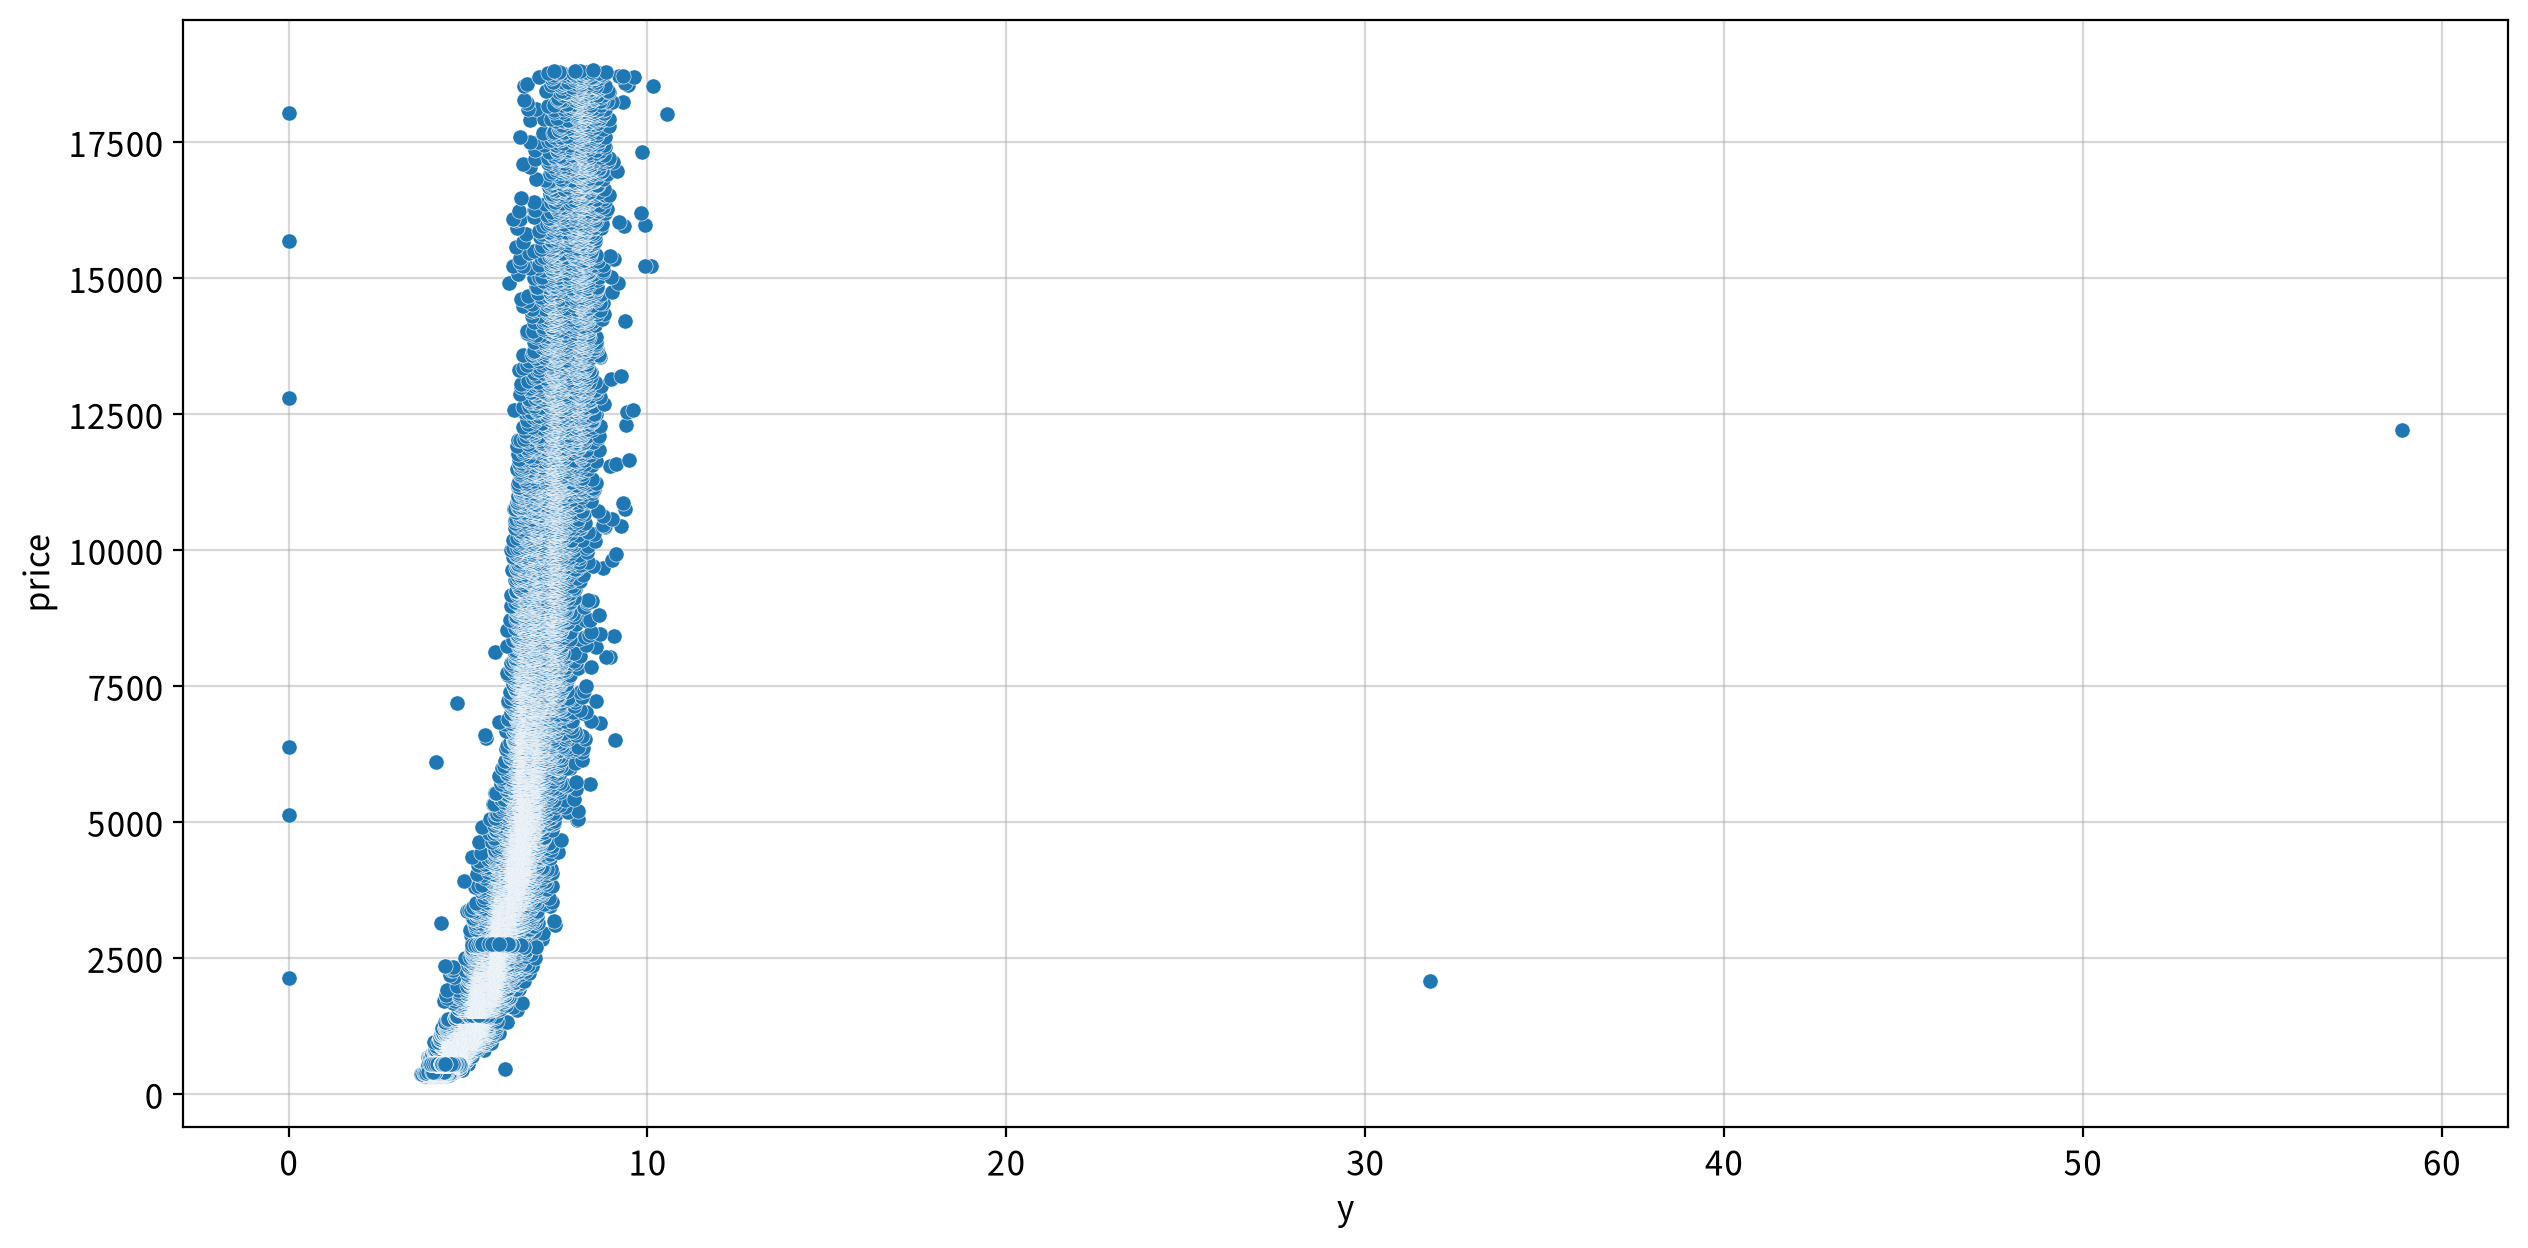

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
y,price,Spearman,0.963,0.000,Strong,True,False,False,False,False,True


Pearson corelation coefficient: 0.8654, p-value: 0.0000
Spearman corelation coefficient: 0.9628, p-value: 0.0000



#### ▶ z(두께(mm)) → price

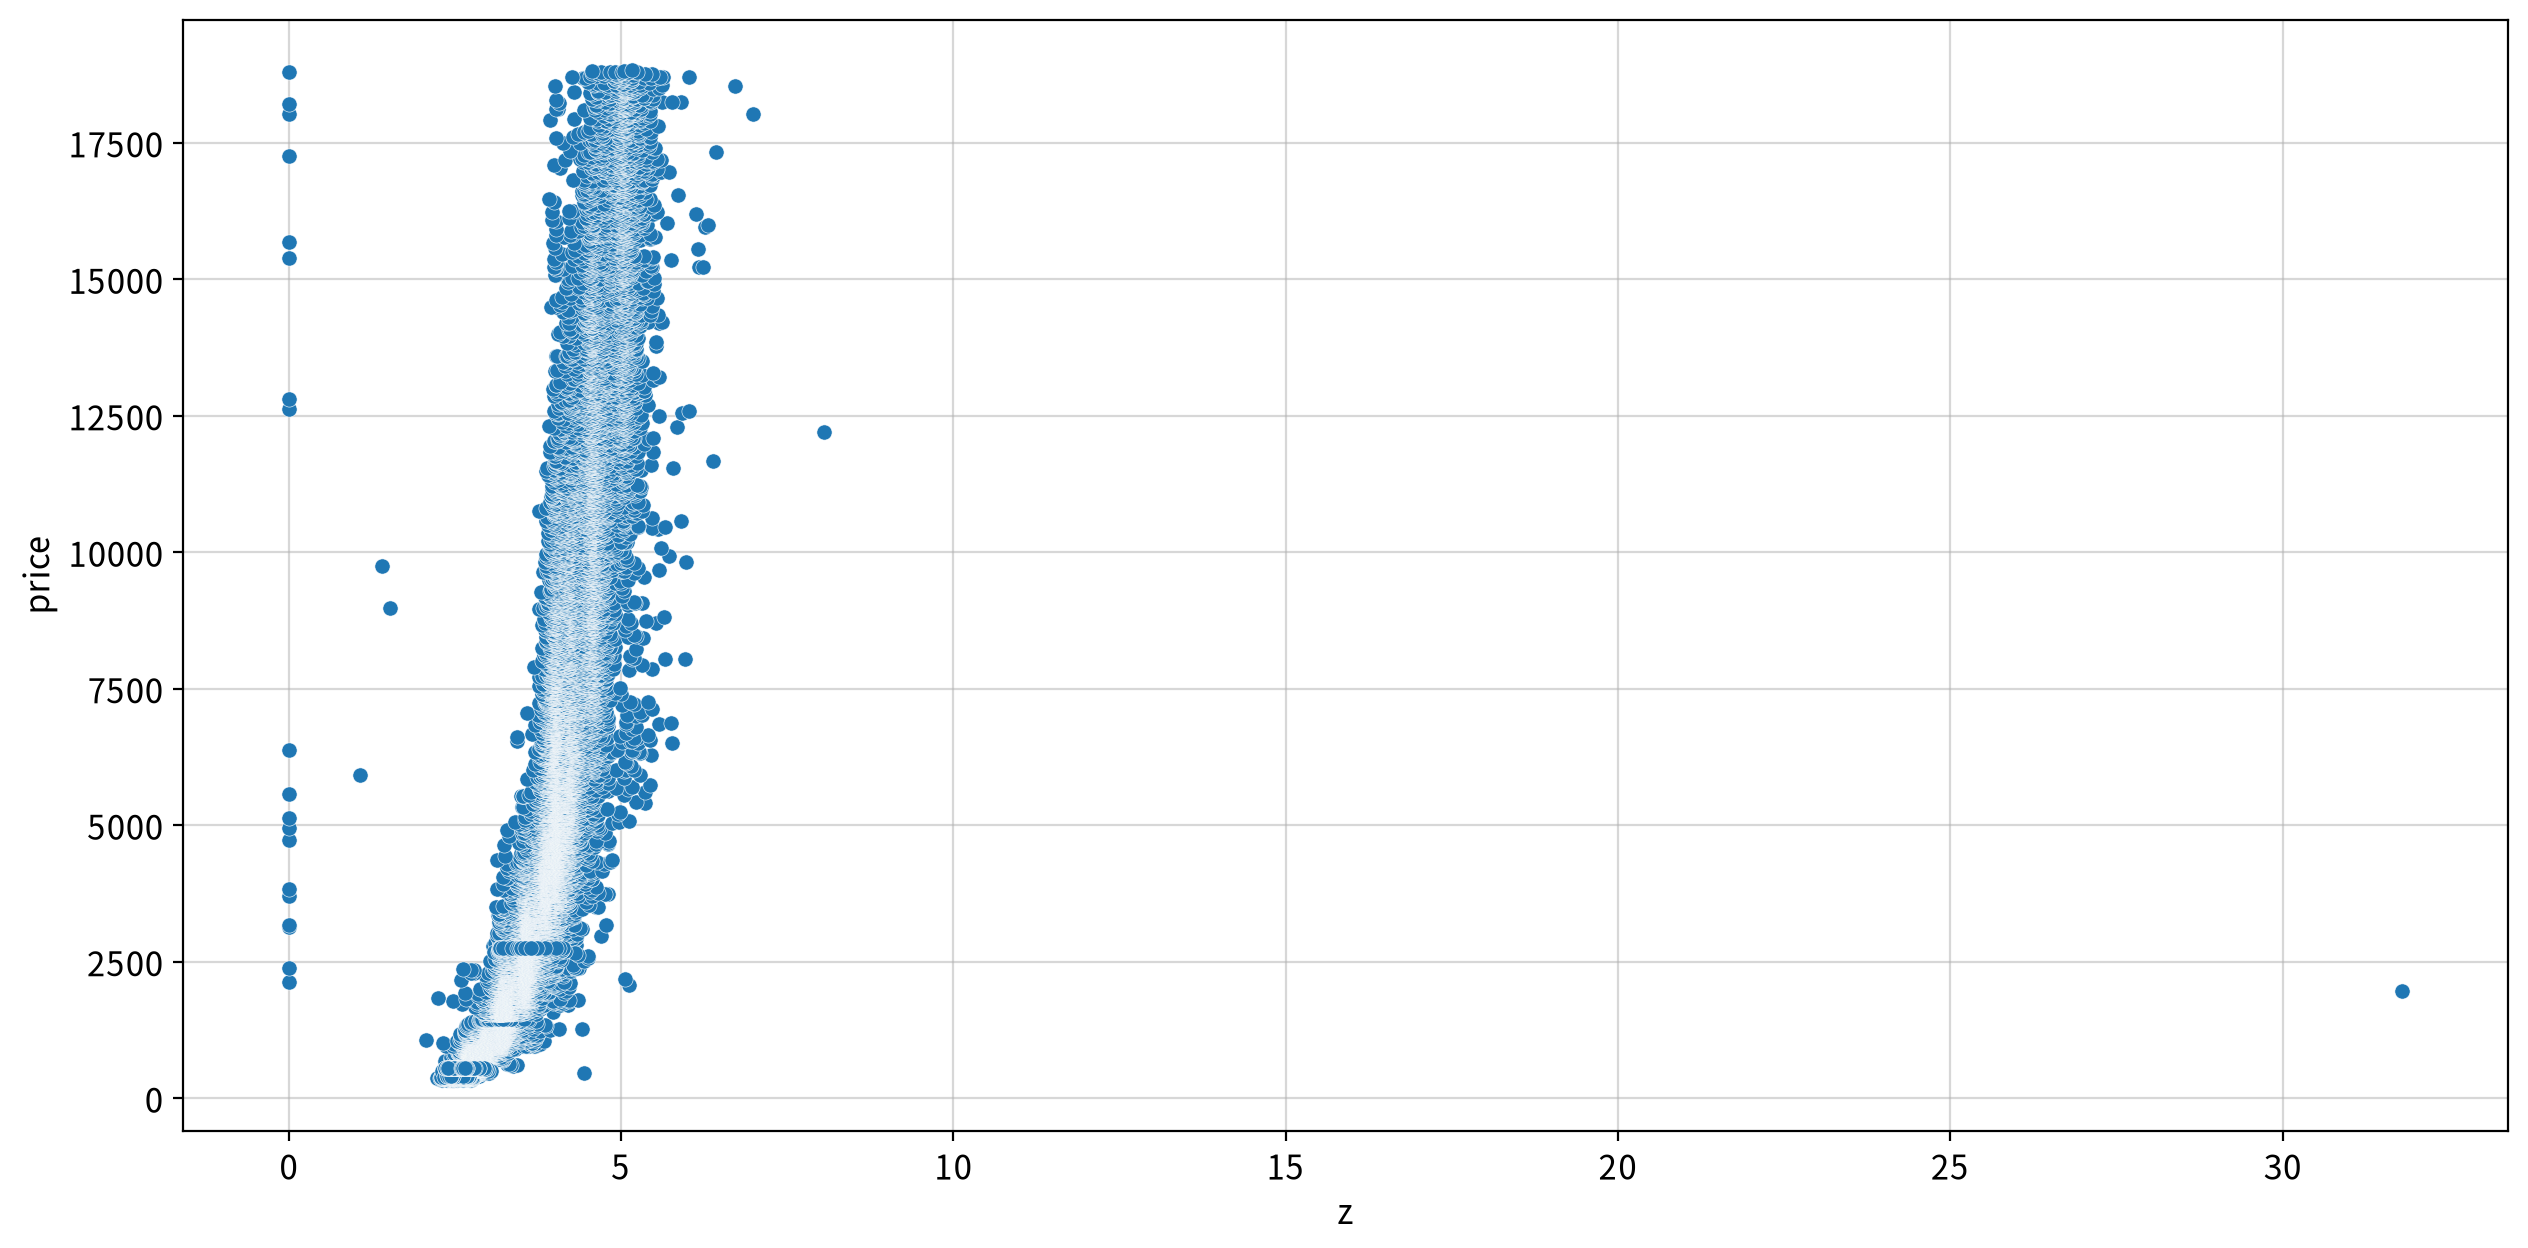

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
z,price,Spearman,0.957,0.000,Strong,True,False,False,False,False,True


Pearson corelation coefficient: 0.8612, p-value: 0.0000
Spearman corelation coefficient: 0.9573, p-value: 0.0000



#### ▶ depth(비율 정보) → price

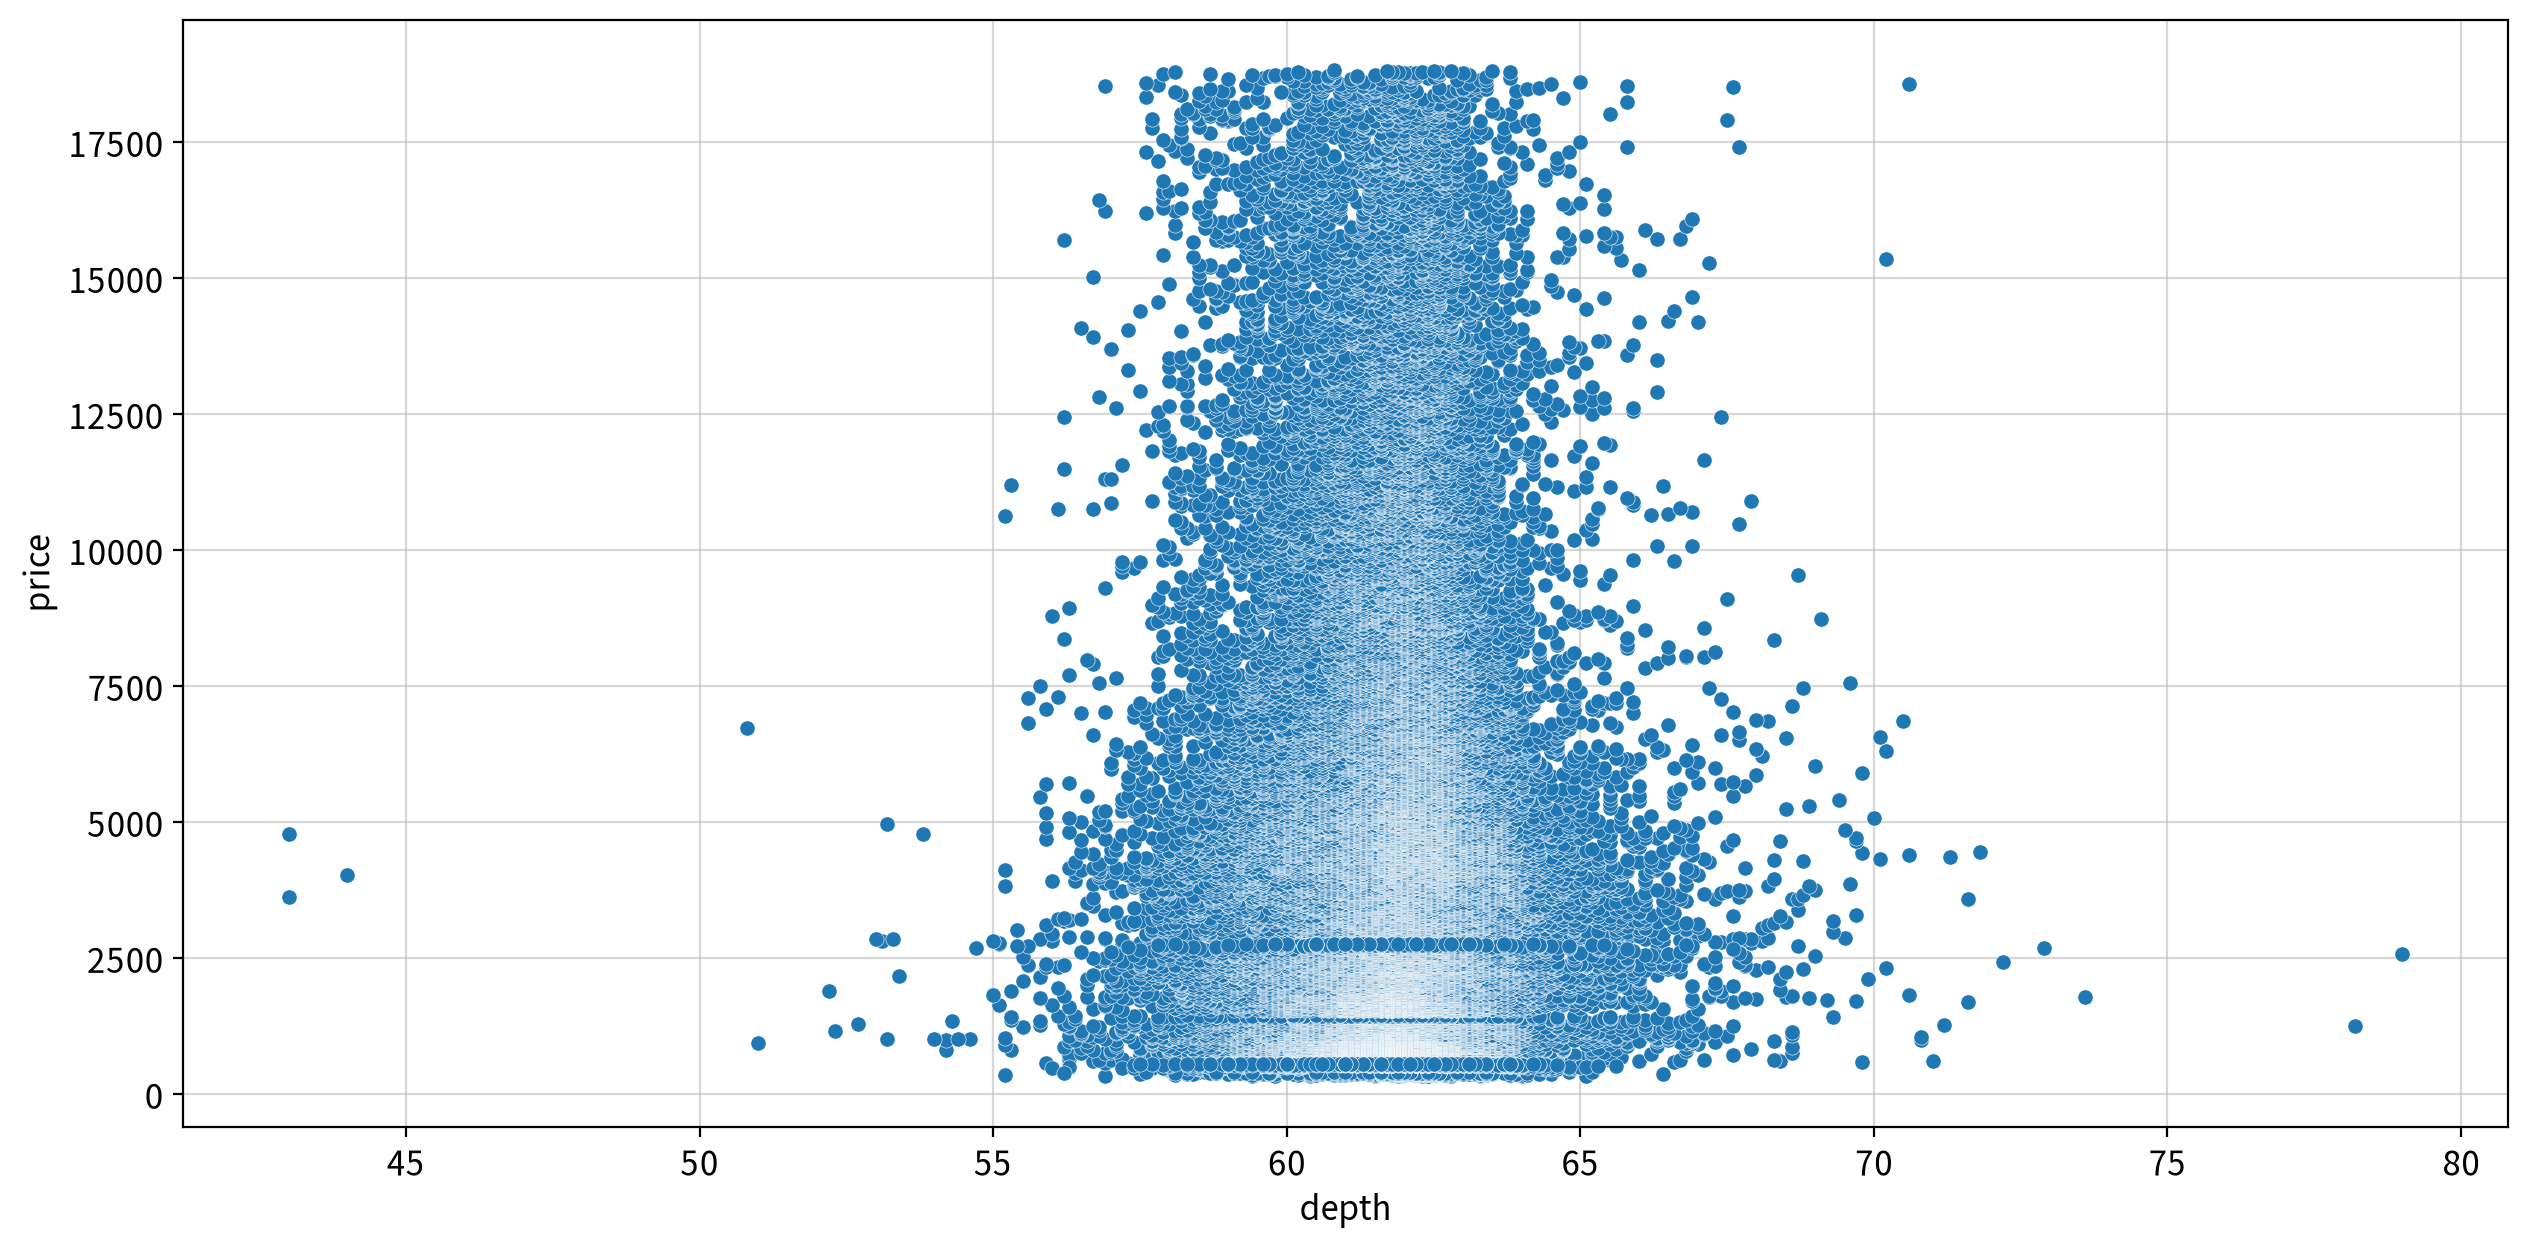

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
depth,price,Spearman,0.010,0.018,Weak,True,False,False,False,False,True


Pearson corelation coefficient: -0.0110, p-value: 0.0104
Spearman corelation coefficient: 0.0102, p-value: 0.0182



#### ▶ table(테이블 너비) → price

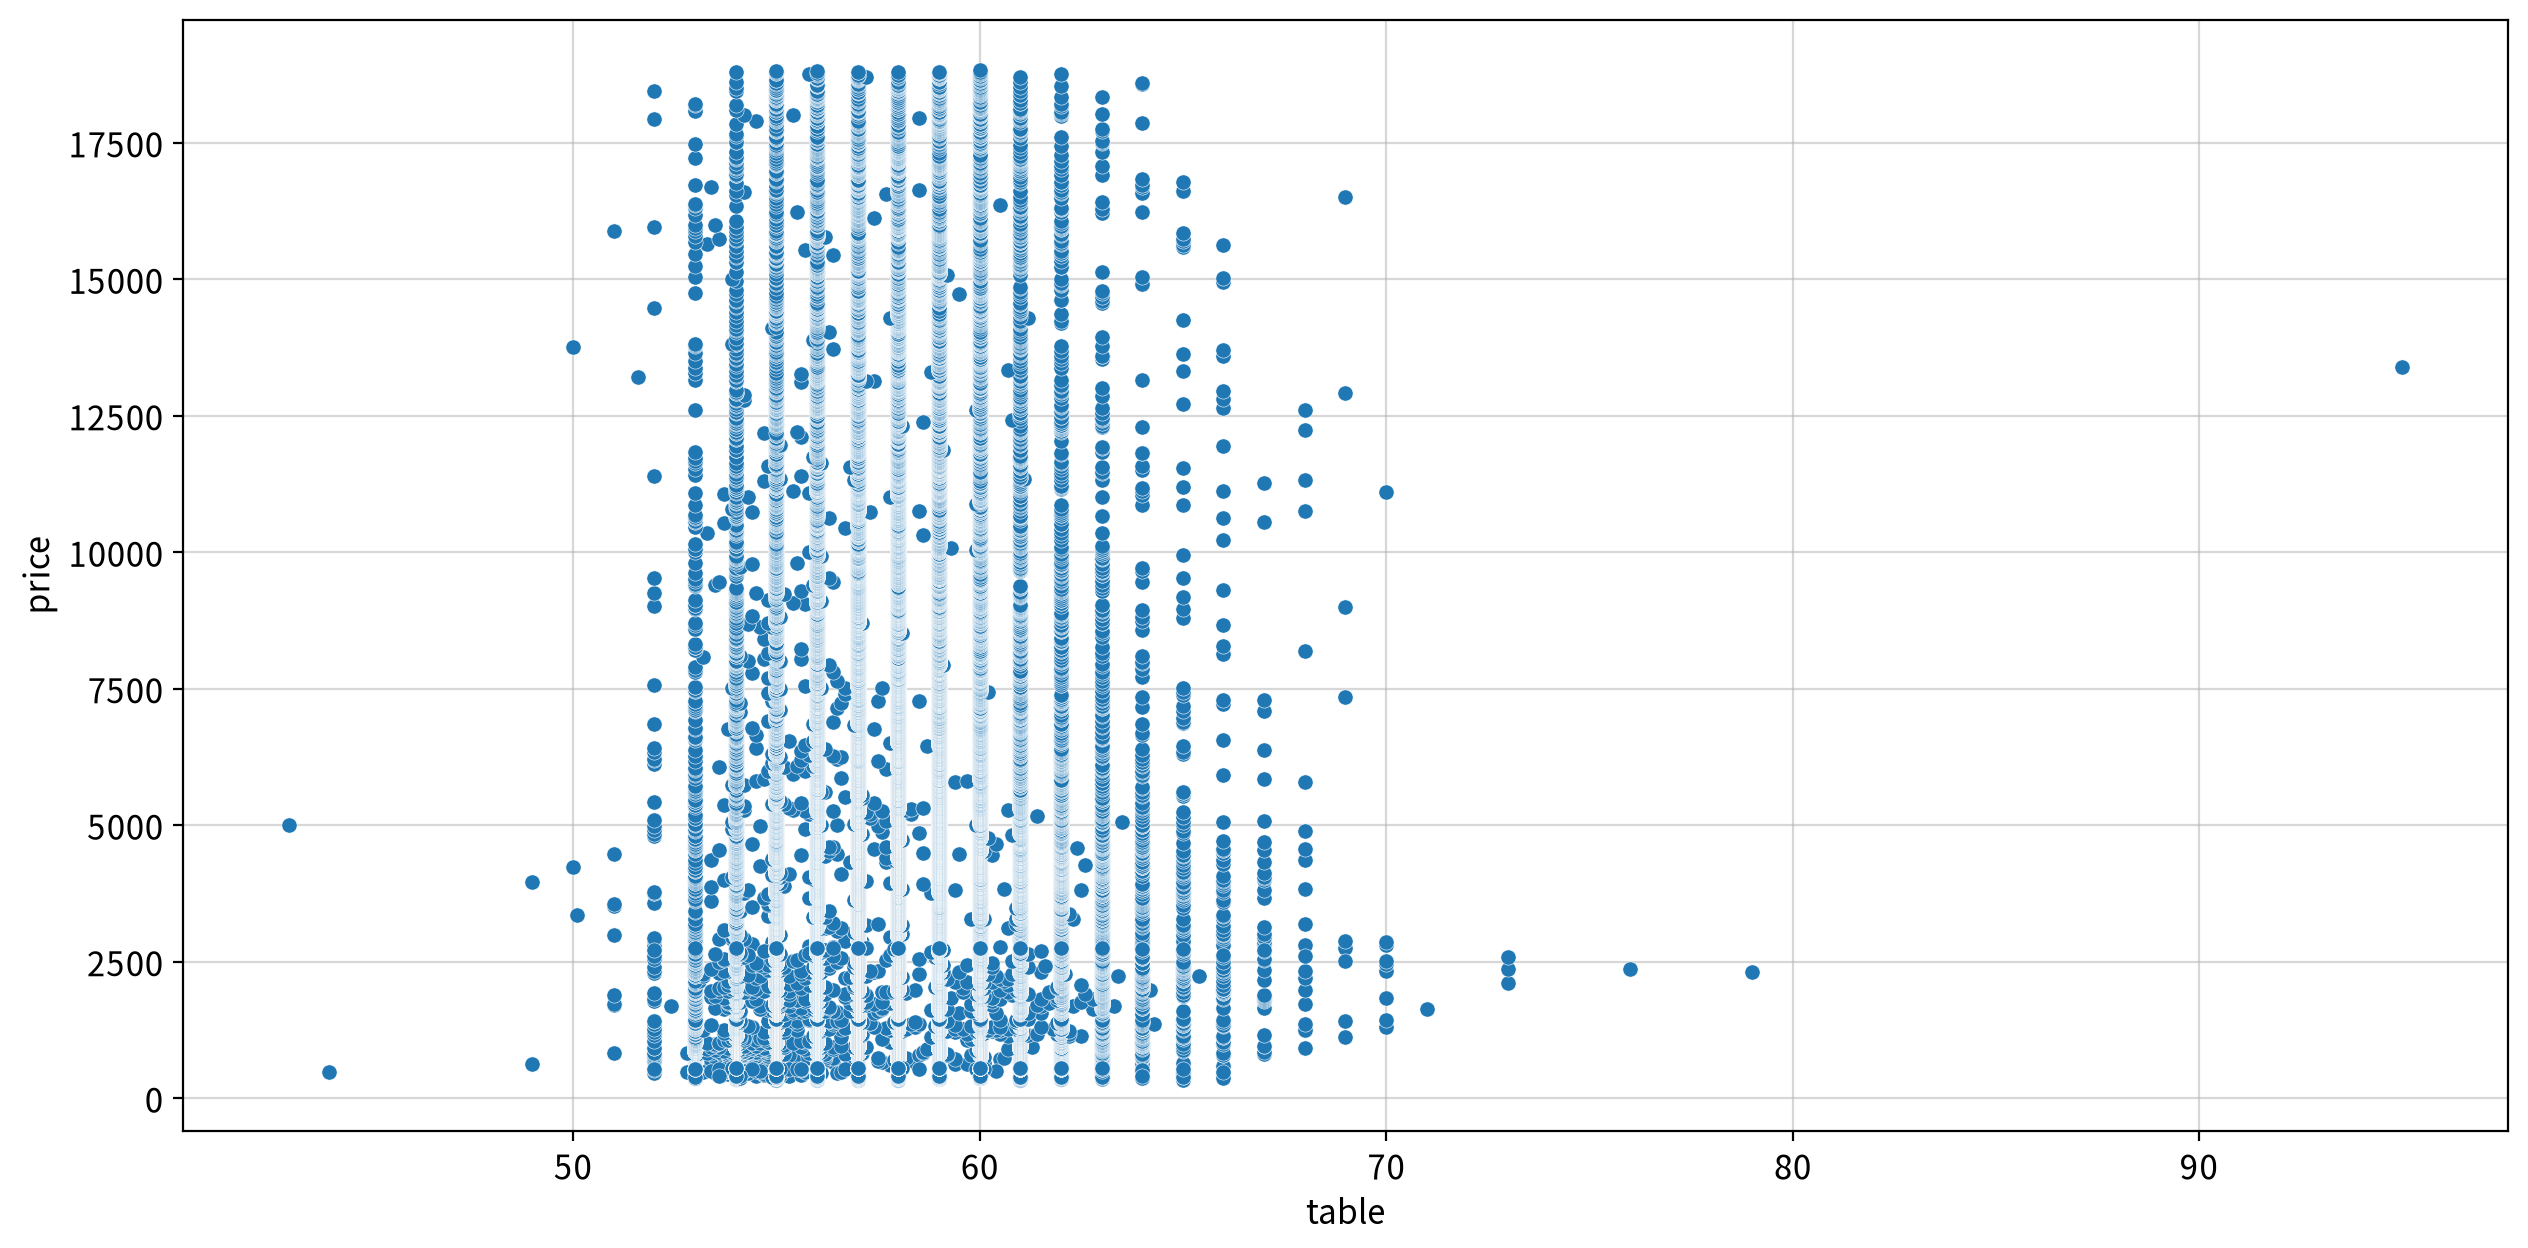

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
table,price,Spearman,0.171,0.000,Weak,True,False,False,False,False,True


Pearson corelation coefficient: 0.1266, p-value: 0.0000
Spearman corelation coefficient: 0.1710, p-value: 0.0000


In [ ]:
from scipy. stats import pearsonr, spearmanr

#  연속형 독립변수 이름을 탐색하면서 반복
for f in continuous_cols:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### ▶ {f}({column_means[f]}) → {target}"))

    # 시각화
    my_plot.scatterplot(data=df, x=f, y=target, outline=False,
    # 데이터 밀도에 따라 외곽선 굵기와 점 크기 조절
    linewidth=0.2, size=30)

    # my_stats는 시각화까지 일괄처리 한다.
    display(my_stats.correlation(df, x=f, y=target, plot=False))

    # 피어슨 vs 스피어만 상관계수 비교 (피어슨 < 스피어만 => 비선형 or 단조 관계 신호)
    pearson_r, pearson_p = pearsonr(df[f], df[target])
    print(f"Pearson corelation coefficient: {pearson_r:.4f}, p-value: {pearson_p:.4f}")

    spearman_r, spearman_p = spearmanr(df[f], df[target])
    print(f"Spearman corelation coefficient: {spearman_r:.4f}, p-value: {spearman_p:.4f}")

#### 💡 인사이트

| 변수 | 선형/비선형 | 단조성 | 산포 | 이상치 | 채택 여부 |
|---|---|---|---|---|---|
| `carat` | **비선형** (위로 볼록, r=0.92 < ρ=0.96) | **강한 양의 단조↑** (ρ=+0.963) | **강한 이분산** (부채꼴, 커질수록 분산↑) | 상단 고가 꼬리 | ✅ **채택 (최우선)** |
| `x` | 비선형 (곡선, r=0.89 < ρ=0.96) | 강한 양의 단조↑ (ρ=+0.963) | 강한 이분산 | 0mm 추세 이탈값 | ✅ 채택 |
| `y` | 비선형 (곡선, r=0.87 < ρ=0.96) | 강한 양의 단조↑ (ρ=+0.963) | 강한 이분산 | **58.9mm 극단 이탈** | ✅ 채택 |
| `z` | 비선형 (곡선, r=0.86 < ρ=0.96) | 강한 양의 단조↑ (ρ=+0.957) | 강한 이분산 | **31.8mm 극단 이탈** | ✅ 채택 |
| `depth` | 무관 (r≈0) | 단조성 없음 (ρ=+0.010) | 등분산 (관계 자체가 없음) | 판단 무의미 | ❌ **제외** — n=53,794로 유의만 떴을 뿐 효과 없음 |
| `table` | 사실상 무관 (r=0.13) | 약한 양의 단조 (ρ=+0.171) | 약한 이분산 | 소수 | 🟡 **보류** — 유의하나 설명력 미미 |


- **`carat`·`x`·`y`·`z`**: 강한 양의 단조 증가지만 **비선형(위로 휘는 곡선) + 이분산(부채꼴)** → `price`·`carat` **로그 변환** 시 선형화·등분산화 기대.
- 4종 모두 ρ≈0.96으로 **동률** → 서로 같은 정보일 가능성이 크다(다변량 단계에서 공선성 확인).


##### 2) T-Test (x: 2집단 명목형 독립변수 → y: 종속변수)

- 2개의 고유값만 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
  - 2개 이상의 고유값을 갖는 명목형이 없을 경우 출력 결과가 없을 수 있다.

In [18]:
for n in nominal_cols:
    # 2개의 고유값만 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) == 2:
        # 빈 줄 출력용
        print()

        # 분석 단위 제목 출력
        display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

        # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
        wide_df = my_prep.long2wide(df, hue=n, values=target)
        display(my_stats.test_independent(wide_df, 
                    group1=wide_df.columns[0], group2=wide_df.columns[1]))

#### 💡 인사이트

> 이 데이터셋에는 해당 없음

##### 3) ANOVA (x: 3집단 명목형 독립변수 → y: 종속변수)

- 3개 이상의 고유값이 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
  - 3개 이상의 고유값을 갖는 명목형이 없을 경우 출력 결과가 없을 수 있다.

In [19]:
for n in nominal_cols:
    # 3개 이상의 고유값이 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) >= 3:
        print() # 빈 줄 출력용

        # 분석 단위 제목 출력
        display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

        # origin이 아닌 df를 사용해야 서열척도로 지정한 범주 순서가 반영된다.
        display(my_stats.anova_oneway(df, y=target, between=n))
        
        # 사후검정
        display(my_stats.posthoc_oneway(df, y=target, between=n, plot=False))

#### ▶︎ cut(컷팅 등급) → price

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,cut,4,9347.505,163.115,0.000,0.013,Small


비교한 조합 쌍: 10개
유의한 쌍: 8개
평균 차이가 가장 큰 쌍: (Premium) vs (Ideal) → 차이 1120.752, 효과크기 Small, p-value 0.000
평균 차이가 가장 작은 쌍: (Good) vs (Very Good) → 차이 61.895, 효과크기 Negligible, p-value 0.867


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,Fair,Good,4341.954,3919.121,422.833,102.947,4.107,2803.307,0.000,0.116,True,Negligible
1,Games-Howell,Fair,Very Good,4341.954,3981.016,360.938,95.527,3.778,2154.562,0.002,0.093,True,Negligible
2,Games-Howell,Fair,Premium,4341.954,4583.502,-241.548,96.009,-2.516,2198.298,0.087,-0.057,False,Negligible
3,Games-Howell,Fair,Ideal,4341.954,3462.750,879.204,92.295,9.526,1883.080,0.000,0.232,True,Small
4,Games-Howell,Good,Very Good,3919.121,3981.016,-61.895,63.547,-0.974,9655.235,0.867,-0.016,False,Negligible
5,Games-Howell,Good,Premium,3919.121,4583.502,-664.381,64.270,-10.337,10094.516,0.000,-0.159,True,Negligible
6,Games-Howell,Good,Ideal,3919.121,3462.750,456.371,58.577,7.791,7480.705,0.000,0.121,True,Negligible
7,Games-Howell,Very Good,Premium,3981.016,4583.502,-602.486,51.556,-11.686,25791.196,0.000,-0.145,True,Negligible
8,Games-Howell,Very Good,Ideal,3981.016,3462.750,518.266,44.257,11.710,24339.407,0.000,0.134,True,Negligible
9,Games-Howell,Premium,Ideal,4583.502,3462.750,1120.752,45.288,24.747,26487.259,0.000,0.278,True,Small


#### ▶︎ color(색상 등급) → price

...

,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,J,I,5326.415,5081.751,244.664,105.505,2.319,5984.153,0.235,0.053,False,Negligible
1,Games-Howell,J,H,5326.415,4482.855,843.560,95.705,8.814,4627.927,0.000,0.198,True,Negligible
2,Games-Howell,J,G,5326.415,4001.352,1325.063,92.050,14.395,4042.238,0.000,0.321,True,Small
3,Games-Howell,J,F,5326.415,3726.750,1599.666,92.313,17.329,4077.359,0.000,0.406,True,Small
4,Games-Howell,J,E,5326.415,3079.608,2246.807,90.340,24.870,3761.771,0.000,0.621,True,Medium
5,Games-Howell,J,D,5326.415,3174.441,2151.974,93.200,23.090,4195.115,0.000,0.581,True,Medium
6,Games-Howell,I,H,5081.751,4482.855,598.896,79.115,7.570,10621.023,0.000,0.136,True,Negligible
7,Games-Howell,I,G,5081.751,4001.352,1080.399,74.652,14.472,9349.895,0.000,0.252,True,Small
8,Games-Howell,I,F,5081.751,3726.750,1355.002,74.977,18.072,9373.617,0.000,0.327,True,Small
9,Games-Howell,I,E,5081.751,3079.608,2002.143,72.534,27.603,8471.695,0.000,0.515,True,Medium


#### ▶︎ clarity(투명도 등급) → price

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,clarity,7,8541.969,221.943,0.000,0.027,Small


비교한 조합 쌍: 28개
유의한 쌍: 22개
평균 차이가 가장 큰 쌍: (SI2) vs (VVS1) → 차이 2530.852, 효과크기 Medium, p-value 0.000
평균 차이가 가장 작은 쌍: (I1) vs (VS2) → 차이 2.466, 효과크기 Negligible, p-value 1.000


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,I1,SI2,3925.276,5057.455,-1132.180,112.419,-10.071,1035.965,0.000,-0.272,True,Small
1,Games-Howell,I1,SI1,3925.276,3996.165,-70.889,108.475,-0.654,900.022,0.998,-0.019,False,Negligible
2,Games-Howell,I1,VS2,3925.276,3927.742,-2.466,109.522,-0.023,934.950,1.000,-0.001,False,Negligible
3,Games-Howell,I1,VS1,3925.276,3841.611,83.664,112.392,0.744,1034.654,0.996,0.021,False,Negligible
4,Games-Howell,I1,VVS2,3925.276,3286.532,638.743,116.406,5.487,1181.572,0.000,0.172,True,Negligible
5,Games-Howell,I1,VVS1,3925.276,2526.603,1398.673,117.105,11.944,1203.205,0.000,0.430,True,Small
6,Games-Howell,I1,IF,3925.276,2870.570,1054.706,138.914,7.593,1903.846,0.000,0.290,True,Small
7,Games-Howell,SI2,SI1,5057.455,3996.165,1061.290,55.556,19.103,18244.784,0.000,0.266,True,Small
8,Games-Howell,SI2,VS2,5057.455,3927.742,1129.714,57.573,19.622,19143.587,0.000,0.273,True,Small
9,Games-Howell,SI2,VS1,5057.455,3841.611,1215.844,62.862,19.342,17249.862,0.000,0.294,True,Small


#### 💡 인사이트

| 변수 | 집단 차이 | 효과크기 | 사후검정 구분력 | 채택 여부 |
|---|---|---|---|---|
| `color` | 유의 | Small | 높음 — 대부분의 등급쌍을 구분 | ✅ 채택 |
| `clarity` | 유의 | Small | 보통 — 중간 등급 구간 일부 미구분 | ✅ 채택 |
| `cut` | 유의 | Small | 보통 — 쌍별 격차가 3종 중 가장 작음 | ✅ 채택 |

- 3종 모두 집단 간 `price` 차이가 유의 → **독립변수로 채택**
- 단, 효과크기가 모두 작고 등급 순서와 집단 평균 순서가 일치하지 않음 → **단독 설명력에 의존하지 말고 다변량 단계에서 확인**

#### 4-3. 다변량 분석 — 독립변수 간 상관

In [20]:
corr = my_stats.multi_correlation(df, columns=continuous_cols, plot=False)
my_stats.correlation_summary(corr)

,carat,x,y,z,depth,table
carat,1.000,0.996,0.996,0.993,0.030,0.194
x,0.996,1.000,0.998,0.987,-0.023,0.202
y,0.996,0.998,1.000,0.987,-0.025,0.195
z,0.993,0.987,0.987,1.000,0.104,0.159
depth,0.030,-0.023,-0.025,0.104,1.000,-0.245
table,0.194,0.202,0.195,0.159,-0.245,1.000


,max-y,max-coef,count,columns
x,,,,
x,y,0.998,3,"y, carat, z"
y,x,0.998,3,"x, carat, z"
carat,x,0.996,3,"x, y, z"
z,carat,0.993,3,"carat, x, y"
depth,table,-0.245,0,-
table,depth,-0.245,0,-


#### 💡 인사이트

- 서로 상관인 변수: `carat`, `x`, `y`, `z`
- 판정: 중량이 부피의 함수라는 도메인 근거까지 겹침 → **대표변수로 carat을 채택, 나머지는 후보로 유지**

#### 4-4. 최종 변수 선택

| 채택여부 | 변수 | 검정방법 | 유의수준 (p) | 효과크기 | 비대칭신호 | 공선성 신호 | 근거 |
|---|---|---|---|---|---|---|---|
| ✅ 채택 | `carat` | Spearman | $< 0.05$ | ρ=+0.963 (강함) | 우편향 / log 필요 | **O** (x 0.996 / y 0.996 / z 0.993) | 단독 설명력 최상위(동률) + **크기 축 대표** → 1순위 |
| ✅ 채택 | `color` | Welch ANOVA | $< 0.05$ | np2=0.031 (Small) | 해당 없음 | **X** | 집단 차이 유의, `carat` 통제 시 순효과 기대 |
| ✅ 채택 | `clarity` | Welch ANOVA | $< 0.05$ | np2=0.027 (Small) | 해당 없음 | **X** | 집단 차이 유의 + **`carat` 기울기 2.76배 차** |
| ✅ 채택 | `cut` | Welch ANOVA | $< 0.05$ | np2=0.013 (Small) | 해당 없음 | **X** | 집단 차이 유의 (효과크기 최소) |
| 🟡 후보 | `x` | Spearman | $< 0.05$ | ρ=+0.963 (강함) | 대칭 / 불필요 | **O** (y 0.998 / carat 0.996) | 설명력은 최상급이나 **크기 축 대표를 `carat`에 양보** → VIF 결과에 따라 대체 투입 |
| 🟡 후보 | `y` | Spearman | $< 0.05$ | ρ=+0.963 (강함) | 우편향 / log1p 필요 | **O** (x 0.998 / carat 0.996) | 설명력은 최상급이나 대표 양보. 단 **58.9mm 오류값 정제 선행 필요** |
| 🟡 후보 | `z` | Spearman | $< 0.05$ | ρ=+0.957 (강함) | 우편향 / log1p 필요 | **O** (carat 0.993 / x 0.987) | 설명력은 최상급이나 대표 양보. 단 **31.8mm 오류값 정제 선행 필요** |
| 🟡 후보 | `table` | Spearman | $< 0.05$ | ρ=+0.171 (약함) | 경미한 우편향 / 변환 선택적 | **X** (최대 -0.245) | 관계는 약하나(\|ρ\|<0.3) **중복이 없어** 정보 가치 존재 → 계수 유의성으로 최종 판정 |
| ❌ 제외 | `depth` | Spearman | 0.018 | ρ=+0.010 (약함) | 대칭 / 불필요 | **X** | **효과 사실상 0** — n=53,794 대표본 탓에 유의만 떴을 뿐, ρ≈0으로 단조 관계 자체가 없음 → **공선성과 무관하게 설명력 부재** |


## #5. 모델링

#### 5-1. 후진소거법에 의한 모델 성능 비교

전진선택은 변수를 하나씩 넣기 때문에 **다른 변수를 통제했을 때 비로소 유의해지는 변수**를 놓친다.

`my_ols.fit_pipeline()` 은 한 번에 한 변수씩 제거하며, **등분산이 위배되면 HC3 로버스트 p-value**를 제거 기준으로 삼는다.

#### 1) EDA 결과 반영

In [21]:
# 제외 대상 컬럼 제거
df = df.drop(columns=["depth"])

# 기술 통계량에서 제외 대상 컬럼 제거
num_desc_eda = num_desc.drop(index="depth")

# 범주형은 변경사항이 없으므로 그대로 복사
cat_desc_eda = cat_desc.copy()

#### 2) 변수 유형 분류

In [22]:
# 종속변수
target = "price"
# 종속변수 연속형 여부
target_is_continuous = True

# 명목형 변수
nominal_cols = my_qtcheck.get_categorical_column_names(df)
# 연속형 변수
continuous_cols = my_qtcheck.get_number_column_names(df)

if target_is_continuous:
    # 연속형 변수 이름에서 종속변수 항목 제거
    continuous_cols.remove(target)
else:
    # 명목형 변수 이름에서 종속변수 항목 제거
    nominal_cols.remove(target)

print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("명목형   :", nominal_cols)
print("연속형   :", continuous_cols)

종속변수 : price
종속변수 유형: 연속형
명목형   : ['cut', 'color', 'clarity']
연속형   : ['carat', 'x', 'y', 'z', 'table']


#### 3) 더미변수의 기준 확인

- `labeling` 은 명목형의 값을 **알파벳 순서**로 0부터 매긴다.
- 이어지는 `encode`(더미 인코딩)가 이 정수를 컬럼명에 사용하므로, 회귀계수를 해석하려면 매핑을 알아야 한다.
  - 예) `cut_2` 는 `cut = Ideal` 을 의미한다.
- `drop_first=True` 로 **0번 범주가 기준** 이 되어 빠진다. 더미 계수는 모두 이 기준 범주 대비 차이다.

In [23]:
# 라벨 매핑만 확인하는 용도 (반환값은 사용하지 않는다)
_ = my_prep.labeling(df, columns=nominal_cols)

cut (5 종): Fair=0, Good=1, Ideal=2, Premium=3, Very Good=4
color (7 종): D=0, E=1, F=2, G=3, H=4, I=5, J=6
clarity (8 종): I1=0, IF=1, SI1=2, SI2=3, VS1=4, VS2=5, VVS1=6, VVS2=7


#### 4) 전처리 체크포인트 정의

- 전처리 단계를 하나씩 누적한 체크포인트 (아래로 갈수록 전처리가 하나 더 붙는다)
- labeling, encode 는 기본값이 True 이므로 따로 적지 않는다

In [24]:
checkpoints = {
    "0_기준선":    dict(),
    "1_로그변환":   dict(log=True),
    "2_이상치대체": dict(log=True, outlier=True),
    "3_공선성제거": dict(log=True, outlier=True, vif=True),
    "4_스케일링":   dict(log=True, outlier=True, vif=True, scale=True),
}

#### 5) 체크포인트별 모델 적합

- `fit_pipeline` 은 전처리부터 모델 적합까지 한 번에 수행하고, 계수 해석에 필요한 변환 정보를 결과 객체에 붙여 돌려준다.
- `backward=True`(기본값)이므로 유의하지 않은 독립변수는 후진소거법으로 하나씩 제거된다.

In [25]:
fits = {}

for name in checkpoints:
    print(f"\n▶︎ --- {name} ---")

    # 전처리 + 모델 적합을 한 번에 수행한다.
    # -> name 을 지정해 두면 compare_models 의 결과표에 그대로 사용된다.
    fits[name] = my_ols.fit_pipeline(df, target, nominal_cols=nominal_cols, name=name, verbose=False, **checkpoints[name])


▶︎ --- 0_기준선 ---

유의하지 않은 독립변수 제거 → y (p = 0.7865)
유의하지 않은 독립변수 제거 → z (p = 0.4474)

▶︎ --- 1_로그변환 ---

유의하지 않은 독립변수 제거 → table (p = 0.7514)

▶︎ --- 2_이상치대체 ---

유의하지 않은 독립변수 제거 → table (p = 0.5136)

▶︎ --- 3_공선성제거 ---

완료! 남은 변수: ['table', 'z']
최대 VIF = 1.03


▶︎ --- 4_스케일링 ---

완료! 남은 변수: ['table', 'z']
최대 VIF = 1.03



#### 6) 성능 비교와 최종 모델 선택

- 종속변수에 로그가 적용된 모델은 예측값을 **원본 척도(달러)로 되돌려** RMSE·MAE·R²(원본척도)를 계산한다.
  - 척도가 다른 지표(`R2(모델척도)`·`AIC`·`BIC`)는 체크포인트 간 비교에 쓸 수 없다.
- 1위와의 격차가 5% 이내면 **근소 격차 그룹**으로 묶어 변수가 더 적은(간명한) 모델을 우선한다.

In [26]:
# 성능표를 출력하고 가장 좋은 모델을 반환받는다
final_fit = my_ols.compare_models(fits)

print("최종 모델 :", final_fit.name_)
print("독립변수  :", int(final_fit.df_model), "개")

,변수수,R2(모델척도),Adj.R2,AIC,BIC,R2(원본척도),RMSE,MAE,Gap(%)
모델,,,,,,,,,
2_이상치대체,21,0.983,0.983,-64286.219,-64090.575,0.957,831.952,406.251,0.000
1_로그변환,21,0.983,0.983,-64194.658,-63999.014,0.957,832.090,405.550,0.020
3_공선성제거,19,0.968,0.968,-30419.977,-30242.119,0.924,1096.543,475.759,31.800
4_스케일링,19,0.968,0.968,-30419.977,-30242.119,0.924,1096.543,475.759,31.800
0_기준선,20,0.919,0.919,909186.897,909373.649,0.919,1131.507,743.546,36.010


최종 모델 : 2_이상치대체
독립변수  : 21 개


#### 💡 인사이트

- **로그변환 + 이상치 대체**가 가장 효과적 — 기준선 RMSE 1,131.507에서 → 831.952 (기준선의 Gap 36.010%, 최고 모형 기준)
- **공선성 제거**는 에러율(RMSE)이 증가하여 **오히려 손해** — 1,096.543 (Gap 31.800%). carat·x·y를 걷어내고 z(두께)를 크기 축 대표로 남겼지만, 가격을 결정하는 것은 중량이다
- **정규화**는 성능 불변 — 4_스케일링은 3과 지표가 완전히 동일(계수 척도만 변화)
- **채택은 2_이상치대체 — 단, 변수가 21개로 가장 많다**

#### 5-2. 도메인 지식 반영 모델 전처리

#### 1) 데이터 전처리

- 기계적으로 채택된 x를 사용하지 않고 일반적으로 다이아몬드의 가격 결정에 많은 영향을 준다고 알려져 있는 carat을 투입한다.
- carat과 상관관계가 높은 x, y, z는 제거한다.

In [27]:
df2 = df.drop(columns=["x", "y", "z"])
df2.head()

,price,carat,cut,color,clarity,table
0,326,0.230,Ideal,E,SI2,55.000
1,326,0.210,Premium,E,SI1,61.000
2,327,0.230,Good,E,VS1,65.000
3,334,0.290,Premium,I,VS2,58.000
4,335,0.310,Good,J,SI2,58.000


#### 2) 도메인 지식 전처리 버전에 대한 체크포인트 정의

- `df2` 는 크기 축 대표로 `carat` 만 남기고 `x`·`y`·`z` 를 **도메인 지식으로 직접 제거**한 버전
  - `4_스케일링` 에서 정규화가 예측 성능을 바꾸지 않는 것을 이미 확인했으므로 도메인 쪽에서는 생략한다.

In [28]:
# 도메인 지식을 반영한 데이터(df2)에 적용할 체크포인트
# -> 앞의 checkpoints 와 전처리 조합을 동일하게 맞춘다
domain_checkpoints = {
    "5_도메인_기준선":    dict(),
    "6_도메인_로그변환":   dict(log=True),
    "7_도메인_이상치대체": dict(log=True, outlier=True),
    "8_도메인_공선성제거": dict(log=True, outlier=True, vif=True),
}

#### 3) 모델 적합 (`fits` 에 누적)

- 앞에서 만든 `fits` 딕셔너리에 **이어서 담아야** 두 방식을 한 표에서 비교할 수 있다.

In [29]:
for name in domain_checkpoints:
    print(f"\n▶︎ --- {name} ---")

    # 데이터만 df2 로 바꾸고 나머지는 동일하게 적합한다.
    # -> fits 에 누적하므로 앞의 5개 모델과 함께 비교된다.
    fits[name] = my_ols.fit_pipeline(df2, target, nominal_cols=nominal_cols, name=name, verbose=False, **domain_checkpoints[name])

print("\n누적된 모델 :", len(fits), "개")


▶︎ --- 5_도메인_기준선 ---




▶︎ --- 6_도메인_로그변환 ---

유의하지 않은 독립변수 제거 → table (p = 0.9194)

▶︎ --- 7_도메인_이상치대체 ---

유의하지 않은 독립변수 제거 → table (p = 0.9575)

▶︎ --- 8_도메인_공선성제거 ---

완료! 남은 변수: ['carat', 'table']
최대 VIF = 1.04

유의하지 않은 독립변수 제거 → table (p = 0.9575)

누적된 모델 : 9 개


#### 4) 전체 모델 성능 비교

In [30]:
# 9개 모델을 한 번에 비교한다
final_fit = my_ols.compare_models(fits)

print("최종 모델 :", final_fit.name_)
print("독립변수  :", int(final_fit.df_model), "개")

,변수수,R2(모델척도),Adj.R2,AIC,BIC,R2(원본척도),RMSE,MAE,Gap(%)
모델,,,,,,,,,
7_도메인_이상치대체,18,0.983,0.983,-63903.108,-63734.143,0.960,796.879,402.916,0.000
8_도메인_공선성제거,18,0.983,0.983,-63903.108,-63734.143,0.960,796.879,402.916,0.000
6_도메인_로그변환,18,0.983,0.983,-63887.676,-63718.710,0.960,798.871,403.074,0.250
2_이상치대체,21,0.983,0.983,-64286.219,-64090.575,0.957,831.952,406.251,4.400
1_로그변환,21,0.983,0.983,-64194.658,-63999.014,0.957,832.090,405.550,4.420
3_공선성제거,19,0.968,0.968,-30419.977,-30242.119,0.924,1096.543,475.759,37.600
4_스케일링,19,0.968,0.968,-30419.977,-30242.119,0.924,1096.543,475.759,37.600
0_기준선,20,0.919,0.919,909186.897,909373.649,0.919,1131.507,743.546,41.990
5_도메인_기준선,19,0.916,0.916,911471.617,911649.475,0.916,1155.814,803.132,45.040


최종 모델 : 7_도메인_이상치대체
독립변수  : 18 개


#### 💡 인사이트 — 도메인 지식이 기계적 제거를 이겼다

**최종 모델: `7_도메인_이상치대체`** — 독립변수 18개, RMSE 796.88달러, R²(원본척도) 0.960

- 도메인 모델이 상위 3개를 독식했다. 기계적 최고 기록 `2_이상치대체`(831.95)는 **Gap 4.400%로 RMSE가 더 높고 변수는 3개 더 많다**(21 vs 18).
- **도메인 지식만으로는 부족하다.** `5_도메인_기준선` 은 1,155.81(Gap 45.040%)로 9개 중 꼴찌다.
  `x`·`y`·`z` 를 걷어낸 것만으로는 정보가 줄어 손해를 보고, 로그 변환을 더한 `6` 에서 798.87(Gap 0.250%)로 **Gap이 45.040% → 0.250%로 줄어든다**.
  변수 선택과 변환은 함께 가야 한다.
- **기계적 제거의 한계는 "무엇을 남길지 모른다"는 점이다.** VIF는 넷의 상관이 동률(ρ≈0.96)이라 아무거나 남기지만,
  `z` 를 남긴 `3_공선성제거`(1,096.54)와 `carat` 을 남긴 `7`(796.88)은 **Gap 37.6% 차이**가 난다.
- **도메인 모델에서는 이상치 대체·공선성 제거가 할 일이 거의 없다.** `6` 과 `7` 의 Gap 차이는 0.250%에 그치고,
  `8` 은 `7` 과 완전히 같다(`carat`·`table` 최대 VIF 1.04로 제거 대상 없음). 도메인 지식으로 공선성을 미리 해소한 결과다.
- **계수 해석**: `log(carat)` 의 B = 1.884, 종속변수는 `log(price)` 이므로 **탄력성**이다.
  → 중량이 1% 늘면 가격은 약 **1.88% 상승**한다. 중량이 2배가 되면 가격은 `2^1.88 ≈ 3.7배` 로,
  가격이 중량에 비례하지 않고 **가파르게 체증**한다는 시장 상식과 일치한다.

## #6. 최종 채택 모델에 대한 결과 보고

#### 6-1. 결과 보고・가정 확인 일괄 처리

- 최종 채택 모델 `7_도메인_이상치대체`(= `final_fit`)에 대해 4가지 가정을 모두 확인한다.

## 최종 모델: 7_도메인_이상치대체

### ▶ 성능 보고

#### 1) 모형 적합도

**Note. n = 53794. F(18, 53775) = 169374.3, p < 0.001, R² = 0.983, Adj.R² = 0.983, Durbin-Watson = 1.253**

log(price)를 종속변수로, log(carat), cut_1, cut_2, cut_3, cut_4, color_1, color_2, color_3, color_4, color_5, color_6, clarity_1, clarity_2, clarity_3, clarity_4, clarity_5, clarity_6, clarity_7(을)를 독립변수로 한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(18, 53775) = 169374.3, p < 0.001, R² = 0.983.

즉, log(carat), cut_1, cut_2, cut_3, cut_4, color_1, color_2, color_3, color_4, color_5, color_6, clarity_1, clarity_2, clarity_3, clarity_4, clarity_5, clarity_6, clarity_7는 log(price)의 약 98.27%를 설명하는 것으로 나타났다.

#### 2) 회귀계수 보고표

,종속변수,독립변수,B,표준오차,표준오차(HC3),β,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,price,carat,1.884,0.001,0.001,1.086,1669.480,1452.680,0.000,0.000,0.762,1.312
1,price,clarity_5,0.741,0.005,0.009,0.306,143.216,86.484,0.000,0.000,0.071,14.172
2,price,clarity_4,0.811,0.005,0.009,0.287,154.440,94.256,0.000,0.000,0.093,10.697
3,price,clarity_7,0.946,0.005,0.009,0.272,174.772,107.779,0.000,0.000,0.133,7.524
4,price,clarity_6,1.018,0.006,0.009,0.252,182.710,114.560,0.000,0.000,0.169,5.912
5,price,clarity_2,0.592,0.005,0.009,0.250,115.063,69.201,0.000,0.000,0.068,14.647
6,price,clarity_1,1.113,0.006,0.009,0.196,184.636,119.041,0.000,0.000,0.285,3.510
7,price,clarity_3,0.427,0.005,0.009,0.158,82.580,49.577,0.000,0.000,0.088,11.394
8,price,color_6,-0.511,0.003,0.003,-0.112,-166.369,-154.951,0.000,0.000,0.712,1.405
9,price,color_5,-0.373,0.002,0.003,-0.110,-149.555,-142.317,0.000,0.000,0.591,1.691


#### 3) 영향력 순위 시각화 (표준화 계수 β)

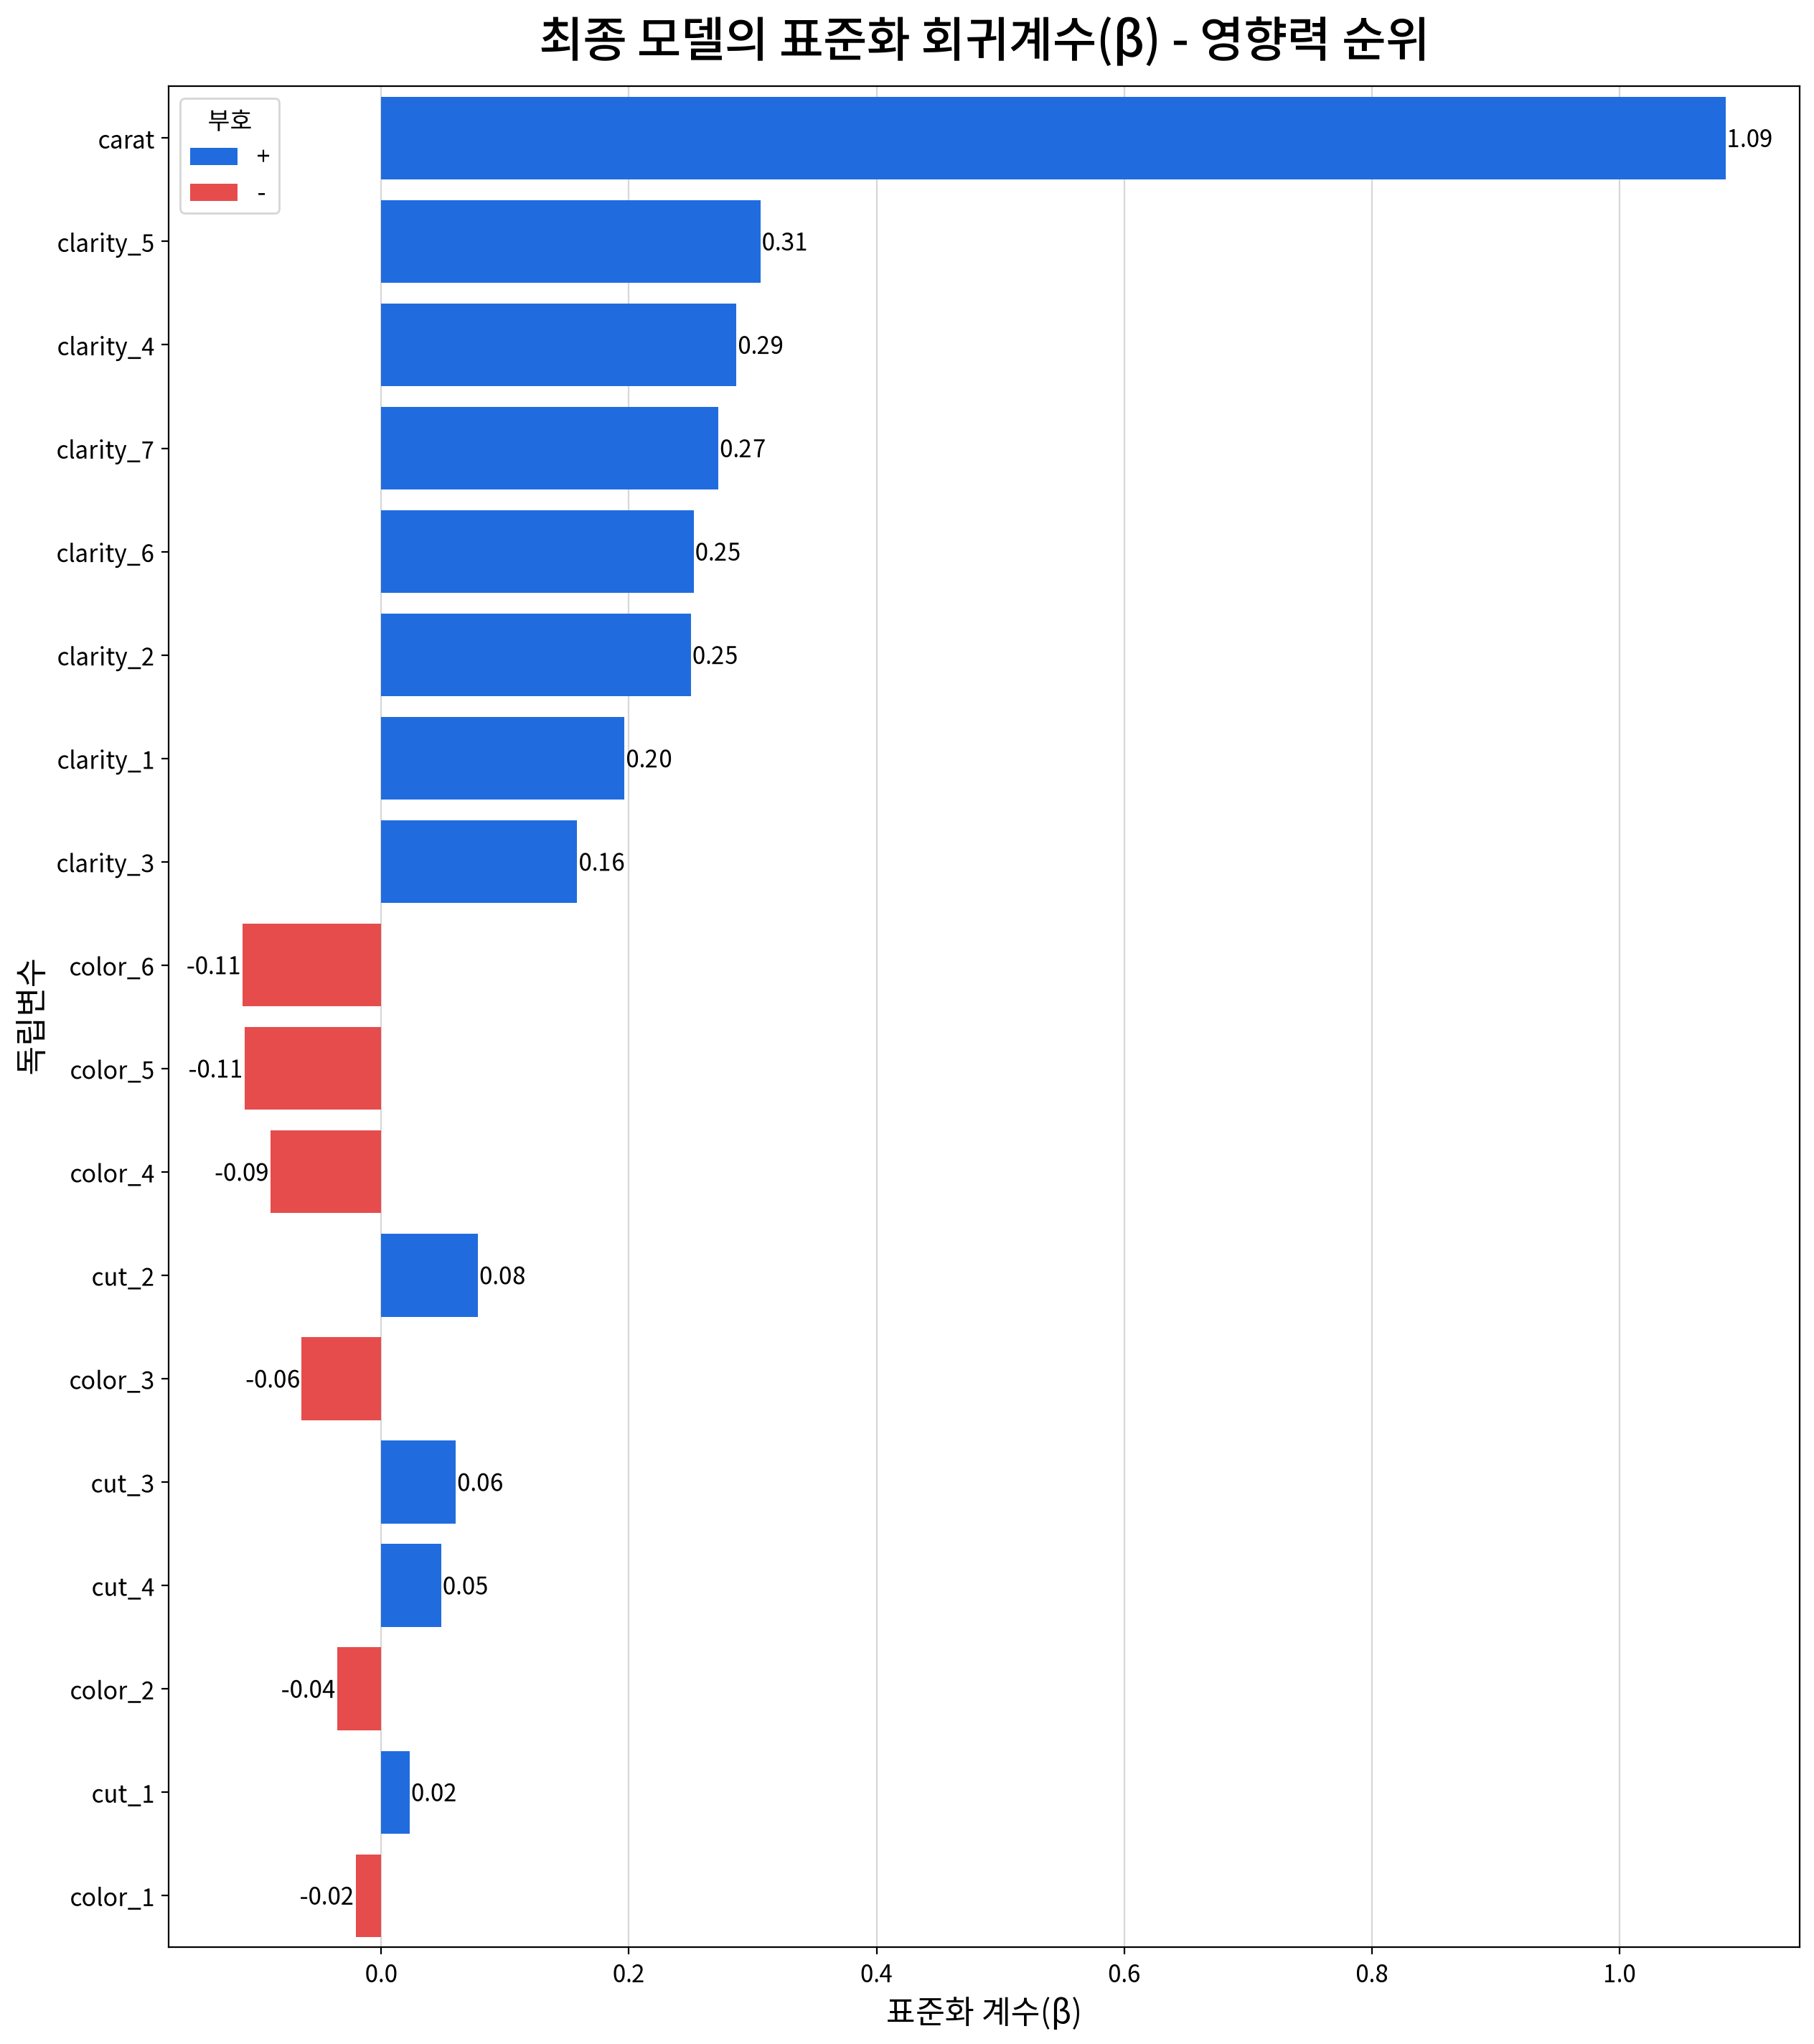

#### 4) 회귀계수 해석 문장

- **carat**의 회귀계수는 **B = 1.88**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 1452.68**, **p < .001**)      
즉, carat가 **1% 증가**할 때 price는 평균적으로 약 **1.88% 증가**하는 것으로 해석된다.
- **cut_1**의 회귀계수는 **B = 0.08**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 17.15**, **p < .001**)      
즉, cut_1가 **1 증가**할 때 price는 평균적으로 약 **8.42% 증가**하는 것으로 해석된다.
- **cut_2**의 회귀계수는 **B = 0.16**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 36.2**, **p < .001**)      
즉, cut_2가 **1 증가**할 때 price는 평균적으로 약 **17.54% 증가**하는 것으로 해석된다.
- **cut_3**의 회귀계수는 **B = 0.14**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 31.09**, **p < .001**)      
즉, cut_3가 **1 증가**할 때 price는 평균적으로 약 **15.00% 증가**하는 것으로 해석된다.
- **cut_4**의 회귀계수는 **B = 0.12**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 26.18**, **p < .001**)      
즉, cut_4가 **1 증가**할 때 price는 평균적으로 약 **12.48% 증가**하는 것으로 해석된다.
- **color_1**의 회귀계수는 **B = -0.05**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -24.01**, **p < .001**)      
즉, color_1가 **1 증가**할 때 price는 평균적으로 약 **5.26% 감소**하는 것으로 해석된다.
- **color_2**의 회귀계수는 **B = -0.09**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -41.22**, **p < .001**)      
즉, color_2가 **1 증가**할 때 price는 평균적으로 약 **9.02% 감소**하는 것으로 해석된다.
- **color_3**의 회귀계수는 **B = -0.16**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -71.62**, **p < .001**)      
즉, color_3가 **1 증가**할 때 price는 평균적으로 약 **14.81% 감소**하는 것으로 해석된다.
- **color_4**의 회귀계수는 **B = -0.25**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -107.31**, **p < .001**)      
즉, color_4가 **1 증가**할 때 price는 평균적으로 약 **22.19% 감소**하는 것으로 해석된다.
- **color_5**의 회귀계수는 **B = -0.37**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -142.32**, **p < .001**)      
즉, color_5가 **1 증가**할 때 price는 평균적으로 약 **31.10% 감소**하는 것으로 해석된다.
- **color_6**의 회귀계수는 **B = -0.51**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -154.95**, **p < .001**)      
즉, color_6가 **1 증가**할 때 price는 평균적으로 약 **40.02% 감소**하는 것으로 해석된다.
- **clarity_1**의 회귀계수는 **B = 1.11**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 119.04**, **p < .001**)      
즉, clarity_1가 **1 증가**할 때 price는 평균적으로 약 **204.24% 증가**하는 것으로 해석된다.
- **clarity_2**의 회귀계수는 **B = 0.59**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 69.2**, **p < .001**)      
즉, clarity_2가 **1 증가**할 때 price는 평균적으로 약 **80.75% 증가**하는 것으로 해석된다.
- **clarity_3**의 회귀계수는 **B = 0.43**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 49.58**, **p < .001**)      
즉, clarity_3가 **1 증가**할 때 price는 평균적으로 약 **53.31% 증가**하는 것으로 해석된다.
- **clarity_4**의 회귀계수는 **B = 0.81**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 94.26**, **p < .001**)      
즉, clarity_4가 **1 증가**할 때 price는 평균적으로 약 **125.04% 증가**하는 것으로 해석된다.
- **clarity_5**의 회귀계수는 **B = 0.74**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 86.48**, **p < .001**)      
즉, clarity_5가 **1 증가**할 때 price는 평균적으로 약 **109.78% 증가**하는 것으로 해석된다.
- **clarity_6**의 회귀계수는 **B = 1.02**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 114.56**, **p < .001**)      
즉, clarity_6가 **1 증가**할 때 price는 평균적으로 약 **176.70% 증가**하는 것으로 해석된다.
- **clarity_7**의 회귀계수는 **B = 0.95**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 107.78**, **p < .001**)      
즉, clarity_7가 **1 증가**할 때 price는 평균적으로 약 **157.58% 증가**하는 것으로 해석된다.

> ※ 위 **t**와 **유의확률**은 등분산 가정이 충족되지 않은 경우를 대비해 **HC3 로버스트 표준오차**로 계산한 값이다.     
회귀계수(B)와 효과 크기 해석은 일반 OLS와 동일하며,     
표준오차만 이분산에 강건하게 보정되어 유의성 판정이 달라질 수 있다.

---

### ▶ 회귀모형 가정 검정

#### 1) 선형성 검정

,statistic,p-value,linearity,result
Ramsey RESET,923.615,0.000,False,대립가설 채택 → 선형성 위배(곡선 관계 존재)


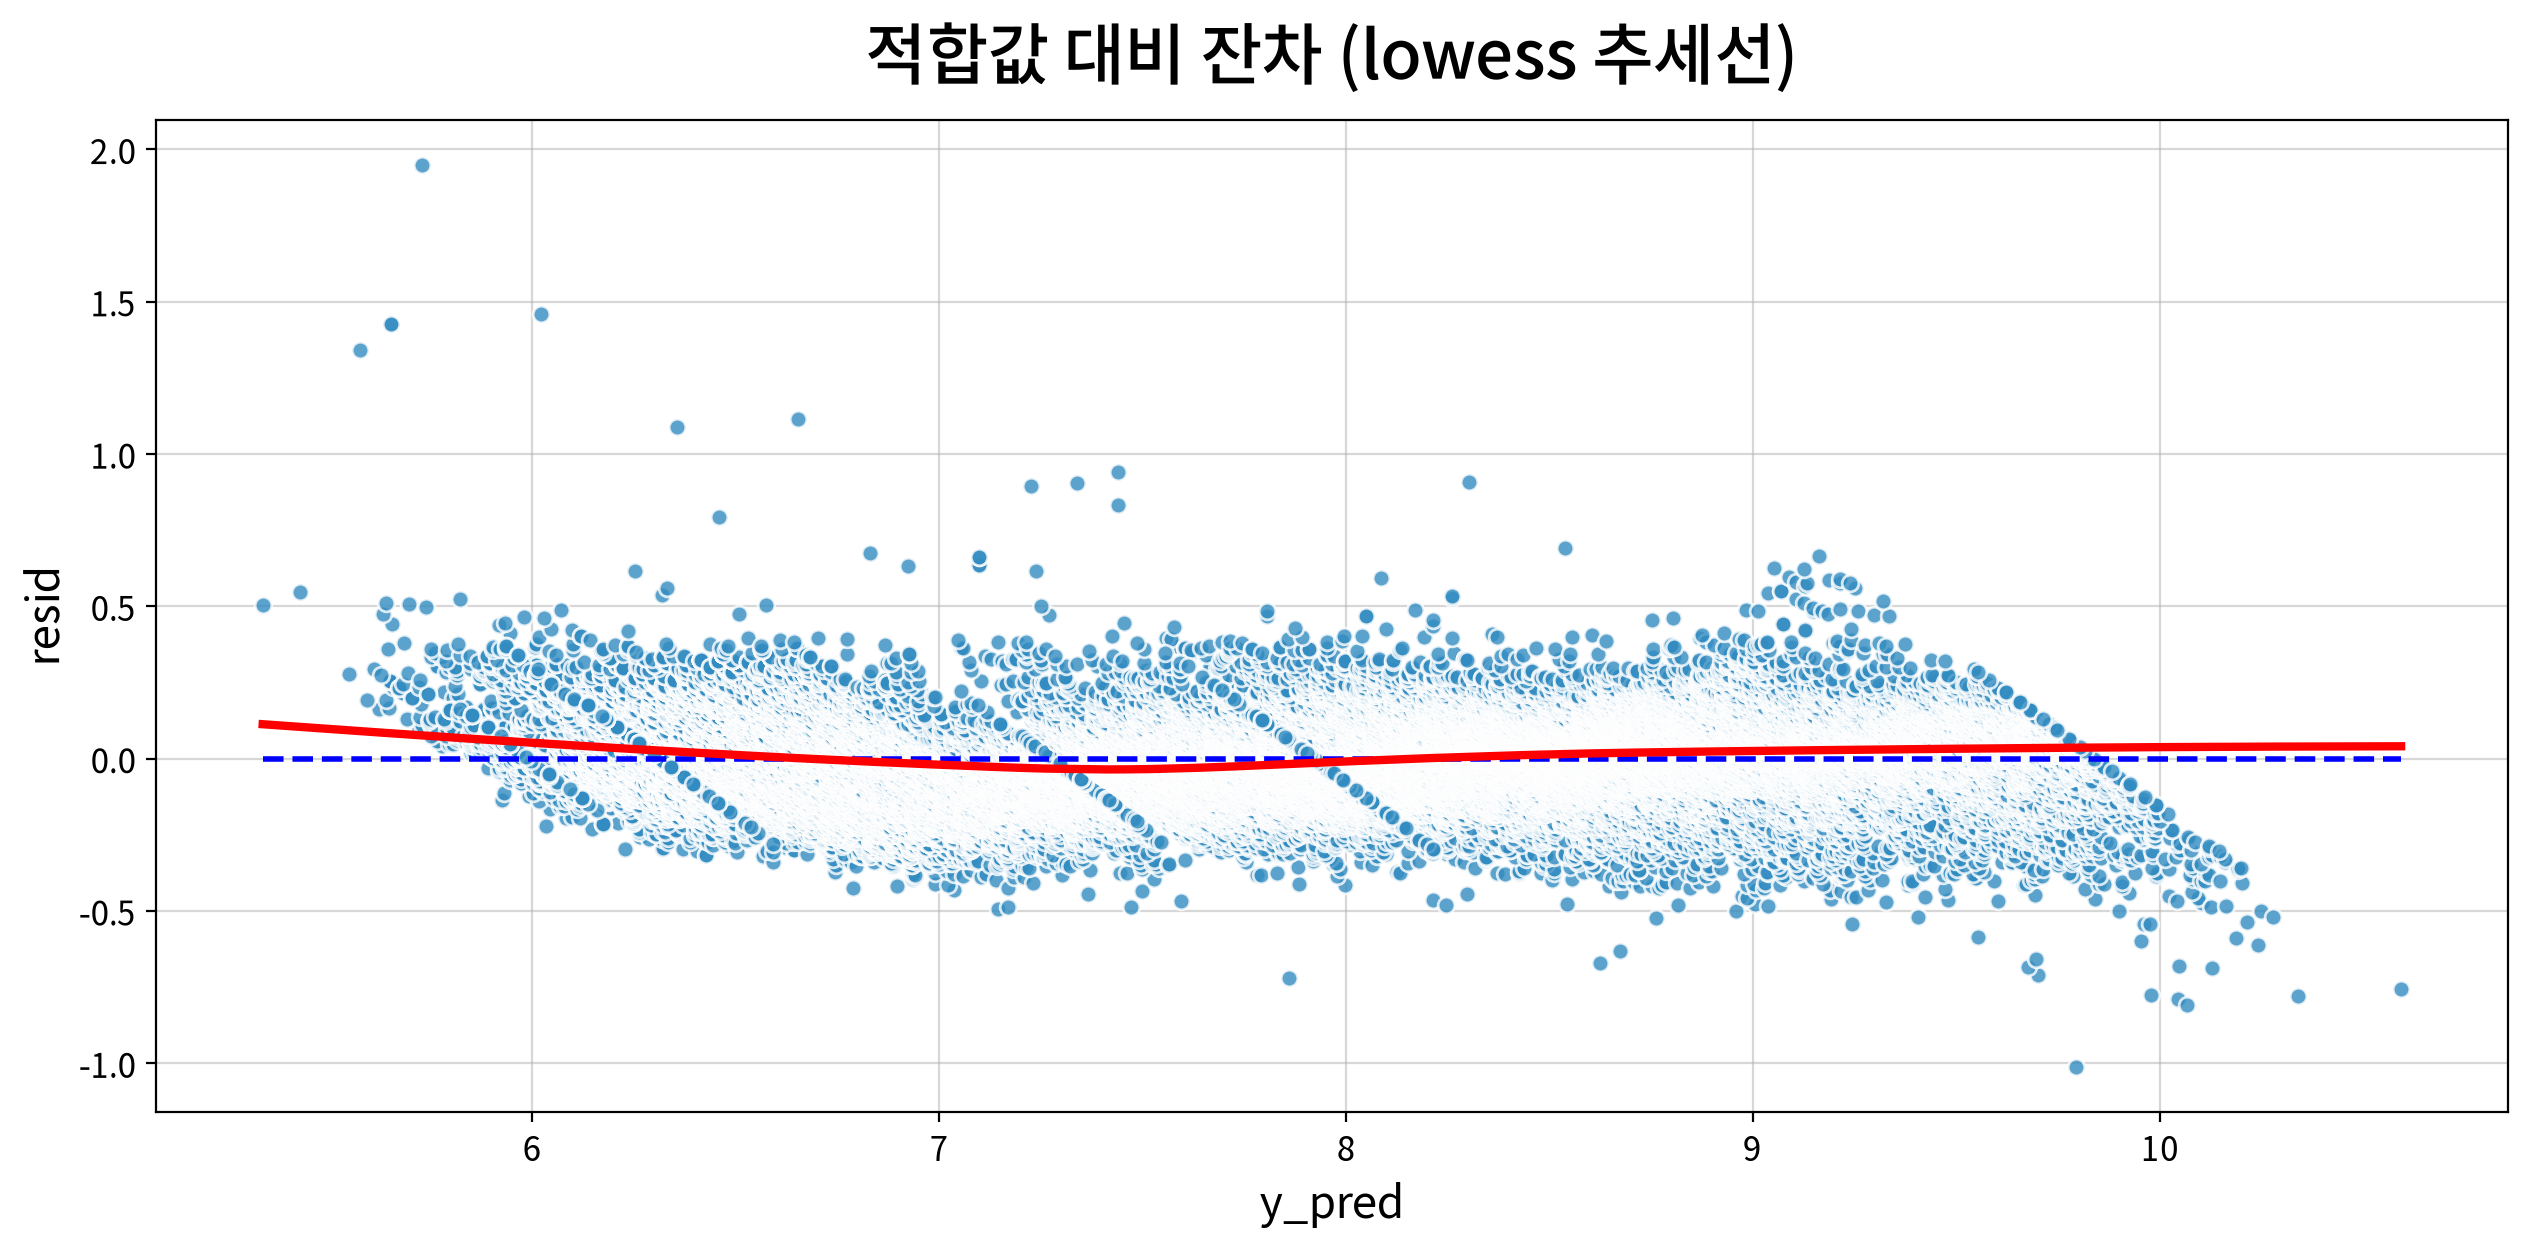

#### 2) 정규성 검정

,statistic,p-value,normality,result
Kolmogorov-Smirnov,0.018,0.000,False,대립가설 채택 → 정규성 위배


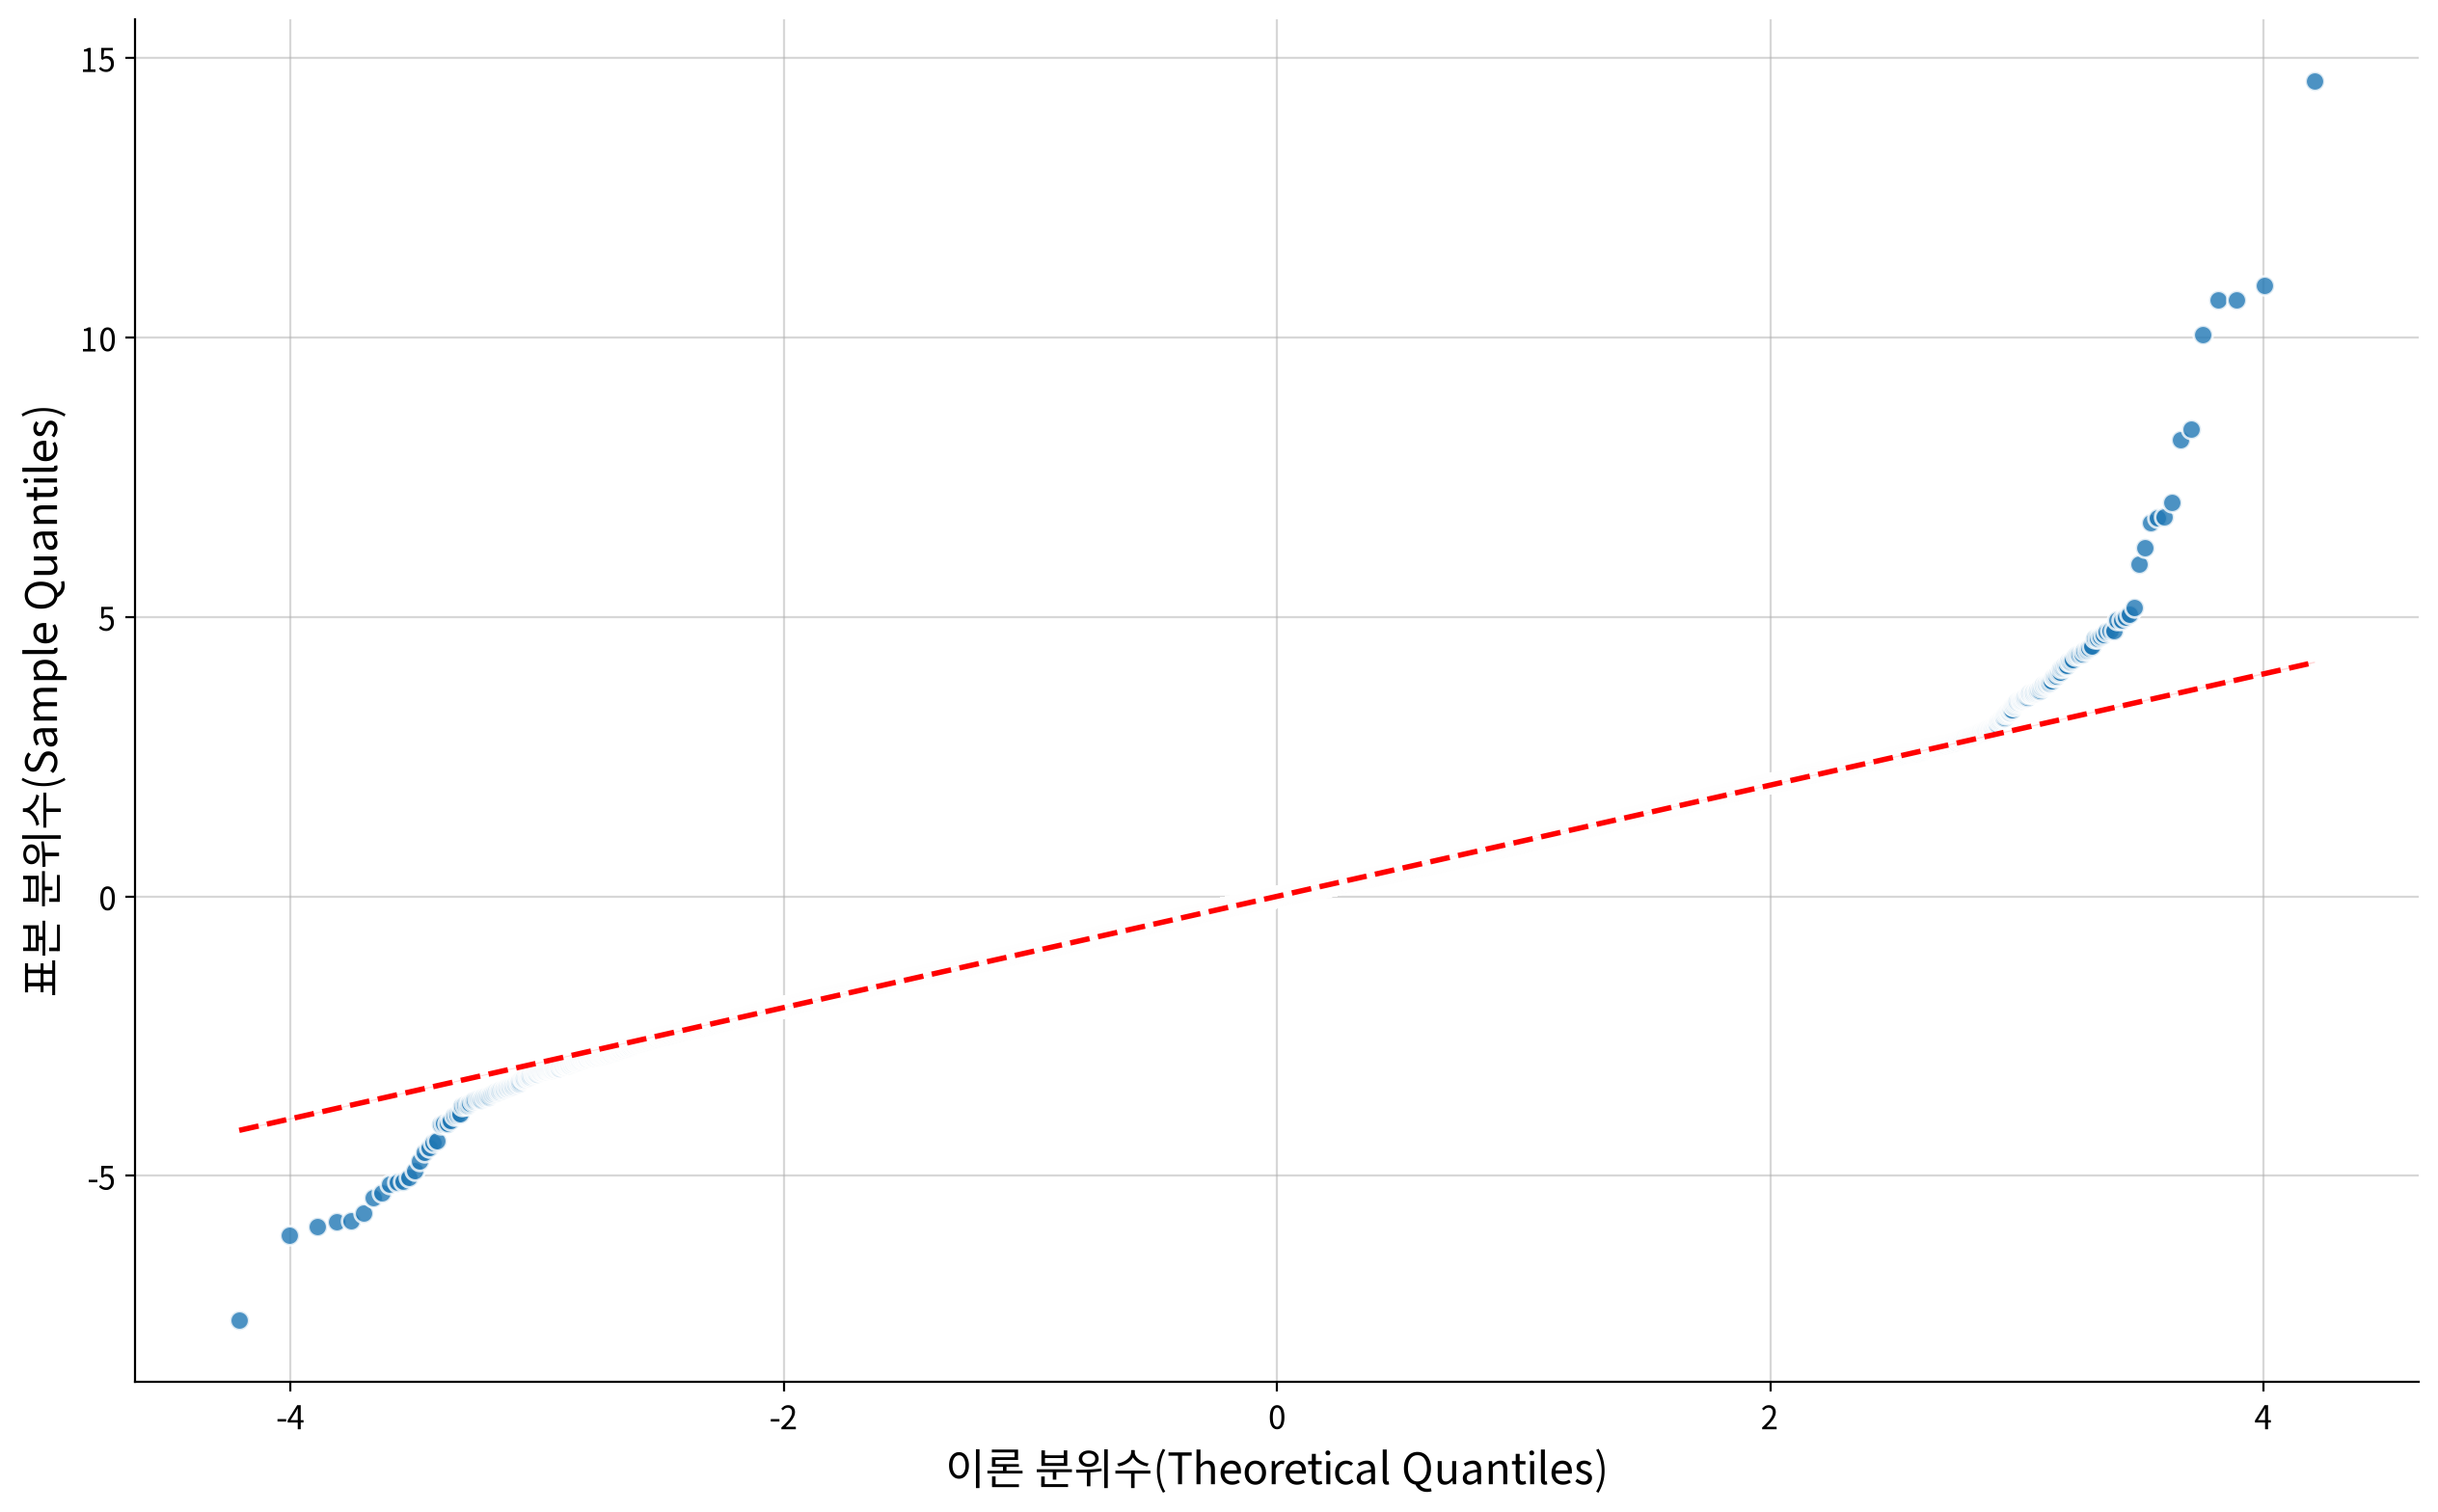

,기대(%),허용범위(%),실제(%),판정
구간,,,,
±1√MSE,68.000,68~68,69.740,위배
±2√MSE,95.000,95~95,95.420,위배
±3√MSE,99.700,100~100,99.600,위배


√MSE = 0.13 · 구간 규칙 판정: 정규성 위배


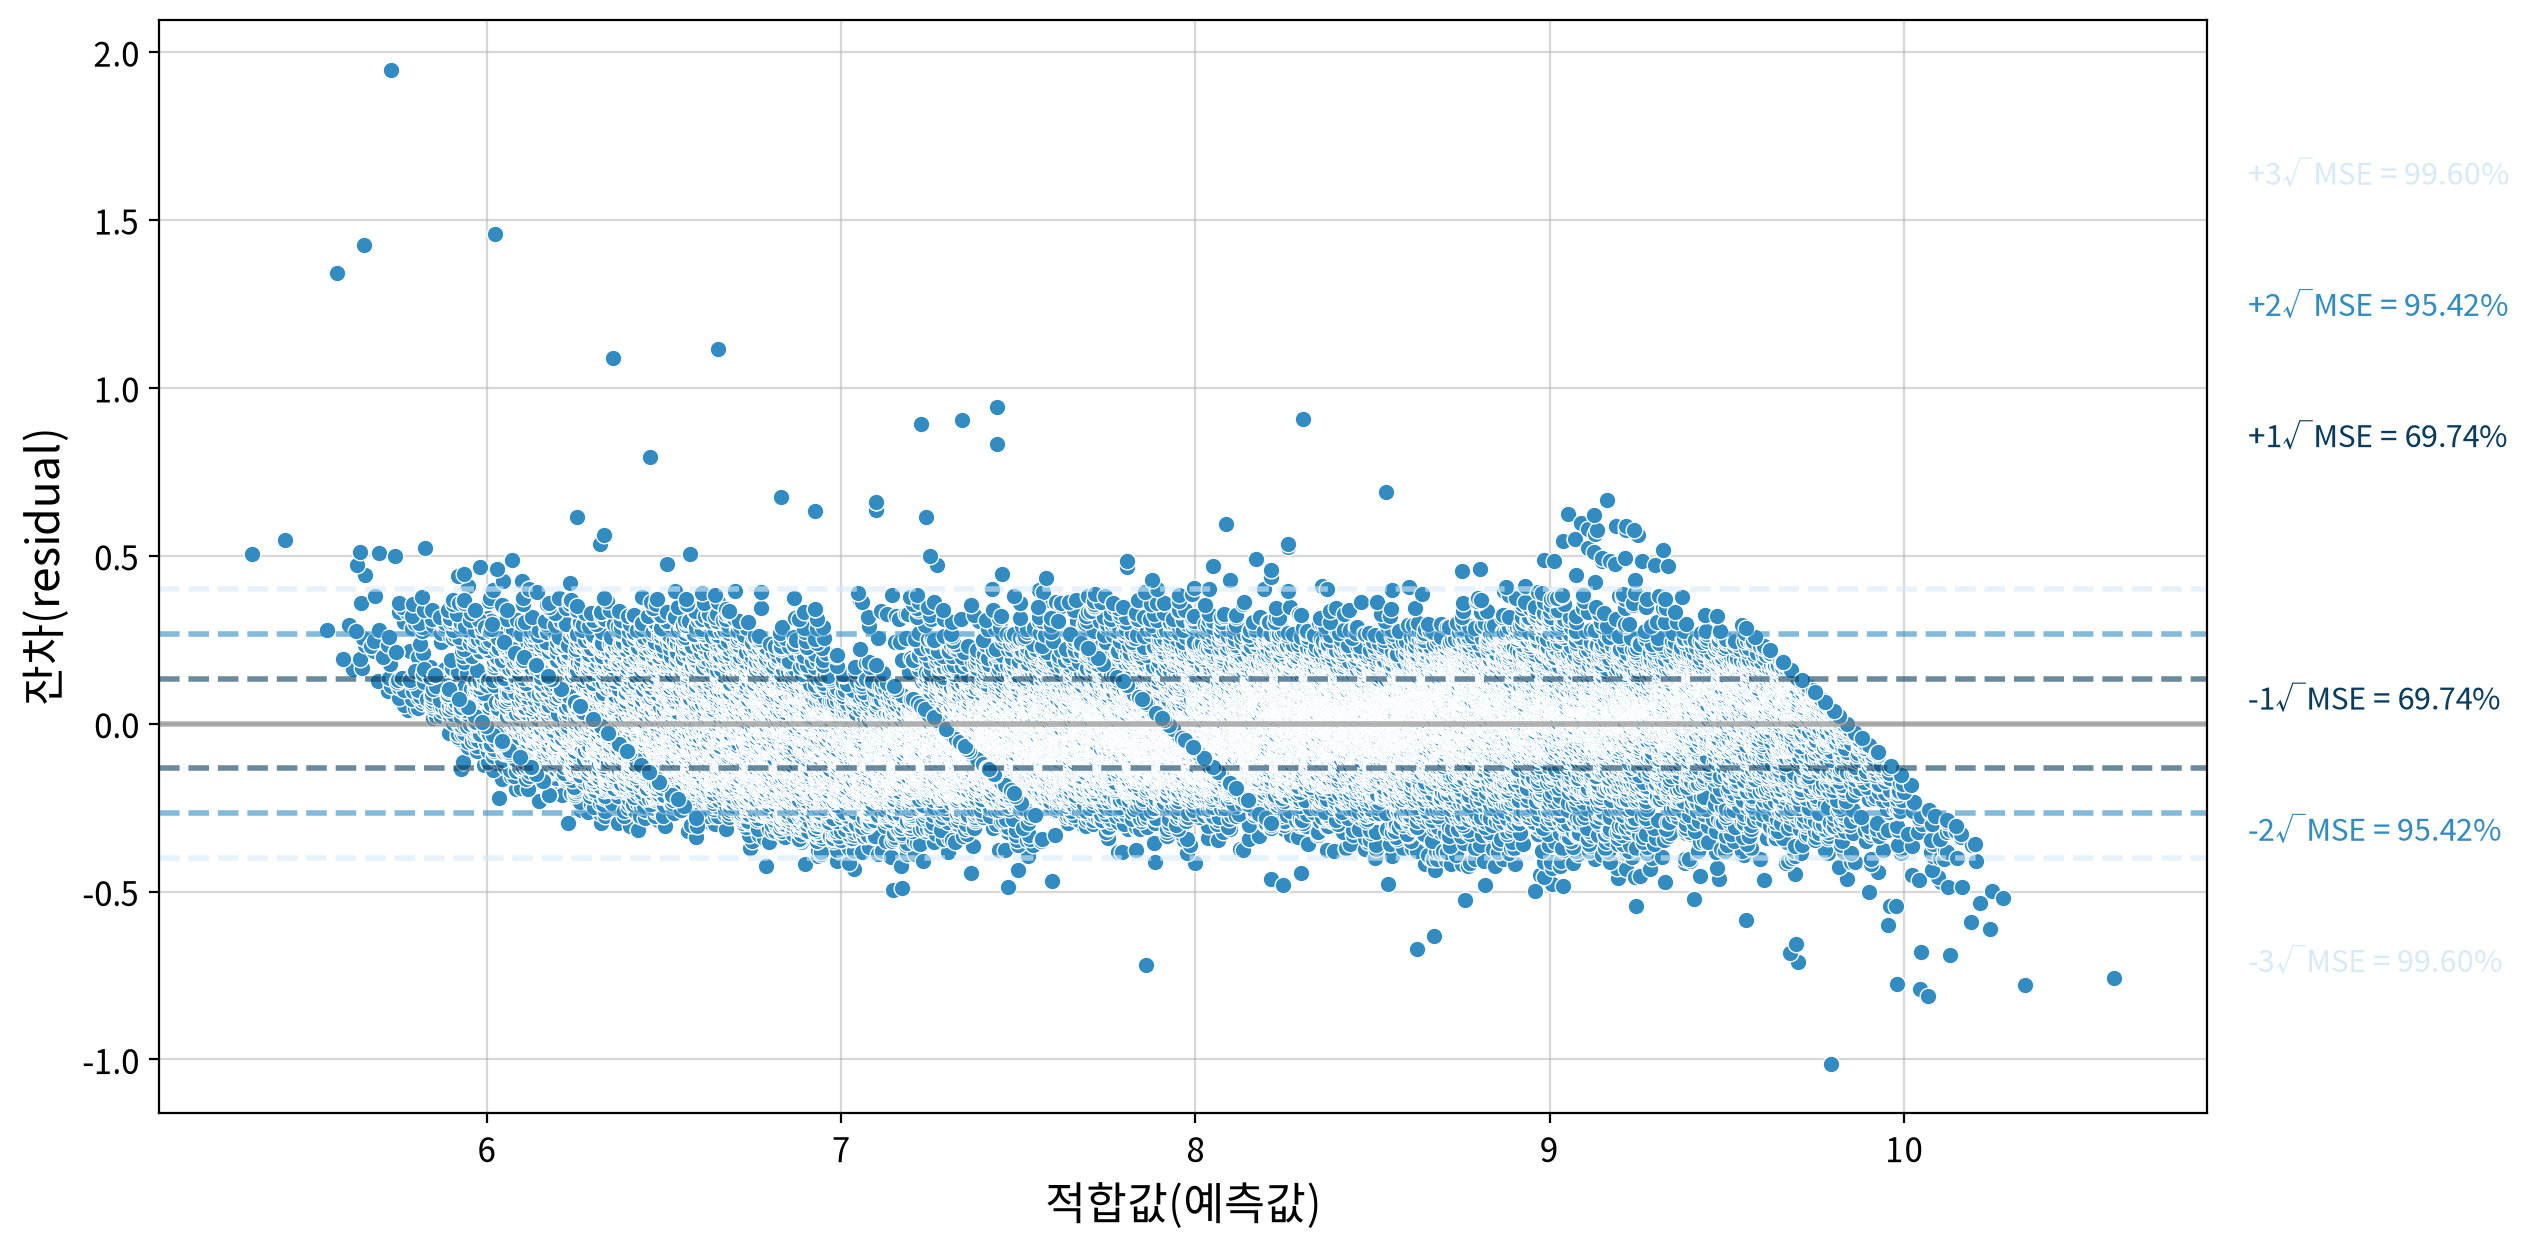

#### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,1336.676,0.000,76.125,0.000,False,대립가설 채택 → 등분산 아님


#### 4) 독립성 검정

,statistic,independence,result
Durbin-Watson,1.253,False,독립성 위반 (양(+)의 자기상관)


In [31]:
my_ols.report_model(final_fit)

#### 💡 인사이트

**모형 요약** — `log(price) ~ log(carat) + cut·color·clarity 더미`

- **F(18, 53775) = 169,374.3, p < .001, R² = 0.983** 으로 가격 분산의 98.3%를 설명한다. 18개 변수 모두 유의하다(HC3 기준 p < .001).
- **영향력은 `carat` 이 압도적이다.** 표준화 계수 β = 1.086으로, 2위인 `clarity_5`(β = 0.306)의 3.5배다.
  단, `clarity` 더미 7개의 β를 합하면 1.721로 `carat` 하나보다 크다(단일 변수 기준으로는 `carat`이 압도적).
- **`carat` 은 탄력성**으로 읽는다 — 중량이 1% 늘면 가격은 약 **1.88% 상승**한다.
- **더미는 기준 범주 대비 가격 차이**다(기준: `cut`=Fair, `color`=D, `clarity`=I1).

| 등급 | 계수 해석 | 등급 순서와 일치? |
|---|---|---|
| `cut` | Ideal +17.5% > Premium +15.0% > Very Good +12.5% > Good +8.4% | ✅ |
| `color` | D(기준) > E −5.3% > … > J −40.0% | ✅ |
| `clarity` | IF +204.2% > VVS1 +176.7% > … > SI2 +53.3% | ✅ |

라벨 인코딩이 알파벳순이라 컬럼명은 `cut_2` 처럼 나오지만, 계수의 크기 순서는 실제 품질 등급 순서와 정확히 일치한다.

**가정 검정 — 4개 모두 위배**

| 가정 | 통계량 | 비고 |
|---|---|---|
| 선형성 | RESET F = 923.62, p < .001 | 로그-로그 모형에도 곡선 관계가 남음 |
| 정규성 | K-S = 0.018, p < .001 | 통계량 자체는 매우 작음 (±1√MSE 구간 69.74% vs 기대 68%) |
| 등분산성 | BP F = 76.13, p < .001 | HC3 로버스트 표준오차로 자동 보정됨 |
| 독립성 | DW = 1.253 | 양(+)의 자기상관 |

n = 53,794의 대표본에서는 미세한 이탈도 검정에서 유의하게 나온다. 정규성은 구간 규칙상 기대값과 1.7%p 차이에 불과해 실질적 문제로 보기 어렵다.

---

**한계점**

- **표본이 시장 전체를 대표하지 않는다.** 특정 시점·유통 경로의 데이터이므로 시세 변동이나 다른 시장에 그대로 적용할 수 없다.
- **선형성 위배가 남아 있다.** 두 변수에 모두 로그를 씌우고도 곡선 관계가 검출되므로, 중량 구간에 따라 가격 반응이 달라질 가능성이 있다.
- **이상치를 IQR 경계값으로 대체했다.** 실제로 존재하는 고가 다이아몬드를 인위적으로 눌러 놓은 것이므로, 극단 구간의 설명력은 낮아진다.
- **등분산 위배로 예측의 정밀도가 일정하지 않다.** 계수의 유의성은 HC3로 보정했지만, 고가 구간일수록 오차가 커지는 문제는 그대로 남는다.
- **독립성 위배(DW = 1.253)는 해석이 불가능하다.** 시계열 데이터가 아닌 횡단면 데이터이므로 독립성의 영향을 받지 않는다.

**개선 방향**

- **`log(carat)` 의 제곱항이나 구간 분할**을 적용해 잔존 곡선 관계를 흡수한다.
- **`carat` 과 등급의 상호작용항**을 검토한다. EDA에서 `clarity` 별 `carat` 기울기가 2.76배 차이 났으므로 근거가 있다.
- **행 순서를 무작위로 섞은 뒤 DW를 다시 확인**해 자기상관이 실재하는지 판별한다.
- **제외했던 `x`·`y`·`z` 를 부피(`x × y × z`) 같은 파생변수로 되살려** 공선성 없이 형태 정보를 활용한다.
- **잔차가 큰 관측치를 따로 추려** 특정 등급·가격대에 치우쳐 있는지 확인한다.

---
## #7. 결과 해석

> 최종 채택 모형 `7_도메인_이상치대체`(= `final_fit`)의 결과를 바탕으로 #1의 분석 질문과 가설에 답한다.
> (#6 최종 채택 모델 결과 보고의 `my_ols.report_model(final_fit)` 출력 기준)

#### 7-1. 회귀계수 해석

**모형:** `log(price) ~ log(carat) + cut + color + clarity` (독립변수 18개)

| 항목 | 값 |
|---|---|
| 적합도 | F(18, 53775) = 169,374.3, p < .001 |
| 설명력 | R² = 0.983 (모형 척도: 로그 변환한 price) / R² = 0.960 (원본 척도: USD) |
| 예측 오차 | RMSE = 796.88 달러 (원본 척도) |
| 유의성 | 18개 변수 모두 유의 (HC3 기준 p < .001) |

**계수 해석** (더미 변수는 기준 범주 대비 차이: `cut`=Fair, `color`=D, `clarity`=I1)

| 변수 | 계수(B) / 효과 | 표준화계수(β) | 해석 |
|---|---|---|---|
| `log(carat)` | B = 1.884 | **1.086** | 중량이 **1% 늘면 가격 약 1.88% 상승** (탄력성). 중량이 2배면 가격은 `2^1.884 ≈ 3.7배` |
| `cut` | Good +8.4% < Very Good +12.5% < Premium +15.0% < Ideal +17.5% | — | 등급이 오를수록 가격이 높음 (순서 일치) |
| `color` | E −5.3% … J −40.0% | — | D에서 멀어질수록 가격이 낮음 (순서 일치) |
| `clarity` | SI2 +53.3% … VVS1 +176.7% < IF +204.2% | `clarity_5` 0.306 (2위, 알파벳순 인코딩 기준 VS2) | 등급이 오를수록 가격이 높음 (순서 일치) |

**영향력 순위 (표준화계수 기준):** 1위 `carat`(1.086) > 2위 `clarity_5`(0.306)

**해석에서 주의할 점**

1. **`carat`의 영향력이 압도적임.** β가 2위 `clarity_5`의 약 3.5배(1.086 ÷ 0.306)임.
2. **단변량 결과와 다변량 결과가 다름.** EDA의 ANOVA에서는 `cut`·`color`·`clarity` 모두 효과크기가 Small이고 등급 순서와 집단 평균 순서가 일치하지 않았음. 그러나 `carat`을 통제한 최종 모형에서는 세 변수 모두 계수의 크기 순서가 실제 등급 순서와 일치함.
3. **더미 변수명은 알파벳 순서로 인코딩됨.** `cut_2`는 `Ideal`을 의미하므로, 컬럼명 숫자는 등급 순서가 아님 (#5의 `labeling` 출력으로 확인).

#### 7-2. 질문별 답변과 가설 판정

**Q1. 다이아몬드 가격을 가장 크게 좌우하는 요인은 무엇인가?**

- 근거: 표준화계수 `carat` β = **1.086**으로 2위 `clarity_5`(0.306)의 약 3.5배임. EDA에서도 `carat`은 가격과 Spearman ρ = +0.963의 강한 양의 단조 관계였음.
- **답: 중량(`carat`)임.** 중량이 1% 늘 때 가격은 평균 약 1.88% 상승함.

**Q2. 중량과 품질 등급 중 무엇이 가격을 더 잘 설명하는가? 등급 3종 중에서는 무엇의 영향이 가장 큰가?**

- 근거 ① `carat` β(1.086)가 등급 변수 중 최대 β(`clarity_5` 0.306)보다 큼.
- 근거 ② 기준 범주 대비 최대 격차는 `clarity` +204.2%(IF) > `color` −40.0%(J) > `cut` +17.5%(Ideal) 순임.
- **답: 중량이 가장 크게 설명하고, 등급 중에서는 투명도(`clarity`) > 색상(`color`) > 컷(`cut`) 순으로 가격 격차가 큼.**
  - 단, 이 순위는 기준 범주 대비 최대 격차를 비교한 것이며 범주 수와 기준 범주가 변수마다 다름.

**Q3. 기계적인 변수 선택과 도메인 지식에 근거한 제거 중 어느 쪽이 나은가?**

| 구분 | 모델 | 변수 수 | RMSE(USD) |
|---|---|---|---|
| 기계적 (VIF 제거) | `3_공선성제거` | 19 | 1,096.54 |
| 기계적 (최고 성능) | `2_이상치대체` | 21 | 831.95 |
| **도메인 (최종)** | **`7_도메인_이상치대체`** | **18** | **796.88** |

- 근거: VIF는 `carat`·`x`·`y`·`z`의 상관이 모두 ρ≈0.96으로 동률이라 `z`를 남겼고, 그 결과 RMSE가 1,096.54로 나빠졌음. 도메인 지식으로 `carat`을 남긴 모형(796.88)과는 Gap 37.600%(노트북 성능표 기준) 차이임.
- 기계적 최고 모형 `2_이상치대체`(831.95)는 도메인 최종 모형(796.88) 대비 **Gap 4.400%로 RMSE가 높고, 변수는 3개 많음(21 vs 18)** 임.
- **답: 도메인 지식에 근거한 제거가 더 나았음.**
  - 다만 도메인 제거만으로는 부족했음. `5_도메인_기준선`은 RMSE 1,155.81(Gap 45.040%)로 9개 모형 중 꼴찌였고, 로그 변환을 더한 `6_도메인_로그변환`에서 798.87(Gap 0.250%)로 Gap이 줄어듦.
  - → **변수 선택과 변환은 함께 가야 함.**

**가설 판정**

| 가설 | 채택 / 기각 | 근거 |
|---|---|---|
| H1. 중량 ↑ → 가격 ↑ | **채택** | B = +1.884, β = 1.086, p < .001 (중량 1% 증가 시 가격 약 1.88% 상승) |
| H2. 투명도 등급 ↑ → 가격 ↑ | **채택** | I1 대비 SI2 +53.3% ~ IF +204.2%, 계수 순서가 등급 순서와 일치 |
| H3. 색상이 D에 가까울수록 ↑ | **채택** | D 대비 E −5.3% ~ J −40.0%, 계수 순서가 등급 순서와 일치 |
| H4. 컷 등급 ↑ → 가격 ↑ | **채택** | Fair 대비 Good +8.4% ~ Ideal +17.5%, 계수 순서가 등급 순서와 일치 (격차는 3종 중 가장 작음) |

**핵심 인사이트**

1. **가격을 가장 크게 결정하는 것은 중량임.** `carat`의 β는 등급 변수 중 최대인 `clarity_5`의 약 3.5배임.
2. **등급은 `carat`을 통제해야 순서대로 드러남.** 단변량 ANOVA에서는 등급 순서와 집단 평균 순서가 맞지 않았으나, 다변량 모형에서는 세 변수 모두 순서가 일치함.
3. **VIF만 믿으면 무엇을 남길지 모름.** 상관이 동률인 4개 변수 중 VIF는 `z`를 남겼고, 이는 `carat`을 남긴 모형보다 RMSE의 Gap이 37.600%였음.
4. **변수 선택과 변환은 함께 가야 함.** 도메인 제거만 한 모형은 9개 중 꼴찌(1,155.81)였지만, 로그 변환을 더하자 798.87(Gap 0.250%)로 개선됨.
5. **도메인 모형에서는 이상치 대체의 효과가 작음.** `6_도메인_로그변환` → `7_도메인_이상치대체`의 RMSE 차이는 Gap 0.250%(798.87 vs 796.88)에 그침.

#### 7-3. 활용과 한계

**활용**

- **적용 범위:** Kaggle diamonds 데이터셋이 관측된 시점·유통 경로의 가격 구조를 설명하는 용도에 한정됨.
- **계수의 의미:** 중량·등급이 가격과 함께 움직이는 정도를 보여주는 **기술적 요약**임.

**한계**

- **가정 검정 4개가 모두 위배됨**

| 가정 | 통계량 | 조치 / 판단 |
|---|---|---|
| 선형성 | RESET F = 923.62, p < .001 | 로그-로그 모형에도 곡선 관계가 남음.|
| 정규성 | K-S = 0.018, p < .001 | K-S 통계량이 매우 작음. 구간 규칙은 3개 구간 모두 '위배'로 판정되나 차이는 작음(±1√MSE 69.74% vs 68%, ±2√MSE 95.42% vs 95%, ±3√MSE 99.60% vs 99.7%) |
| 등분산성 | BP F = 76.13, p < .001 | **HC3 로버스트 표준오차로 보정**. 고가 구간일수록 오차가 커지는 문제는 남음 |
| 독립성 | DW = 1.253 | 양(+)의 자기상관. 시계열이 아닌 횡단면 데이터라 시계열 해석은 불가함. |

- **더미 변수 간 공선성:** 최종 계수표에서 `clarity` 더미의 VIF가 최대 14.65(`clarity_2`)이고 `clarity_5` 14.17, `clarity_3` 11.39, `clarity_4` 10.70으로 기준 10을 넘음. `clarity` 개별 계수를 따로 떼어 해석할 때는 주의가 필요함.
- **데이터:** 특정 시점의 횡단면 데이터라 시세 변동이나 다른 시장에 그대로 적용할 수 없음.
- **이상치 처리:** IQR 경계값으로 대체했으므로 실재하는 고가 다이아몬드가 인위적으로 눌려 있음. 극단 구간의 설명력은 낮아졌을 수 있음.
- **원자료 오류값:** `x`·`y`·`z`의 0mm 값(7·6·19건)과 `y` 58.9mm·`z` 31.8mm 극단값은 행을 삭제하지 않고 해당 열을 모형에서 제외하는 방식으로 처리함(모형 행 수 53,794 유지).
- **일반화 성능:** 학습/검증 분할 없이 전체 데이터로 적합했으므로 RMSE·R²는 **학습 데이터 기준 값**임.
- **해석:** 모든 결과는 인과가 아닌 **연관 관계**임.

**다음에 시도할 것**

- `log(carat)`의 제곱항 또는 구간 분할로 잔존 곡선 관계를 흡수
- `carat`과 등급의 상호작용항 검토 (EDA에서 `clarity`별 `carat` 기울기가 2.76배 차이남)
- 행 순서를 무작위로 섞은 뒤 DW를 다시 확인해 자기상관의 실재 여부 판별
- 제외한 `x`·`y`·`z`를 부피(`x × y × z`) 같은 파생변수로 되살려 공선성 없이 형태 정보를 활용
- 학습/검증 분할과 교차검증으로 RMSE를 일반화 가능한 값으로 재측정
